# Jupyter Notebook zur Bachelorarbeit von Richard van Bebber

### Erklärung zum Einsatz künstlicher Intelligenz
Künstliche Intelligenz wurde in Absprache mit dem Betreuer, Herrn Professor Drewitz, als Hilfsmittel für die grundlegende Codesynthese und Strukturierung des Quellcodes genutzt. Die inhaltliche Ausgestaltung der Modellarchitektur, die Durchführung sowie die kritische Validierung und Interpretation aller Ergebnisse erfolgten eigenständig und liegen in der vollen Verantwortung des Autors.

2016-2026 AIC-BIC screening hmmlearn

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Analysiere NVDA...
Analysiere TSLA...
Analysiere INTC...
Analysiere KO...


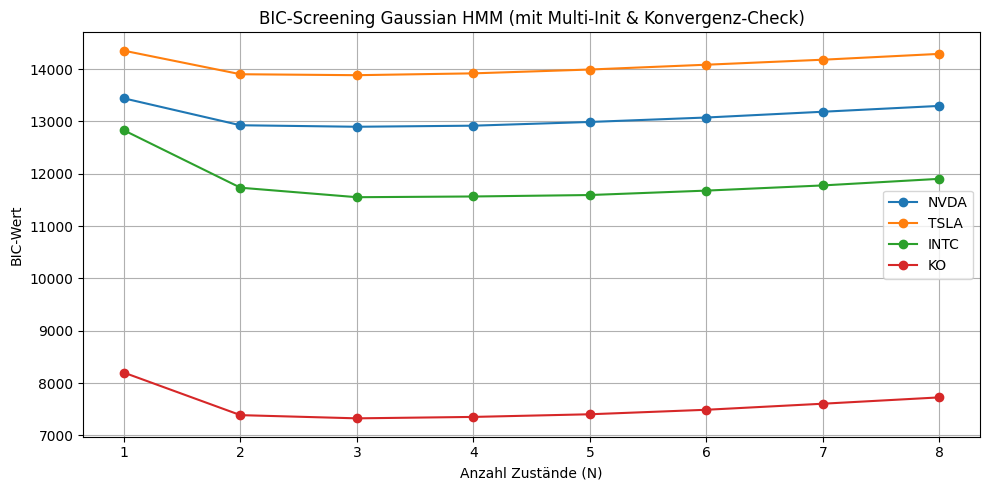

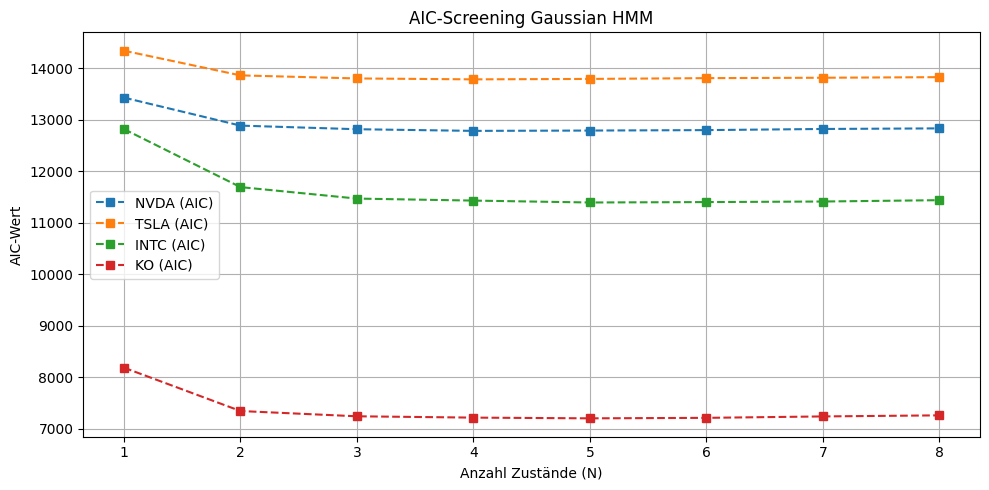


--- Vergleich der optimalen Zustandsanzahl (BIC vs. AIC) ---
  Ticker  N_BIC           BIC  N_AIC           AIC
0   INTC      3  11551.474895      5  11393.389958
1     KO      3   7327.015754      5   7205.012736
2   NVDA      3  12897.335676      4  12782.768421
3   TSLA      3  13882.485133      4  13782.408785


In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
from hmmlearn import hmm
import matplotlib.pyplot as plt

# --- 1. DATEN-VORBEREITUNG --- #Ticker und Zeiträume initialisieren
tickers = ["NVDA", "TSLA", "INTC", "KO"]
start_date = "2016-01-01"
end_date = "2026-06-27"
data_container = {}

for ticker in tickers: #Ticker und Zeiträume ziehen
    # auto_adjust=True korrigiert Splits/Dividenden (wichtig für NVDA!)
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    returns = (np.log(df['Close']).diff() * 100).dropna() #leere Daten auslassen
    data_container[ticker] = returns.values.reshape(-1, 1) #gezogene Daten in den df packen

# --- 2. ERWEITERTE ANALYSIS-FUNKTIONEN ---
def calculate_aic_bic(log_likelihood, n_states, n_samples, n_var_params=2): #AIC/BIC mit Formeln berechnen
    # k = N^2 + N*n_var_params - 1
    # Bei Standard-Gauß (Mean+Var) ist n_var_params=2, also k = N^2 + 2N - 1
    k = n_states**2 + n_states * n_var_params - 1
    aic = -2 * log_likelihood + 2 * k
    bic = k * np.log(n_samples) - 2 * log_likelihood
    return aic, bic

def fit_best_of_n(X, n_states, n_inits=10): #Über mehrere Initialisierungen prüfen, welches Model das Beste war wegen lokaler Maxima
    best_model = None
    best_ll = -np.inf
    converged = False

    for i in range(n_inits):
        model = hmm.GaussianHMM(n_components=n_states, covariance_type="diag",
                                 n_iter=300, tol=1e-4, random_state=None)
        try:
            model.fit(X)
            if model.monitor_.converged:
                if model.score(X) > best_ll:
                    best_ll = model.score(X)
                    best_model = model
                    converged = True
        except:
            continue

    return best_model, converged

# --- 3. SCREENING-LOOP MIT MULTI-INIT ---
all_results = []
N_INITS = 10

for ticker in tickers:
    X = data_container[ticker]
    print(f"Analysiere {ticker}...")

    for n in range(1, 9): #Prüfen über 8 Zustände
        model, converged = fit_best_of_n(X, n_states=n, n_inits=N_INITS)

        if model: #nehmen Modell nur wenn es konvergiert ist
            ll = model.score(X)
            aic, bic = calculate_aic_bic(ll, n, len(X)) #berechnen Kriterien
            all_results.append({'Ticker': ticker, 'N': n, 'AIC': aic, 'BIC': bic, 'Converged': converged}) #Anhängen für späteren Plot
        else:
            all_results.append({'Ticker': ticker, 'N': n, 'AIC': np.nan, 'BIC': np.nan, 'Converged': False}) #Falls keine Konvergenz keine Kriterien

# --- 4. ERGEBNIS-AUSWERTUNG --- #PLOT
results_df = pd.DataFrame(all_results)

plt.figure(figsize=(10, 5))
for ticker in tickers:
    subset = results_df[results_df['Ticker'] == ticker]
    plt.plot(subset['N'], subset['BIC'], marker='o', label=ticker)
    non_conv = subset[subset['Converged'] == False]
    plt.scatter(non_conv['N'], non_conv['BIC'], color='red', marker='x', s=100)
plt.title("BIC-Screening Gaussian HMM (mit Multi-Init & Konvergenz-Check)")
plt.xlabel("Anzahl Zustände (N)")
plt.ylabel("BIC-Wert")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for ticker in tickers:
    subset = results_df[results_df['Ticker'] == ticker]
    plt.plot(subset['N'], subset['AIC'], marker='s', linestyle='--', label=f"{ticker} (AIC)")
    non_conv = subset[subset['Converged'] == False]
    plt.scatter(non_conv['N'], non_conv['AIC'], color='red', marker='x', s=100)
plt.title("AIC-Screening Gaussian HMM")
plt.xlabel("Anzahl Zustände (N)")
plt.ylabel("AIC-Wert")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_bic = results_df.loc[results_df.groupby('Ticker')['BIC'].idxmin()][['Ticker', 'N', 'BIC']] #Tabellen zur Auswertung der Kriterien
best_aic = results_df.loc[results_df.groupby('Ticker')['AIC'].idxmin()][['Ticker', 'N', 'AIC']]
comparison = pd.merge(best_bic, best_aic, on='Ticker', suffixes=('_BIC', '_AIC'))
print("\n--- Vergleich der optimalen Zustandsanzahl (BIC vs. AIC) ---")
print(comparison)

2010-2026 AIC-BIC screening hmmlearn

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Analysiere NVDA...
Analysiere TSLA...
Analysiere INTC...
Analysiere KO...


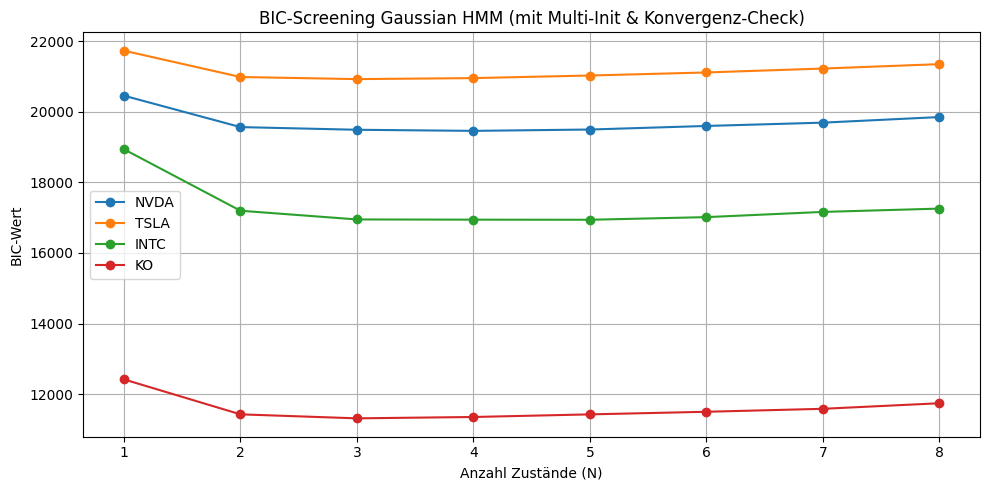

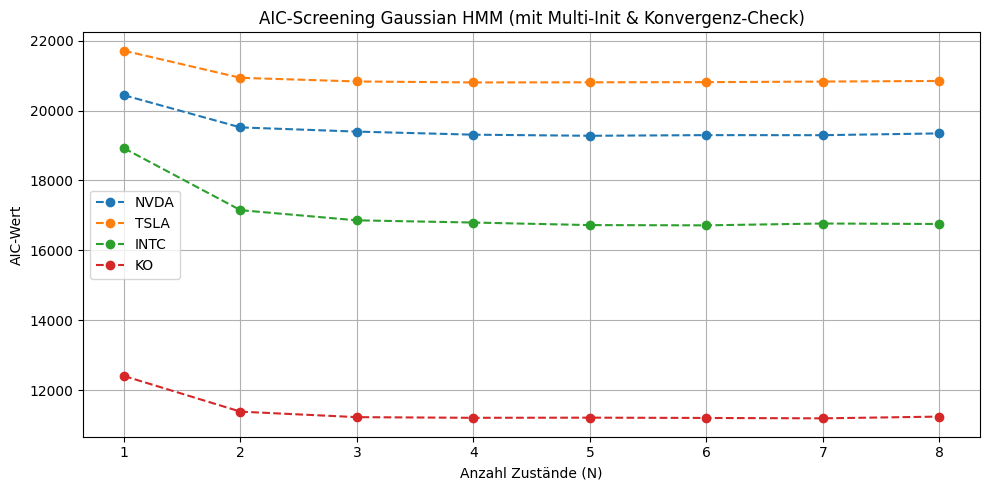


--- Bestes N nach BIC (Gaussian HMM) ---
   Ticker  N           BIC  Converged
20   INTC  5  16939.284869       True
26     KO  3  11317.583021       True
3    NVDA  4  19456.170253       True
10   TSLA  3  20921.467259       True

--- Bestes N nach AIC (Gaussian HMM) ---
   Ticker  N           AIC  Converged
21   INTC  6  16716.688857       True
30     KO  7  11194.956869       True
4    NVDA  5  19279.099827       True
11   TSLA  4  20805.145599       True

--- Vergleich Optima (BIC vs. AIC) ---
  Ticker  N_BIC           BIC  N_AIC           AIC
0   INTC      5  16939.284869      6  16716.688857
1     KO      3  11317.583021      7  11194.956869
2   NVDA      4  19456.170253      5  19279.099827
3   TSLA      3  20921.467259      4  20805.145599


In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
from hmmlearn import hmm
import matplotlib.pyplot as plt

# --- 1. DATEN-VORBEREITUNG --- #Ticker und Zeiträume initialisieren
tickers = ["NVDA", "TSLA", "INTC", "KO"]
start_date = "2010-01-01"
end_date = "2026-06-27"
data_container = {}
for ticker in tickers: #Ticker und Zeiträume ziehen
    # auto_adjust=True korrigiert Splits/Dividenden (wichtig für NVDA!)
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    returns = (np.log(df['Close']).diff() * 100).dropna() #leere Daten auslassen
    data_container[ticker] = returns.values.reshape(-1, 1) #gezogene Daten in den df packen


# --- 2. ERWEITERTE ANALYSIS-FUNKTIONEN ---
def calculate_aic_bic(log_likelihood, n_states, n_samples, n_var_params=2): #AIC/BIC mit Formeln berechnen
    # k = N^2 + N*n_var_params - 1
    # Bei Standard-Gauß (Mean+Var) ist n_var_params=2, also k = N^2 + 2N - 1
    k = n_states ** 2 + n_states * n_var_params - 1
    aic = -2 * log_likelihood + 2 * k
    bic = k * np.log(n_samples) - 2 * log_likelihood
    return aic, bic


def fit_best_of_n(X, n_states, n_inits=10, base_seed=42): #Über mehrere Initialisierungen prüfen, welches Modell das Beste war wegen lokaler Maxima, immer am neuen Startpunkt
    """
    Fittet n_inits Modelle mit unterschiedlichen (aber reproduzierbaren) Seeds.
    Auswahlkriterium ist IMMER die beste Log-Likelihood ueber ALLE erfolgreichen
    Fits, unabhaengig von der Konvergenz. Konvergenz wird nur als Zusatz-Info
    mitgegeben (welcher Anteil der Versuche konvergiert ist, und ob das
    letztlich gewaehlte beste Modell konvergiert ist).
    """
    best_model = None
    best_ll = -np.inf
    best_converged = False
    n_converged = 0
    n_success = 0

    for i in range(n_inits):
        seed = base_seed + i #Startpunkt verändern
        model = hmm.GaussianHMM(n_components=n_states, covariance_type="diag",
                                 n_iter=300, tol=1e-4, random_state=seed)
        try:
            model.fit(X) #Modell berechnen
        except Exception as e:
            print(f"    [WARN] N={n_states}, seed={seed}: Fit fehlgeschlagen ({e})")
            continue

        n_success += 1
        converged = model.monitor_.converged #Konvergenz prüfen
        if converged:
            n_converged += 1

        ll = model.score(X) #Likelihood berechnen
        if ll > best_ll:
            best_ll = ll
            best_model = model
            best_converged = converged

    if best_model is None:
        print(f"    [WARN] N={n_states}: Kein einziger der {n_inits} Fit-Versuche erfolgreich.")
        return None, False, np.nan, "0/0"

    return best_model, best_converged, best_ll, f"{n_converged}/{n_success}"


# --- 3. SCREENING-LOOP MIT MULTI-INIT ---
all_results = []
N_INITS = 10

for ticker in tickers: #Für alle Ticker jetzt AIC/BIC berechnen für alle #Zustände
    X = data_container[ticker]
    print(f"Analysiere {ticker}...")
    for n in range(1, 9): #Prüfen über 8 Zustände
        model, converged, ll, konv_quote = fit_best_of_n(X, n_states=n, n_inits=N_INITS, base_seed=42)
        if model is not None: #nur übernehmen, wenn ein Fit gelang
            aic, bic = calculate_aic_bic(ll, n, len(X)) #berechnen Kriterien
            all_results.append({ #Anhängen für späteren Plot
                'Ticker': ticker, 'N': n, 'AIC': aic, 'BIC': bic,
                'Converged': converged, 'Konv_Quote': konv_quote
            })
        else:
            all_results.append({ #Falls kein Fit: keine Kriterien
                'Ticker': ticker, 'N': n, 'AIC': np.nan, 'BIC': np.nan,
                'Converged': False, 'Konv_Quote': konv_quote
            })

# --- 4. ERGEBNIS-AUSWERTUNG --- #PLOT
results_df = pd.DataFrame(all_results)

non_converged = results_df[~results_df['Converged']]
if len(non_converged) > 0:
    print("\n[ACHTUNG] Folgende (Ticker, N)-Kombinationen sind selbst im besten Versuch NICHT konvergiert:")
    print(non_converged[['Ticker', 'N', 'Konv_Quote']])
    print("-> Ergebnisse mit Vorsicht interpretieren bzw. ggf. n_iter erhoehen.\n")

plt.figure(figsize=(10, 5))
for ticker in tickers:
    subset = results_df[results_df['Ticker'] == ticker]
    plt.plot(subset['N'], subset['BIC'], marker='o', label=ticker)
    non_conv = subset[subset['Converged'] == False]
    plt.scatter(non_conv['N'], non_conv['BIC'], color='red', marker='x', s=100, zorder=5)
plt.title("BIC-Screening Gaussian HMM (mit Multi-Init & Konvergenz-Check)")
plt.xlabel("Anzahl Zustände (N)")
plt.ylabel("BIC-Wert")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for ticker in tickers:
    subset = results_df[results_df['Ticker'] == ticker]
    plt.plot(subset['N'], subset['AIC'], marker='o', label=ticker, linestyle='--')
    non_conv = subset[subset['Converged'] == False]
    plt.scatter(non_conv['N'], non_conv['AIC'], color='red', marker='x', s=100, zorder=5)
plt.title("AIC-Screening Gaussian HMM (mit Multi-Init & Konvergenz-Check)")
plt.xlabel("Anzahl Zustände (N)")
plt.ylabel("AIC-Wert")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_bic = results_df.loc[results_df.groupby('Ticker')['BIC'].idxmin()] #Tabellen zur Auswertung der Kriterien
print("\n--- Bestes N nach BIC (Gaussian HMM) ---")
print(best_bic[['Ticker', 'N', 'BIC', 'Converged']])

best_aic = results_df.loc[results_df.groupby('Ticker')['AIC'].idxmin()]
print("\n--- Bestes N nach AIC (Gaussian HMM) ---")
print(best_aic[['Ticker', 'N', 'AIC', 'Converged']])

comparison = pd.merge(
    best_bic[['Ticker', 'N', 'BIC']],
    best_aic[['Ticker', 'N', 'AIC']],
    on='Ticker', suffixes=('_BIC', '_AIC')
)
print("\n--- Vergleich Optima (BIC vs. AIC) ---")
print(comparison)

2022-2026 AIC-BIC screening hmmlearn

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Analysiere NVDA...
Analysiere TSLA...
Analysiere INTC...
Analysiere KO...


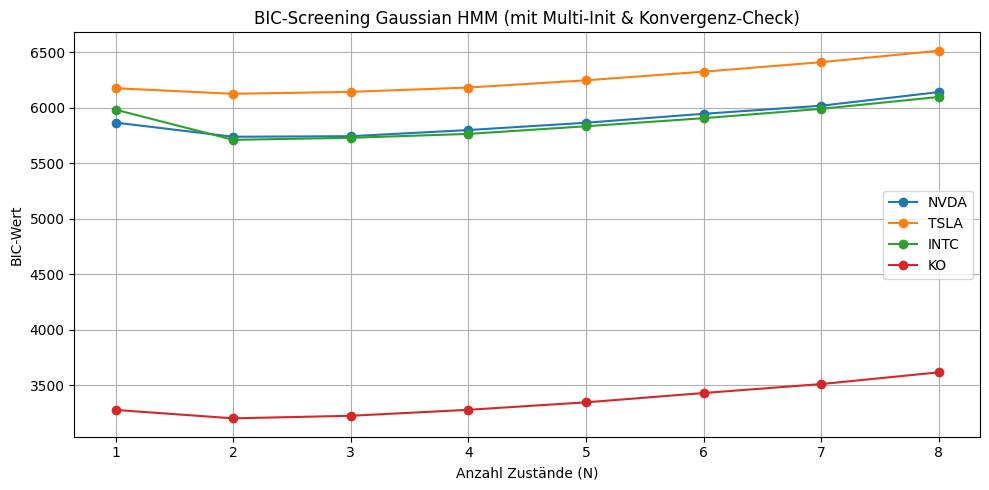

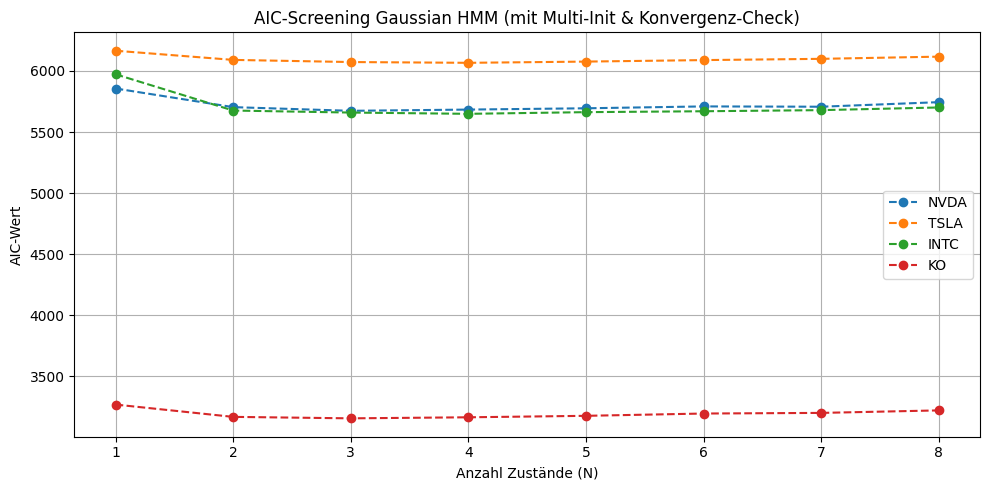


--- Bestes N nach BIC (Gaussian HMM) ---
   Ticker  N          BIC  Converged
17   INTC  2  5711.005139       True
25     KO  2  3201.028903       True
1    NVDA  2  5738.939289       True
9    TSLA  2  6126.017761       True

--- Bestes N nach AIC (Gaussian HMM) ---
   Ticker  N          AIC  Converged
19   INTC  4  5648.938331       True
26     KO  3  3153.825303       True
2    NVDA  3  5673.613722       True
11   TSLA  4  6066.905086       True

--- Vergleich Optima (BIC vs. AIC) ---
  Ticker  N_BIC          BIC  N_AIC          AIC
0   INTC      2  5711.005139      4  5648.938331
1     KO      2  3201.028903      3  3153.825303
2   NVDA      2  5738.939289      3  5673.613722
3   TSLA      2  6126.017761      4  6066.905086


In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
from hmmlearn import hmm
import matplotlib.pyplot as plt

# --- 1. DATEN-VORBEREITUNG --- #Ticker und Zeiträume initialisieren
tickers = ["NVDA", "TSLA", "INTC", "KO"]
start_date = "2022-01-01"
end_date = "2026-06-27"
data_container = {}
for ticker in tickers: #Ticker und Zeiträume ziehen
    # auto_adjust=True korrigiert Splits/Dividenden (wichtig für NVDA!)
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    returns = (np.log(df['Close']).diff() * 100).dropna() #leere Daten auslassen
    data_container[ticker] = returns.values.reshape(-1, 1) #gezogene Daten in den df packen


# --- 2. ERWEITERTE ANALYSIS-FUNKTIONEN ---
def calculate_aic_bic(log_likelihood, n_states, n_samples, n_var_params=2): #AIC/BIC mit Formeln berechnen
    # k = N^2 + N*n_var_params - 1
    # Bei Standard-Gauß (Mean+Var) ist n_var_params=2, also k = N^2 + 2N - 1
    k = n_states ** 2 + n_states * n_var_params - 1
    aic = -2 * log_likelihood + 2 * k
    bic = k * np.log(n_samples) - 2 * log_likelihood
    return aic, bic


def fit_best_of_n(X, n_states, n_inits=10, base_seed=42): #Über mehrere Initialisierungen prüfen, welches Modell das Beste war wegen lokaler Maxima
    """
    Fittet n_inits Modelle mit unterschiedlichen (aber reproduzierbaren) Seeds.
    Auswahlkriterium ist IMMER die beste Log-Likelihood ueber ALLE erfolgreichen
    Fits, unabhaengig von der Konvergenz. Konvergenz wird nur als Zusatz-Info
    mitgegeben (welcher Anteil der Versuche konvergiert ist, und ob das
    letztlich gewaehlte beste Modell konvergiert ist).
    """
    best_model = None
    best_ll = -np.inf
    best_converged = False
    n_converged = 0
    n_success = 0

    for i in range(n_inits):
        seed = base_seed + i #Startseed verschieben für Variable Konvergenz
        model = hmm.GaussianHMM(n_components=n_states, covariance_type="diag", #Modell init.
                                n_iter=300, tol=1e-4, random_state=seed)
        try:
            model.fit(X) #Modell fitten
        except Exception as e:
            print(f"    [WARN] N={n_states}, seed={seed}: Fit fehlgeschlagen ({e})")
            continue

        n_success += 1
        converged = model.monitor_.converged #Konvergenz prüfen
        if converged:
            n_converged += 1

        ll = model.score(X) #Likelihood berechnen
        if ll > best_ll:
            best_ll = ll
            best_model = model
            best_converged = converged

    if best_model is None:
        print(f"    [WARN] N={n_states}: Kein einziger der {n_inits} Fit-Versuche erfolgreich.")
        return None, False, np.nan, "0/0"

    return best_model, best_converged, best_ll, f"{n_converged}/{n_success}"


# --- 3. SCREENING-LOOP MIT MULTI-INIT ---
all_results = []
N_INITS = 10

for ticker in tickers: #Für jeden Ticker AIC/BIC berechnen und in Tabelle einfügen
    X = data_container[ticker]
    print(f"Analysiere {ticker}...")
    for n in range(1, 9): #Prüfen über 8 Zustände
        model, converged, ll, konv_quote = fit_best_of_n(X, n_states=n, n_inits=N_INITS, base_seed=42)
        if model is not None: #nur übernehmen, wenn ein Fit gelang
            aic, bic = calculate_aic_bic(ll, n, len(X)) #berechnen Kriterien
            all_results.append({ #Anhängen für späteren Plot
                'Ticker': ticker, 'N': n, 'AIC': aic, 'BIC': bic,
                'Converged': converged, 'Konv_Quote': konv_quote
            })
        else:
            all_results.append({ #Falls kein Fit: keine Kriterien
                'Ticker': ticker, 'N': n, 'AIC': np.nan, 'BIC': np.nan,
                'Converged': False, 'Konv_Quote': konv_quote
            })

# --- 4. ERGEBNIS-AUSWERTUNG --- #PLOT
results_df = pd.DataFrame(all_results)

non_converged = results_df[~results_df['Converged']]
if len(non_converged) > 0:
    print("\n[ACHTUNG] Folgende (Ticker, N)-Kombinationen sind selbst im besten Versuch NICHT konvergiert:")
    print(non_converged[['Ticker', 'N', 'Konv_Quote']])
    print("-> Ergebnisse mit Vorsicht interpretieren bzw. ggf. n_iter erhoehen.\n")

plt.figure(figsize=(10, 5))
for ticker in tickers:
    subset = results_df[results_df['Ticker'] == ticker]
    plt.plot(subset['N'], subset['BIC'], marker='o', label=ticker)
    non_conv = subset[subset['Converged'] == False]
    plt.scatter(non_conv['N'], non_conv['BIC'], color='red', marker='x', s=100, zorder=5)
plt.title("BIC-Screening Gaussian HMM (mit Multi-Init & Konvergenz-Check)")
plt.xlabel("Anzahl Zustände (N)")
plt.ylabel("BIC-Wert")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for ticker in tickers:
    subset = results_df[results_df['Ticker'] == ticker]
    plt.plot(subset['N'], subset['AIC'], marker='o', label=ticker, linestyle='--')
    non_conv = subset[subset['Converged'] == False]
    plt.scatter(non_conv['N'], non_conv['AIC'], color='red', marker='x', s=100, zorder=5)
plt.title("AIC-Screening Gaussian HMM (mit Multi-Init & Konvergenz-Check)")
plt.xlabel("Anzahl Zustände (N)")
plt.ylabel("AIC-Wert")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_bic = results_df.loc[results_df.groupby('Ticker')['BIC'].idxmin()] #Tabellen zur Auswertung der Kriterien
print("\n--- Bestes N nach BIC (Gaussian HMM) ---")
print(best_bic[['Ticker', 'N', 'BIC', 'Converged']])

best_aic = results_df.loc[results_df.groupby('Ticker')['AIC'].idxmin()]
print("\n--- Bestes N nach AIC (Gaussian HMM) ---")
print(best_aic[['Ticker', 'N', 'AIC', 'Converged']])

comparison = pd.merge(
    best_bic[['Ticker', 'N', 'BIC']],
    best_aic[['Ticker', 'N', 'AIC']],
    on='Ticker', suffixes=('_BIC', '_AIC')
)
print("\n--- Vergleich Optima (BIC vs. AIC) ---")
print(comparison)

Plot Vergleich Student-t vs Normal FAT_TAILS DIAGRAMM

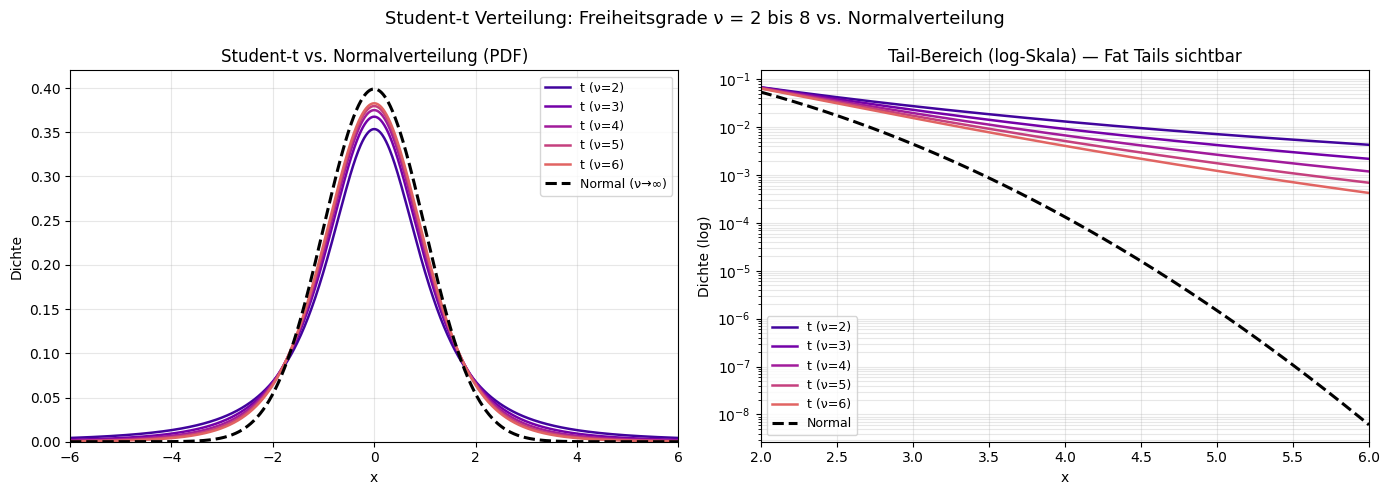

P(|X| > 3) — Wahrscheinlichkeit für extreme Renditen (>3σ):
  Normal:       0.002700
  t (ν=2):     0.095466  (35.4x häufiger als Normal)
  t (ν=3):     0.057669  (21.4x häufiger als Normal)
  t (ν=4):     0.039942  (14.8x häufiger als Normal)
  t (ν=5):     0.030099  (11.1x häufiger als Normal)
  t (ν=6):     0.024008  (8.9x häufiger als Normal)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as student_t, norm

x = np.linspace(-6, 6, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Links: alle Verteilungen übereinander ---
ax = axes[0]
colors = plt.cm.plasma(np.linspace(0.1, 0.85, 7))
for nu, color in zip(range(2, 7), colors):
    ax.plot(x, student_t.pdf(x, df=nu), color=color, linewidth=1.8, label=f"t (ν={nu})")
ax.plot(x, norm.pdf(x), color="black", linewidth=2.2, linestyle="--", label="Normal (ν→∞)")
ax.set_xlim(-6, 6)
ax.set_ylim(0, 0.42)
ax.set_title("Student-t vs. Normalverteilung (PDF)")
ax.set_xlabel("x")
ax.set_ylabel("Dichte")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Rechts: Tail-Zoom (|x| > 2) um Fat Tails zu sehen ---
ax = axes[1]
x_tail = np.linspace(2, 6, 500)
for nu, color in zip(range(2, 7), colors):
    ax.plot(x_tail, student_t.pdf(x_tail, df=nu), color=color, linewidth=1.8, label=f"t (ν={nu})")
ax.plot(x_tail, norm.pdf(x_tail), color="black", linewidth=2.2, linestyle="--", label="Normal")
ax.set_yscale("log")
ax.set_xlim(2, 6)
ax.set_title("Tail-Bereich (log-Skala) — Fat Tails sichtbar")
ax.set_xlabel("x")
ax.set_ylabel("Dichte (log)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which="both")

plt.suptitle("Student-t Verteilung: Freiheitsgrade ν = 2 bis 8 vs. Normalverteilung", fontsize=13)
plt.tight_layout()
plt.show()

# --- Zahlentabelle: Tail-Wahrscheinlichkeiten P(|X| > 3) ---
print("P(|X| > 3) — Wahrscheinlichkeit für extreme Renditen (>3σ):")
print(f"  Normal:       {2 * norm.sf(3):.6f}")
for nu in range(2, 7):
    print(f"  t (ν={nu}):     {2 * student_t.sf(3, df=nu):.6f}  ({2 * student_t.sf(3, df=nu) / (2 * norm.sf(3)):.1f}x häufiger als Normal)")

2016-2026 pomegranate t-Verteilung, nu=3,4,5,6

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



=== Screening nu=3 ===
  NVDA...
  TSLA...
  INTC...
  KO...

=== Screening nu=4 ===
  NVDA...
  TSLA...
  INTC...
  KO...

=== Screening nu=5 ===
  NVDA...
  TSLA...
  INTC...
  KO...

=== Screening nu=6 ===
  NVDA...
  TSLA...
  INTC...
  KO...


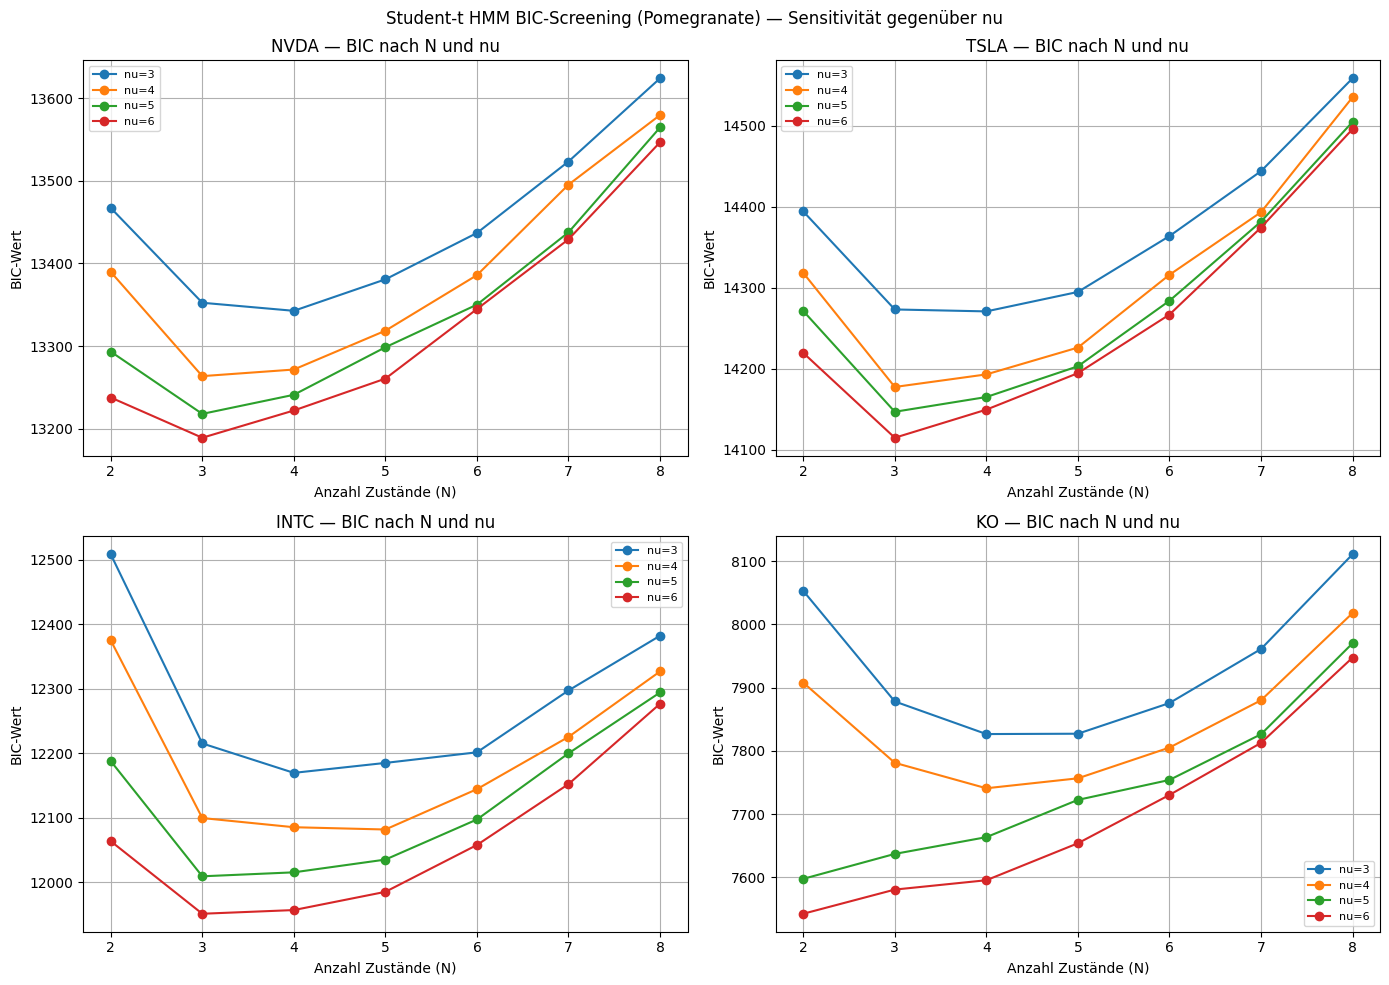


--- Bestes (N, nu) nach BIC pro Ticker (Student-t, Pomegranate) ---
Ticker  N  nu          BIC  LogLikelihood
  INTC  3   6 11951.213913   -5920.473145
    KO  2   6  7542.430199   -3743.648193
  NVDA  3   6 13189.000046   -6539.366211
  TSLA  3   6 14114.965867   -7002.349121


In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
from pomegranate.hmm import DenseHMM
from pomegranate.distributions import StudentT
import matplotlib.pyplot as plt

# --- 1. DATEN-VORBEREITUNG --- #Ticker und Zeiträume initialisieren
tickers = ["NVDA", "TSLA", "INTC", "KO"]
start_date = "2016-01-01"
end_date = "2026-06-27"
data_container = {}
for ticker in tickers: #Ticker und Zeiträume ziehen
    # auto_adjust=True korrigiert Splits/Dividenden (wichtig für NVDA!)
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    returns = (np.log(df['Close']).diff() * 100).dropna() #leere Daten auslassen
    data_container[ticker] = returns.values.reshape(-1, 1) #gezogene Daten in den df packen

# --- 2. FREIHEITSGRADE (NU) ---
# NU wird nicht aus den Daten geschaetzt, weil es dafuer kein geschlossenes
# Maximum-Likelihood-Update gibt. Stattdessen werden mehrere Kandidaten
# verglichen, um die Sensitivitaet der Ergebnisse gegenueber der Wahl von NU
# zu pruefen. Literaturwerte fuer Aktienrenditen liegen typischerweise bei 4-8.
NU_VALUES = [3, 4, 5, 6]


# --- 3. FUNKTIONEN ---
def calculate_aic_bic(log_likelihood, n_states, n_samples, n_var_params=2): #Methode zum AIC/BIC brechnen
    """
    k = N^2 + N*n_var_params - 1. n_var_params=2, weil NU fix vorgegeben
    ist und NICHT als freier Parameter mitgezaehlt wird. Damit ist k fuer das
    StudentT-Modell exakt gleich gross wie fuer das GaussianHMM mit gleicher
    Zustandszahl N -- Voraussetzung fuer einen fairen AIC/BIC-Vergleich
    zwischen beiden Verteilungsannahmen.
    """
    k = n_states ** 2 + n_states * n_var_params - 1
    aic = -2 * log_likelihood + 2 * k
    bic = k * np.log(n_samples) - 2 * log_likelihood
    return aic, bic


def build_studentt_hmm(n_states, nu, max_iter=300, tol=1e-4):
    distributions = [
        StudentT(dofs=nu, covariance_type="diag") #Erzeugt für jeden Zustand eine Student-t Verteilung
        for _ in range(n_states)
    ]
    return DenseHMM(distributions, max_iter=max_iter, tol=tol, verbose=False) #Pomegranate baut ein HMM aus allen Verteilungen/Zuständen


def assert_dofs_unchanged(model, nu, atol=1e-6): #Methode prüft, ob die Freiheitsgerade während des Trainings verändert wurden (nicht unbedingt notwendig)
    for i, dist in enumerate(model.distributions):
        current_dofs = dist.dofs
        if isinstance(current_dofs, torch.Tensor):
            current_dofs = current_dofs.detach().cpu().numpy()
        if not np.allclose(current_dofs, nu, atol=atol):
            print(f"    [WARN] Zustand {i}: dofs veraendert! Erwartet {nu}, gefunden {current_dofs}")
            return False
    return True


def fit_best_of_n(X_tensor, n_states, nu, n_inits=10, base_seed=42):
    best_model = None
    best_ll = -np.inf

    for i in range(n_inits): #für jede Initialisierung den Seed verschieben und KOnvergenz prüfen
        torch.manual_seed(base_seed + i)
        model = build_studentt_hmm(n_states, nu=nu)
        try:
            model.fit(X_tensor) #Modell trainieren
        except Exception as e: #Fehler
            print(f"    [WARN] N={n_states}, nu={nu}, seed={base_seed+i}: {e}")
            continue

        if not assert_dofs_unchanged(model, nu=nu):
            continue

        with torch.no_grad(): #Likelihood berechnen
            ll = model.log_probability(X_tensor).sum().item()

        if ll > best_ll: #beste LL aller Modelldurchläufe
            best_ll = ll
            best_model = model

    if best_model is None: #Betses Modell ausgeben
        print(f"    [WARN] N={n_states}, nu={nu}: Kein Fit erfolgreich.")
        return None, np.nan

    return best_model, best_ll


# --- 4. SCREENING ÜBER ALLE TICKER, N UND NU ---
all_results_t = []
N_INITS = 10

for nu in NU_VALUES: #Für alle NU und alle Ticker AIC/BIC berechnen
    print(f"\n=== Screening nu={nu} ===")
    for ticker in tickers:
        X = data_container[ticker]
        X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0)
        print(f"  {ticker}...")
        for n in range(2, 9): #Prüfen über die Zustände
            model, ll = fit_best_of_n(X_tensor, n_states=n, nu=nu, n_inits=N_INITS, base_seed=42)
            if model is not None: #nur übernehmen, wenn ein Fit gelang
                aic, bic = calculate_aic_bic(ll, n, len(X), n_var_params=2) #berechnen Kriterien
                all_results_t.append({'Ticker': ticker, 'N': n, 'nu': nu, #Anhängen für späteren Plot
                                      'AIC': aic, 'BIC': bic, 'LogLikelihood': ll})
            else:
                all_results_t.append({'Ticker': ticker, 'N': n, 'nu': nu, #Falls kein Fit: keine Kriterien
                                      'AIC': np.nan, 'BIC': np.nan, 'LogLikelihood': np.nan})

results_t_df = pd.DataFrame(all_results_t)

# --- 5. PLOTS: BIC PRO TICKER, EINE LINIE PRO NU --- #PLOT
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, ticker in zip(axes, tickers):
    for nu in NU_VALUES:
        subset = results_t_df[(results_t_df['Ticker'] == ticker) & (results_t_df['nu'] == nu)]
        ax.plot(subset['N'], subset['BIC'], marker='o', label=f"nu={nu}")
    ax.set_title(f"{ticker} — BIC nach N und nu")
    ax.set_xlabel("Anzahl Zustände (N)")
    ax.set_ylabel("BIC-Wert")
    ax.legend(fontsize=8)
    ax.grid(True)
plt.suptitle("Student-t HMM BIC-Screening (Pomegranate) — Sensitivität gegenüber nu")
plt.tight_layout()
plt.show()

# --- 6. ZUSAMMENFASSUNG: BESTES (N, NU) PRO TICKER NACH BIC ---
best_overall = results_t_df.loc[results_t_df.groupby('Ticker')['BIC'].idxmin()] #Tabelle zur Auswertung der Kriterien
print("\n--- Bestes (N, nu) nach BIC pro Ticker (Student-t, Pomegranate) ---")
print(best_overall[['Ticker', 'N', 'nu', 'BIC', 'LogLikelihood']].to_string(index=False))


2010-2026 pomegranate t-Verteilung, nu=3,4,5,6

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


=== Screening nu=3 ===
  NVDA...


  TSLA...
  INTC...
  KO...

=== Screening nu=4 ===
  NVDA...
  TSLA...
  INTC...
  KO...

=== Screening nu=5 ===
  NVDA...
  TSLA...
  INTC...
  KO...
    [WARN] N=6, nu=5, seed=48: index 0 is out of bounds for dimension 0 with size 0

=== Screening nu=6 ===
  NVDA...
  TSLA...
  INTC...
  KO...


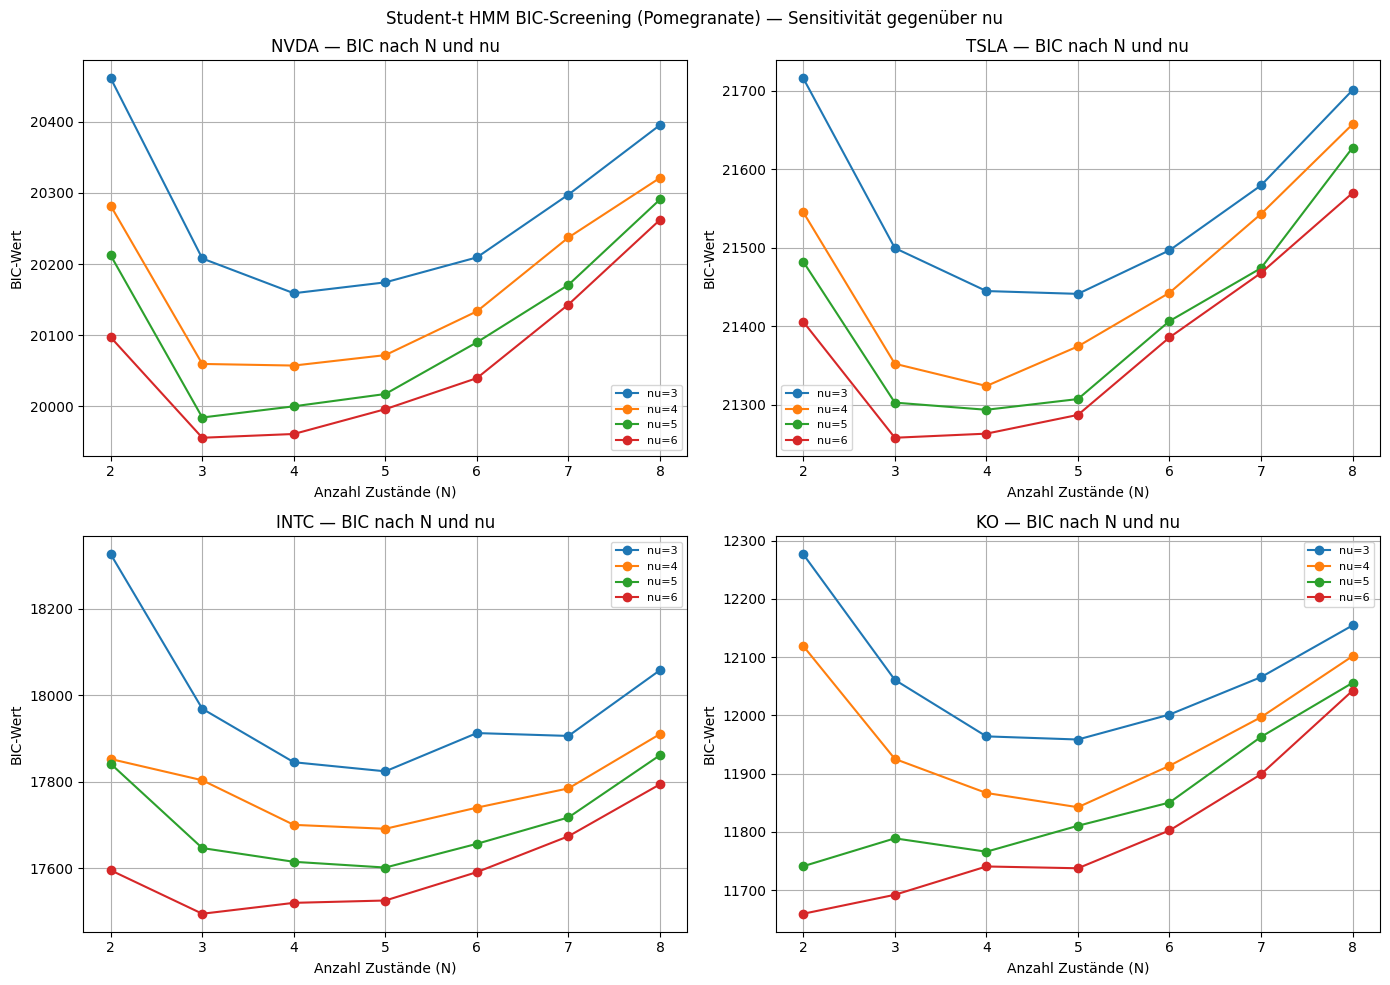


--- Bestes (N, nu) nach BIC pro Ticker (Student-t, Pomegranate) ---
Ticker  N  nu          BIC  LogLikelihood
  INTC  3   6 17494.811054   -8689.099609
    KO  2   6 11659.345957   -5800.520020
  NVDA  3   6 19955.881366   -9919.634766
  TSLA  3   6 21258.185671  -10570.996094


In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
from pomegranate.hmm import DenseHMM
from pomegranate.distributions import StudentT
import matplotlib.pyplot as plt
#ALLES GLEICH WIE OBEN NUR ANDERER ZEITRAUM
# --- 1. DATEN-VORBEREITUNG --- #Ticker und Zeiträume initialisieren
tickers = ["NVDA", "TSLA", "INTC", "KO"]
start_date = "2010-01-01"
end_date = "2026-06-27"
data_container = {}
for ticker in tickers: #Ticker und Zeiträume ziehen
    # auto_adjust=True korrigiert Splits/Dividenden (wichtig für NVDA!)
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    returns = (np.log(df['Close']).diff() * 100).dropna() #leere Daten auslassen
    data_container[ticker] = returns.values.reshape(-1, 1) #gezogene Daten in den df packen

# --- 2. FREIHEITSGRADE (NU) ---
# NU wird nicht aus den Daten geschaetzt, weil es dafuer kein geschlossenes
# Maximum-Likelihood-Update gibt. Stattdessen werden mehrere Kandidaten
# verglichen, um die Sensitivitaet der Ergebnisse gegenueber der Wahl von NU
# zu pruefen. Literaturwerte fuer Aktienrenditen liegen typischerweise bei 4-8.
NU_VALUES = [3, 4, 5, 6]


# --- 3. FUNKTIONEN ---
def calculate_aic_bic(log_likelihood, n_states, n_samples, n_var_params=2):
    """
    k = N^2 + N*n_var_params - 1. n_var_params=2, weil NU fix vorgegeben
    ist und NICHT als freier Parameter mitgezaehlt wird. Damit ist k fuer das
    StudentT-Modell exakt gleich gross wie fuer das GaussianHMM mit gleicher
    Zustandszahl N -- Voraussetzung fuer einen fairen AIC/BIC-Vergleich
    zwischen beiden Verteilungsannahmen.
    """
    k = n_states ** 2 + n_states * n_var_params - 1
    aic = -2 * log_likelihood + 2 * k
    bic = k * np.log(n_samples) - 2 * log_likelihood
    return aic, bic


def build_studentt_hmm(n_states, nu, max_iter=300, tol=1e-4):
    distributions = [
        StudentT(dofs=nu, covariance_type="diag")
        for _ in range(n_states)
    ]
    return DenseHMM(distributions, max_iter=max_iter, tol=tol, verbose=False)


def assert_dofs_unchanged(model, nu, atol=1e-6):
    for i, dist in enumerate(model.distributions):
        current_dofs = dist.dofs
        if isinstance(current_dofs, torch.Tensor):
            current_dofs = current_dofs.detach().cpu().numpy()
        if not np.allclose(current_dofs, nu, atol=atol):
            print(f"    [WARN] Zustand {i}: dofs veraendert! Erwartet {nu}, gefunden {current_dofs}")
            return False
    return True


def fit_best_of_n(X_tensor, n_states, nu, n_inits=10, base_seed=42):
    best_model = None
    best_ll = -np.inf

    for i in range(n_inits):
        torch.manual_seed(base_seed + i)
        model = build_studentt_hmm(n_states, nu=nu)
        try:
            model.fit(X_tensor)
        except Exception as e:
            print(f"    [WARN] N={n_states}, nu={nu}, seed={base_seed+i}: {e}")
            continue

        if not assert_dofs_unchanged(model, nu=nu):
            continue

        with torch.no_grad():
            ll = model.log_probability(X_tensor).sum().item()

        if ll > best_ll:
            best_ll = ll
            best_model = model

    if best_model is None:
        print(f"    [WARN] N={n_states}, nu={nu}: Kein Fit erfolgreich.")
        return None, np.nan

    return best_model, best_ll


# --- 4. SCREENING ÜBER ALLE TICKER, N UND NU ---
all_results_t = []
N_INITS = 10

for nu in NU_VALUES:
    print(f"\n=== Screening nu={nu} ===")
    for ticker in tickers:
        X = data_container[ticker]
        X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0)
        print(f"  {ticker}...")
        for n in range(2, 9): #Prüfen über die Zustände
            model, ll = fit_best_of_n(X_tensor, n_states=n, nu=nu, n_inits=N_INITS, base_seed=42)
            if model is not None: #nur übernehmen, wenn ein Fit gelang
                aic, bic = calculate_aic_bic(ll, n, len(X), n_var_params=2) #berechnen Kriterien
                all_results_t.append({'Ticker': ticker, 'N': n, 'nu': nu, #Anhängen für späteren Plot
                                      'AIC': aic, 'BIC': bic, 'LogLikelihood': ll})
            else:
                all_results_t.append({'Ticker': ticker, 'N': n, 'nu': nu, #Falls kein Fit: keine Kriterien
                                      'AIC': np.nan, 'BIC': np.nan, 'LogLikelihood': np.nan})

results_t_df = pd.DataFrame(all_results_t)

# --- 5. PLOTS: BIC PRO TICKER, EINE LINIE PRO NU --- #PLOT
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, ticker in zip(axes, tickers):
    for nu in NU_VALUES:
        subset = results_t_df[(results_t_df['Ticker'] == ticker) & (results_t_df['nu'] == nu)]
        ax.plot(subset['N'], subset['BIC'], marker='o', label=f"nu={nu}")
    ax.set_title(f"{ticker} — BIC nach N und nu")
    ax.set_xlabel("Anzahl Zustände (N)")
    ax.set_ylabel("BIC-Wert")
    ax.legend(fontsize=8)
    ax.grid(True)
plt.suptitle("Student-t HMM BIC-Screening (Pomegranate) — Sensitivität gegenüber nu")
plt.tight_layout()
plt.show()

# --- 6. ZUSAMMENFASSUNG: BESTES (N, NU) PRO TICKER NACH BIC ---
best_overall = results_t_df.loc[results_t_df.groupby('Ticker')['BIC'].idxmin()] #Tabelle zur Auswertung der Kriterien
print("\n--- Bestes (N, nu) nach BIC pro Ticker (Student-t, Pomegranate) ---")
print(best_overall[['Ticker', 'N', 'nu', 'BIC', 'LogLikelihood']].to_string(index=False))


2022-2026 pomegranate t-Verteilung, nu=3,4,5,6

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



=== Screening nu=3 ===
  NVDA...
  TSLA...
  INTC...
  KO...

=== Screening nu=4 ===
  NVDA...
  TSLA...
  INTC...
  KO...

=== Screening nu=5 ===
  NVDA...
  TSLA...
  INTC...
  KO...

=== Screening nu=6 ===
  NVDA...
  TSLA...
  INTC...
  KO...


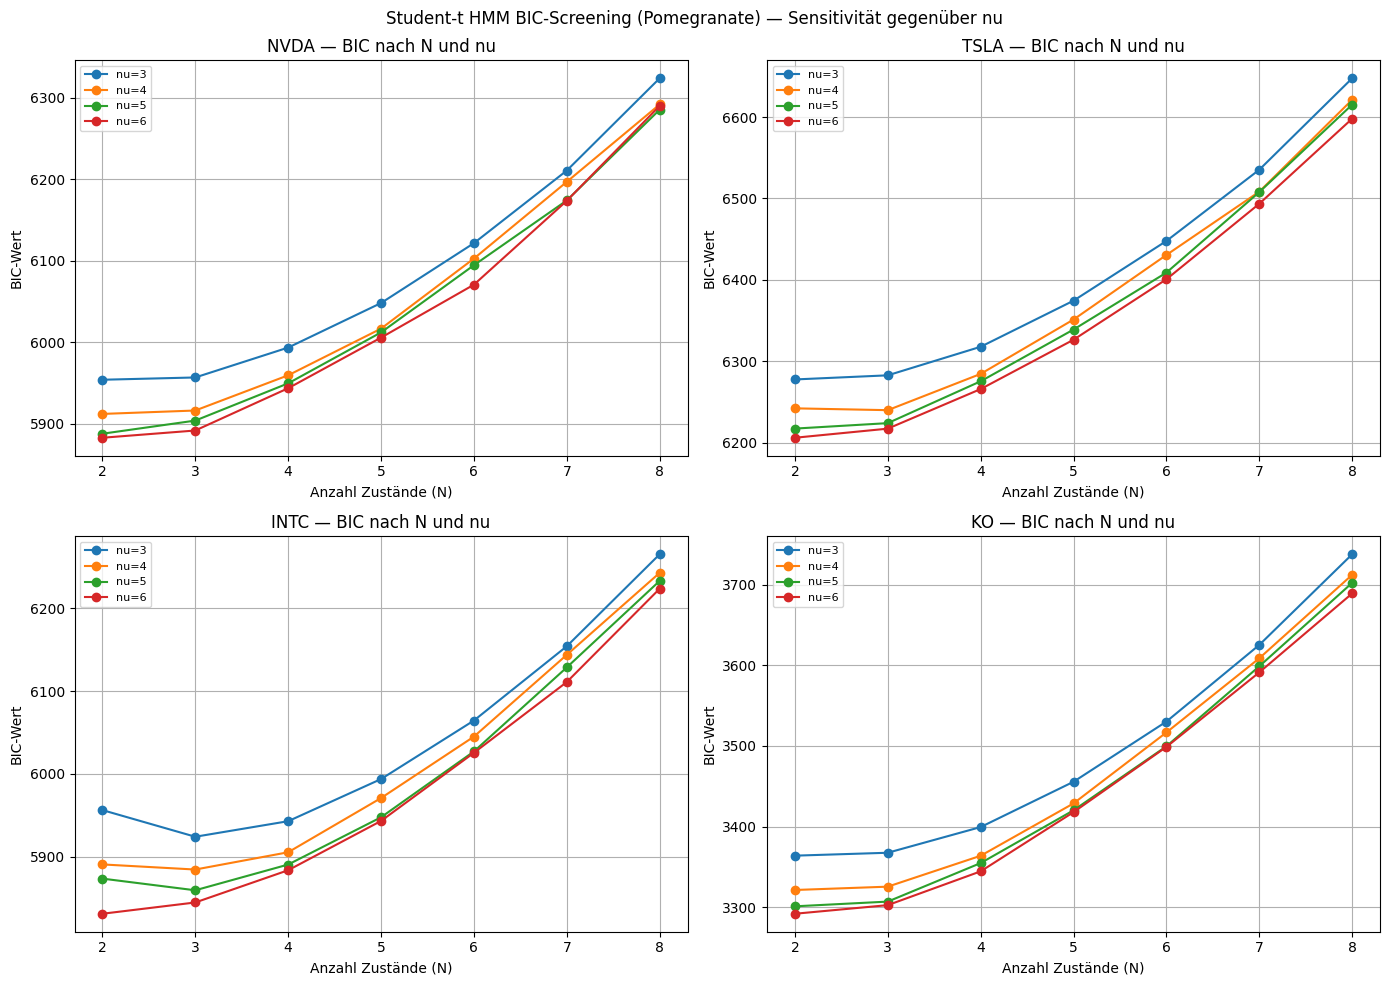


--- Bestes (N, nu) nach BIC pro Ticker (Student-t, Pomegranate) ---
Ticker  N  nu         BIC  LogLikelihood
  INTC  2   6 5830.830375   -2890.832031
    KO  2   6 3291.773002   -1621.303345
  NVDA  2   6 5883.040824   -2916.937256
  TSLA  2   6 6206.386528   -3078.610107


In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
from pomegranate.hmm import DenseHMM
from pomegranate.distributions import StudentT
import matplotlib.pyplot as plt
#ALLES WIE DIE LETZTEN BEIDEN NUR ANDERER ZEITRAUM
# --- 1. DATEN-VORBEREITUNG --- #Ticker und Zeiträume initialisieren
tickers = ["NVDA", "TSLA", "INTC", "KO"]
start_date = "2022-01-01"
end_date = "2026-06-27"
data_container = {}
for ticker in tickers: #Ticker und Zeiträume ziehen
    # auto_adjust=True korrigiert Splits/Dividenden (wichtig für NVDA!)
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    returns = (np.log(df['Close']).diff() * 100).dropna() #leere Daten auslassen
    data_container[ticker] = returns.values.reshape(-1, 1) #gezogene Daten in den df packen

# --- 2. FREIHEITSGRADE (NU) ---
# NU wird nicht aus den Daten geschaetzt, weil es dafuer kein geschlossenes
# Maximum-Likelihood-Update gibt. Stattdessen werden mehrere Kandidaten
# verglichen, um die Sensitivitaet der Ergebnisse gegenueber der Wahl von NU
# zu pruefen. Literaturwerte fuer Aktienrenditen liegen typischerweise bei 4-8.
NU_VALUES = [3, 4, 5, 6]


# --- 3. FUNKTIONEN ---
def calculate_aic_bic(log_likelihood, n_states, n_samples, n_var_params=2):
    """
    k = N^2 + N*n_var_params - 1. n_var_params=2, weil NU fix vorgegeben
    ist und NICHT als freier Parameter mitgezaehlt wird. Damit ist k fuer das
    StudentT-Modell exakt gleich gross wie fuer das GaussianHMM mit gleicher
    Zustandszahl N -- Voraussetzung fuer einen fairen AIC/BIC-Vergleich
    zwischen beiden Verteilungsannahmen.
    """
    k = n_states ** 2 + n_states * n_var_params - 1
    aic = -2 * log_likelihood + 2 * k
    bic = k * np.log(n_samples) - 2 * log_likelihood
    return aic, bic


def build_studentt_hmm(n_states, nu, max_iter=300, tol=1e-4):
    distributions = [
        StudentT(dofs=nu, covariance_type="diag")
        for _ in range(n_states)
    ]
    return DenseHMM(distributions, max_iter=max_iter, tol=tol, verbose=False)


def assert_dofs_unchanged(model, nu, atol=1e-6):
    for i, dist in enumerate(model.distributions):
        current_dofs = dist.dofs
        if isinstance(current_dofs, torch.Tensor):
            current_dofs = current_dofs.detach().cpu().numpy()
        if not np.allclose(current_dofs, nu, atol=atol):
            print(f"    [WARN] Zustand {i}: dofs veraendert! Erwartet {nu}, gefunden {current_dofs}")
            return False
    return True


def fit_best_of_n(X_tensor, n_states, nu, n_inits=10, base_seed=42):
    best_model = None
    best_ll = -np.inf

    for i in range(n_inits):
        torch.manual_seed(base_seed + i)
        model = build_studentt_hmm(n_states, nu=nu)
        try:
            model.fit(X_tensor)
        except Exception as e:
            print(f"    [WARN] N={n_states}, nu={nu}, seed={base_seed+i}: {e}")
            continue

        if not assert_dofs_unchanged(model, nu=nu):
            continue

        with torch.no_grad():
            ll = model.log_probability(X_tensor).sum().item()

        if ll > best_ll:
            best_ll = ll
            best_model = model

    if best_model is None:
        print(f"    [WARN] N={n_states}, nu={nu}: Kein Fit erfolgreich.")
        return None, np.nan

    return best_model, best_ll


# --- 4. SCREENING ÜBER ALLE TICKER, N UND NU ---
all_results_t = []
N_INITS = 10

for nu in NU_VALUES:
    print(f"\n=== Screening nu={nu} ===")
    for ticker in tickers:
        X = data_container[ticker]
        X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0)
        print(f"  {ticker}...")
        for n in range(2, 9): #Prüfen über die Zustände
            model, ll = fit_best_of_n(X_tensor, n_states=n, nu=nu, n_inits=N_INITS, base_seed=42)
            if model is not None: #nur übernehmen, wenn ein Fit gelang
                aic, bic = calculate_aic_bic(ll, n, len(X), n_var_params=2) #berechnen Kriterien
                all_results_t.append({'Ticker': ticker, 'N': n, 'nu': nu, #Anhängen für späteren Plot
                                      'AIC': aic, 'BIC': bic, 'LogLikelihood': ll})
            else:
                all_results_t.append({'Ticker': ticker, 'N': n, 'nu': nu, #Falls kein Fit: keine Kriterien
                                      'AIC': np.nan, 'BIC': np.nan, 'LogLikelihood': np.nan})

results_t_df = pd.DataFrame(all_results_t)

# --- 5. PLOTS: BIC PRO TICKER, EINE LINIE PRO NU --- #PLOT
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, ticker in zip(axes, tickers):
    for nu in NU_VALUES:
        subset = results_t_df[(results_t_df['Ticker'] == ticker) & (results_t_df['nu'] == nu)]
        ax.plot(subset['N'], subset['BIC'], marker='o', label=f"nu={nu}")
    ax.set_title(f"{ticker} — BIC nach N und nu")
    ax.set_xlabel("Anzahl Zustände (N)")
    ax.set_ylabel("BIC-Wert")
    ax.legend(fontsize=8)
    ax.grid(True)
plt.suptitle("Student-t HMM BIC-Screening (Pomegranate) — Sensitivität gegenüber nu")
plt.tight_layout()
plt.show()

# --- 6. ZUSAMMENFASSUNG: BESTES (N, NU) PRO TICKER NACH BIC ---
best_overall = results_t_df.loc[results_t_df.groupby('Ticker')['BIC'].idxmin()] #Tabelle zur Auswertung der Kriterien
print("\n--- Bestes (N, nu) nach BIC pro Ticker (Student-t, Pomegranate) ---")
print(best_overall[['Ticker', 'N', 'nu', 'BIC', 'LogLikelihood']].to_string(index=False))


Gaussian HMM Forecast — 1. Daten (Train 2016–2024 / Test 2025–2026)

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

TICKERS = ["NVDA", "TSLA", "INTC", "KO"] #Ticker und Zeiträume initialisieren
TRAIN_START = "2016-01-01"
TRAIN_END   = "2023-12-31"
TEST_START  = "2024-01-01"
TEST_END    = "2026-06-27"

data_train   = {}
data_test    = {}
dates_test   = {}
prices_test  = {}   # tatsächliche Schlusskurse im Testzeitraum (für Kurs-Charts)
price_anchor = {}   # Schlusskurs am letzten Trainingstag (Startpunkt der Rekonstruktion)

for ticker in TICKERS: #Tickerdaten vorbereiten
    df = yf.download(ticker, start=TRAIN_START, end=TEST_END, #download
                     auto_adjust=True, progress=False)
    close   = df['Close'] #Schlusskurse ziehen nach close
    log_ret = (np.log(close).diff() * 100).dropna() #log returns berechnen
    mask_train = log_ret.index < TEST_START #TRUE für alle Indizes in den Trainingsdaten
    mask_test  = log_ret.index >= TEST_START #TRUE für alle Indizes in den Testdaten
    train_dates = log_ret.index[mask_train] #Trainingsdatum
    test_dates  = log_ret.index[mask_test] #Testdatum
    data_train[ticker]   = log_ret[mask_train].values.reshape(-1, 1) #Foramtieren
    data_test[ticker]    = log_ret[mask_test].values.reshape(-1, 1)
    dates_test[ticker]   = test_dates
    prices_test[ticker]  = close.loc[test_dates].values.flatten()
    price_anchor[ticker] = float(close.loc[train_dates[-1]])
    n_tr = len(data_train[ticker])
    n_te = len(data_test[ticker])
    split_pct = n_tr / (n_tr + n_te) * 100 #Verteilung Traings- zu Testdaten (Overfitting vermeiden)
    print(f"{ticker}: {n_tr} Trainings- / {n_te} Testtage  ({split_pct:.0f}/{100-split_pct:.0f} Split)")


/var/folders/jv/9jcl56g95fn4wq9fpfgyd3h40000gn/T/ipykernel_16166/2614868.py:30: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price_anchor[ticker] = float(close.loc[train_dates[-1]])


NVDA: 2011 Trainings- / 623 Testtage  (76/24 Split)


/var/folders/jv/9jcl56g95fn4wq9fpfgyd3h40000gn/T/ipykernel_16166/2614868.py:30: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price_anchor[ticker] = float(close.loc[train_dates[-1]])


TSLA: 2011 Trainings- / 623 Testtage  (76/24 Split)


/var/folders/jv/9jcl56g95fn4wq9fpfgyd3h40000gn/T/ipykernel_16166/2614868.py:30: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price_anchor[ticker] = float(close.loc[train_dates[-1]])


INTC: 2011 Trainings- / 623 Testtage  (76/24 Split)
KO: 2011 Trainings- / 623 Testtage  (76/24 Split)


/var/folders/jv/9jcl56g95fn4wq9fpfgyd3h40000gn/T/ipykernel_16166/2614868.py:30: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price_anchor[ticker] = float(close.loc[train_dates[-1]])


Gaussian HMM Forecast — 2. Parameter-Schätzung A, B, π (1σ-Schwellen)

In [14]:
import numpy as np

N_STATES   = 3
SIGMA_MULT = 1.0   # 1σ-Schwellen: Bear < μ-σ, Normal ±σ, Bull > μ+σ


def estimate_init_params(returns_flat, n_states=3, sigma_mult=1.0): #A,B,pi schätzen auf den Trainingsdaten
    """Schätzt π, A, B aus Trainingsdaten via σ-Schwellen (ohne Baum-Welch)."""
    mu    = returns_flat.mean() #Std. und MW. von den returns berechnen
    sigma = returns_flat.std()

    # Vorläufige Zustandszuweisung: 0=Bear, 1=Normal, 2=Bull
    states = np.where(returns_flat < mu - sigma_mult * sigma, 0, #Zustände festlegen
             np.where(returns_flat > mu + sigma_mult * sigma, 2, 1))

    # π (Startverteilung): Anteil jedes Zustands
    pi = np.bincount(states, minlength=n_states) / len(states) #Prozentuale Anteile an den Zuständen bestimmen

    # A (Übergangsmatrix): gezählte Übergänge, zeilenweise normiert
    A = np.zeros((n_states, n_states))
    for t in range(len(states) - 1): #Schleifen berechnen alle Übergänge von returns zwischen je zwei Tagen
        A[states[t], states[t + 1]] += 1
    for i in range(n_states):
        s = A[i].sum()
        A[i] = A[i] / s if s > 0 else 1.0 / n_states   # nie besuchter Zustand -> uniform

    # B (Emissionsparameter): μ_j, σ_j je Zustand (σ mit kleinem Floor gegen 0)
    mu_j    = np.array([returns_flat[states == j].mean() if (states == j).any() else mu #spezifisch für Zustand MW und Stabw. berechnen
                        for j in range(n_states)])
    sigma_j = np.array([max(returns_flat[states == j].std(), 1e-4) if (states == j).any() else sigma
                        for j in range(n_states)])

    return pi, A, mu_j, sigma_j, states


init_params = {}
labels = ["Bear", "Normal", "Bull"]

for ticker in TICKERS: #für jeden Ticker Methoden oben aufrufen
    X_flat = data_train[ticker].flatten()
    pi, A, mu_j, sigma_j, _ = estimate_init_params(X_flat, N_STATES, SIGMA_MULT)
    init_params[ticker] = dict(pi=pi, A=A, mu=mu_j, sigma=sigma_j)

    print(f"\n=== {ticker} — Initiale Parameter (σ-Schwellen, 1σ) ===")
    print(f"  π  : {dict(zip(labels, pi.round(3)))}")
    for j, lbl in enumerate(labels):
        print(f"  {lbl:<6}: μ = {mu_j[j]:+.4f}%   σ = {sigma_j[j]:.4f}%")
    print("  Übergangsmatrix A (Zeile = Von, Spalte = Nach):")
    print("        " + "".join(f"{l:>9}" for l in labels))
    for i, lbl in enumerate(labels):
        print(f"  {lbl:<6}" + "".join(f"{A[i,j]:>9.4f}" for j in range(N_STATES)))



=== NVDA — Initiale Parameter (σ-Schwellen, 1σ) ===
  π  : {'Bear': np.float64(0.123), 'Normal': np.float64(0.765), 'Bull': np.float64(0.112)}
  Bear  : μ = -5.0082%   σ = 2.3676%
  Normal: μ = +0.2725%   σ = 1.4817%
  Bull  : μ = +5.4503%   σ = 2.6952%
  Übergangsmatrix A (Zeile = Von, Spalte = Nach):
             Bear   Normal     Bull
  Bear     0.1498   0.6518   0.1984
  Normal   0.1152   0.7866   0.0982
  Bull     0.1460   0.7389   0.1150

=== TSLA — Initiale Parameter (σ-Schwellen, 1σ) ===
  π  : {'Bear': np.float64(0.109), 'Normal': np.float64(0.778), 'Bull': np.float64(0.113)}
  Bear  : μ = -6.3596%   σ = 3.0826%
  Normal: μ = +0.1383%   σ = 1.7714%
  Bull  : μ = +6.4218%   σ = 2.7966%
  Übergangsmatrix A (Zeile = Von, Spalte = Nach):
             Bear   Normal     Bull
  Bear     0.1416   0.7032   0.1553
  Normal   0.1042   0.7960   0.0997
  Bull     0.1101   0.7269   0.1630

=== INTC — Initiale Parameter (σ-Schwellen, 1σ) ===
  π  : {'Bear': np.float64(0.105), 'Normal': np.f

Gaussian HMM Forecast — 3. Modell-Fit (Baum-Welch, N=3)

In [15]:
from hmmlearn import hmm
import numpy as np

fitted_models = {}
state_names   = ["Bear", "Normal", "Bull"]

for ticker in TICKERS: #für alle Ticker das Modell initialisieren
    p       = init_params[ticker]
    X_train = data_train[ticker]

    model = hmm.GaussianHMM(
        n_components=N_STATES,
        covariance_type="diag",
        n_iter=500,
        tol=1e-4,
        init_params="",   # keine Auto-Initialisierung — A/B/π setzen wir selbst
        params="stmc",    # Baum-Welch optimiert startprob, transmat, means, covars
    )

    # Datenbasierte Startwerte (aus Zelle 2) übergeben
    model.startprob_ = p["pi"]
    model.transmat_  = p["A"]
    model.means_     = p["mu"].reshape(-1, 1)
    model.covars_    = (p["sigma"] ** 2).reshape(-1, 1)   # diag: Shape (N, n_features)

    model.fit(X_train) #Modell trainieren
    fitted_models[ticker] = model #Modelle in einen Vektor

    # --- Ausgabe nach Fit (Zustände nach μ sortiert: Bear < Normal < Bull) ---
    mu_fit    = model.means_.flatten()
    sigma_fit = np.sqrt(model.covars_.flatten())
    order     = np.argsort(mu_fit)

    print(f"\n=== {ticker} — Gefittete Parameter ===")
    print(f"  Konvergiert: {model.monitor_.converged}   "
          f"LL(Training) = {model.score(X_train):.1f}")
    for rank, idx in enumerate(order):
        print(f"  {state_names[rank]:<6} (Zustand {idx}): "
              f"μ = {mu_fit[idx]:+.4f}%   σ = {sigma_fit[idx]:.4f}%")
    print("  Übergangsmatrix A (nach Fit):")
    A_fit = model.transmat_
    for i in range(N_STATES):
        print("    " + "  ".join(f"{A_fit[i, j]:.4f}" for j in range(N_STATES)))



=== NVDA — Gefittete Parameter ===
  Konvergiert: True   LL(Training) = -4861.7
  Bear   (Zustand 0): μ = -0.0619%   σ = 3.7579%
  Normal (Zustand 1): μ = +0.3413%   σ = 1.8665%
  Bull   (Zustand 2): μ = +1.6018%   σ = 11.5620%
  Übergangsmatrix A (nach Fit):
    0.9372  0.0477  0.0151
    0.0255  0.9684  0.0062
    0.5466  0.0781  0.3753

=== TSLA — Gefittete Parameter ===
  Konvergiert: True   LL(Training) = -5221.3
  Bear   (Zustand 0): μ = -0.4968%   σ = 8.1938%
  Normal (Zustand 2): μ = +0.1708%   σ = 4.1931%
  Bull   (Zustand 1): μ = +0.1967%   σ = 2.1431%
  Übergangsmatrix A (nach Fit):
    0.4532  0.2638  0.2830
    0.0395  0.9605  0.0000
    0.0423  0.0142  0.9435

=== INTC — Gefittete Parameter ===
  Konvergiert: True   LL(Training) = -4023.2
  Bear   (Zustand 0): μ = -0.5859%   σ = 6.2166%
  Normal (Zustand 2): μ = +0.0136%   σ = 2.1398%
  Bull   (Zustand 1): μ = +0.1165%   σ = 1.0557%
  Übergangsmatrix A (nach Fit):
    0.5511  0.1679  0.2810
    0.0196  0.9706  0.0098
   

Gaussian HMM Forecast — 4. Forecast (Methode 1 + 2, Fenster 1/5/20, Horizont 1/5 Tage)

In [16]:
import numpy as np

WINDOW_SIZES = [1, 5, 20]   # Rückblick-Fenster: 1 Tag, 1 Woche, ~1 Monat
HORIZONS     = [1, 5, 20]   # Prognose voraus: 1 Tag, 1 Woche, ~1 Monat
# Hinweis: Für H=20 wird Methode 2 nahezu konstant — die Zustandsverteilung A^k·γ
# konvergiert über 20 Schritte gegen den stationären Zustand. Bewusst so (Befund).


def regime_posterior(model, window):
    """P(Zustand | Fenster) am letzten Tag des Fensters (Forward-Backward). Für M2.""" #Wie ist die Zusandsvereteilung zum Ende des Zeitfensters
    _, posterior = model.score_samples(window.reshape(-1, 1))
    return posterior[-1]


def window_loglik(model, seq):
    """Skalare Log-Likelihood einer Beobachtungssequenz (Nguyen-2017-Musterabgleich, M1)."""
    return model.score(seq.reshape(-1, 1)) #Breechnet die Log Likelihood der Returns in seq


def expected_return(model, gamma, H): #prognostiziere die Rendite mit der neuen Methode
    mu_states = model.means_.flatten()
    A         = model.transmat_
    dist, total = gamma.copy(), 0.0
    for _ in range(H):
        dist   = A.T @ dist          # einen Tag weiter
        most_likely_state = np.argmax(dist) #bestimme den wahrscheinlichsten Zustand
        total += mu_states[most_likely_state]    # addiere erwarteter Return dieses Tages
    return float(total)


# ── Haupt-Forecast-Loop ──────────────────────────────────────────────────────
all_forecasts = {}

for ticker in TICKERS: #pro Ticker Modell ziehen
    model   = fitted_models[ticker]
    X_train = data_train[ticker].flatten()
    X_test  = data_test[ticker].flatten()
    X_all   = np.concatenate([X_train, X_test])
    T_train, T_test = len(X_train), len(X_test)

    results = {}
    for W in WINDOW_SIZES:
        print(f"  {ticker}  W={W:2d} ...", flush=True) #Was analysiert die Methode gerade
        total_windows = len(X_all) - W + 1 #berechne zum Zeit sparen vorher schon alle Likelihoods, verwendet werden später nur bekannte
        all_ll = np.array([
            window_loglik(model, X_all[s: s + W]) for s in range(total_windows) ])

        gammas = np.array([  # M2: gefensterte Zustandsverteilung je Testtag (einmal, für alle H wiederverwendet)
            regime_posterior(model, X_all[T_train + t - W: T_train + t])
            for t in range(T_test)
        ])  # Shape (T_test, N)

        # M1 (Nguyen 2017): skalare Log-Likelihoods — H-unabhängig, daher einmal je (Ticker, W)
        #   L_test[t]  : LL des aktuellen (kausalen) Testfensters, endet am Vortag
        #   L_train[s] : LL des rollierenden Trainingsfensters X_train[s:s+W]
        L_test = np.array([
            window_loglik(model, X_all[T_train + t - W: T_train + t])
            for t in range(T_test)
        ])
        L_train = np.array([
            window_loglik(model, X_train[s: s + W])
            for s in range(T_train - W + 1)
        ])
        # M1 (neu): EIN Analogfenster je Testtag (H-unabhängig) — dieselbe Analogie für alle
        # Horizonte. Kandidaten müssen den größten Horizont zulassen (Hmax Folgetage).
        cand_ll = L_train[: T_train - W - max(HORIZONS) + 1]
        s_of_t  = np.array([int(np.argmin(np.abs(cand_ll - L_test[t]))) for t in range(T_test)])

        for H in HORIZONS:
            m1_preds = np.full(T_test, np.nan) #für die Vorhersagen leere Arrays erzeugen
            m2_preds = np.full(T_test, np.nan)
            actuals  = np.full(T_test, np.nan)

            for t in range(T_test - H):
                current_idx_all = T_train + t
                # Methode 1 (Nguyen, neu): kumulierte Rendite bis Tag H aus DEMSELBEN Analogfenster
                L_test_t = all_ll[current_idx_all - W] #bestimme Likelihood von heute
                max_search_start = current_idx_all - W - H #Können bis heute - H suchen
                cand_ll = all_ll[:max_search_start + 1] #-> neuer Index
                s = int(np.argmin(np.abs(cand_ll - L_test_t))) #engste Likelihood finden und wählen
                m1_preds[t] = X_all[s + W: s + W + H].sum() #return bestimmen

                # Methode 2: zustandsgewichteter Erwartungswert (unverändert)
                m2_preds[t] = expected_return(model, gammas[t], H)
                # tatsächlicher (kumulierter) Return
                actuals[t]  = X_test[t: t + H].sum()

            results[f"M1_W{W}_H{H}"] = (m1_preds, actuals) #Forecasts und REalität in einen Vektor für beide Methoden
            results[f"M2_W{W}_H{H}"] = (m2_preds, actuals)

    all_forecasts[ticker] = results

print("\nForecast abgeschlossen.")


  NVDA  W= 1 ...
  NVDA  W= 5 ...
  NVDA  W=20 ...
  TSLA  W= 1 ...
  TSLA  W= 5 ...
  TSLA  W=20 ...
  INTC  W= 1 ...
  INTC  W= 5 ...
  INTC  W=20 ...
  KO  W= 1 ...
  KO  W= 5 ...
  KO  W=20 ...

Forecast abgeschlossen.


Gaussian HMM Forecast — 5. Vergleich: Prognose vs. tatsächliche Returns

,NVDA,TSLA,INTC,KO,Durchschnitt
Regime-NN W= 1 H= 1,44.4,50.5,51.1,45.3,47.8
Regime-NN W= 1 H= 5,47.6,50.3,46.1,48.9,48.2
Regime-NN W= 1 H=20,53.1,47.8,49.3,51.1,50.3
Regime-NN W= 5 H= 1,52.6,47.9,47.3,49.4,49.3
Regime-NN W= 5 H= 5,51.0,47.9,51.0,52.8,50.6
Regime-NN W= 5 H=20,56.9,50.9,48.9,51.4,52.0
Regime-NN W=20 H= 1,47.7,45.0,49.2,48.9,47.7
Regime-NN W=20 H= 5,51.5,48.5,52.3,51.5,50.9
Regime-NN W=20 H=20,56.4,46.6,49.9,51.6,51.1
Zustand-EW W= 1 H= 1,46.0,50.5,49.2,51.1,49.2


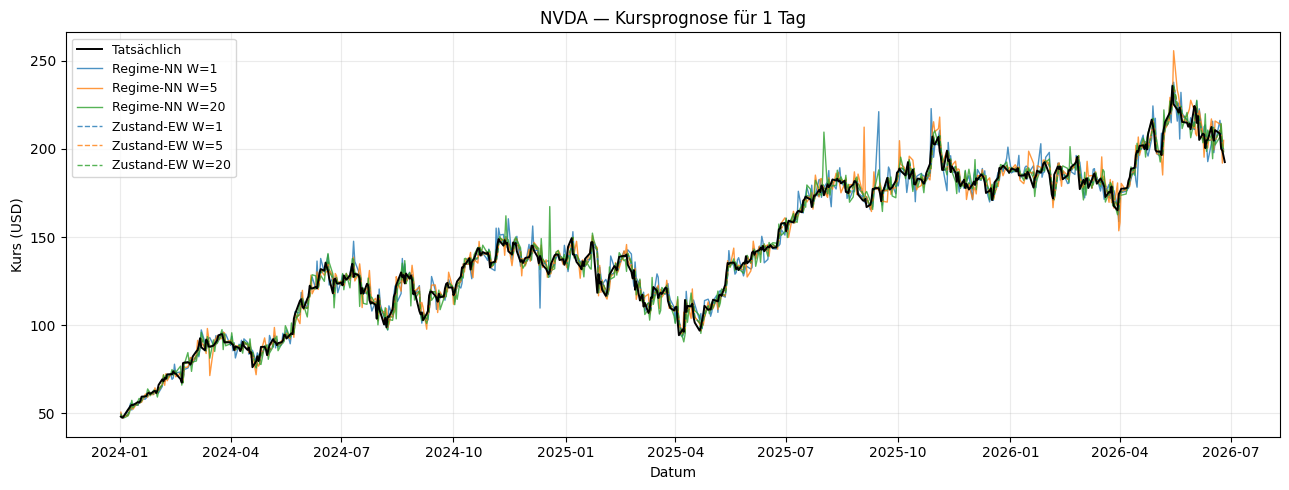

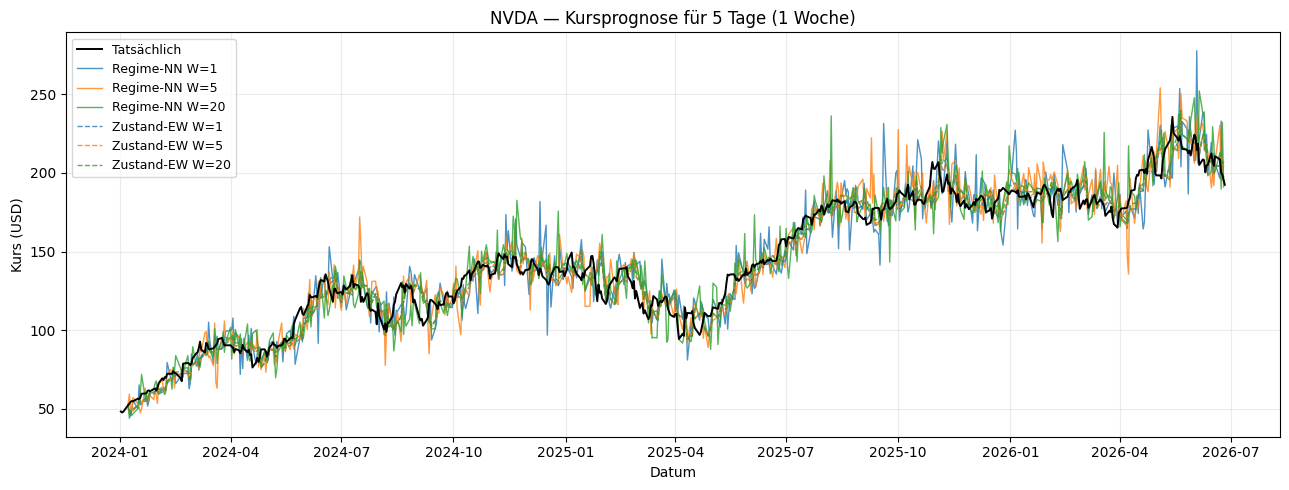

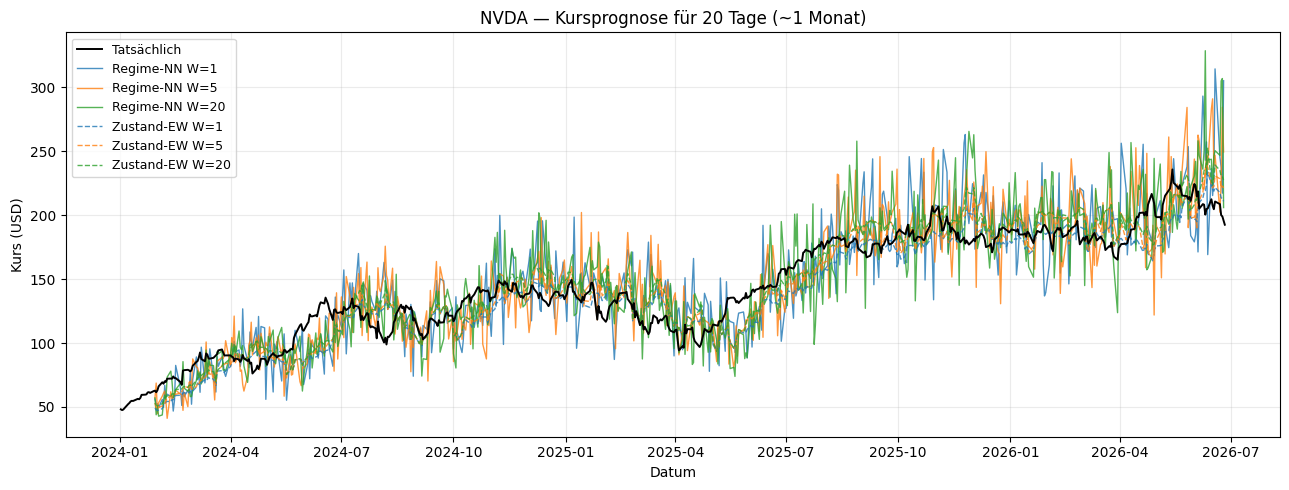

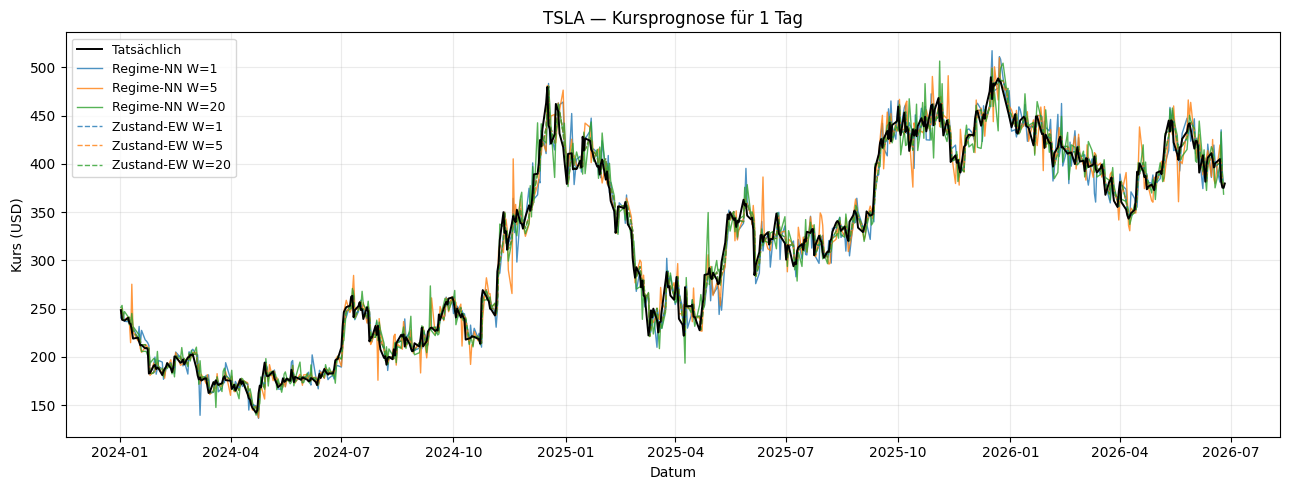

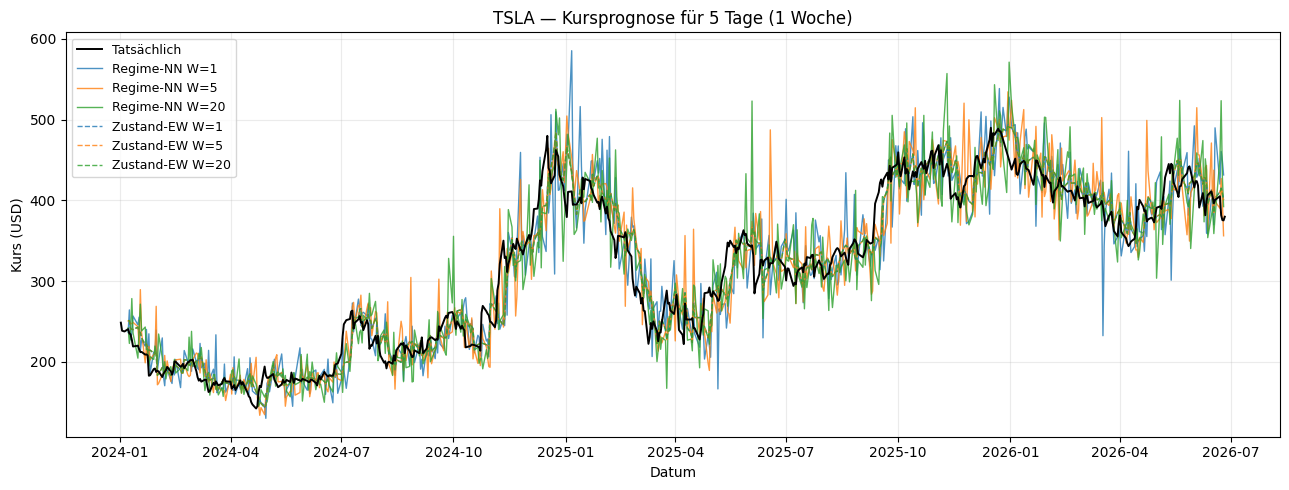

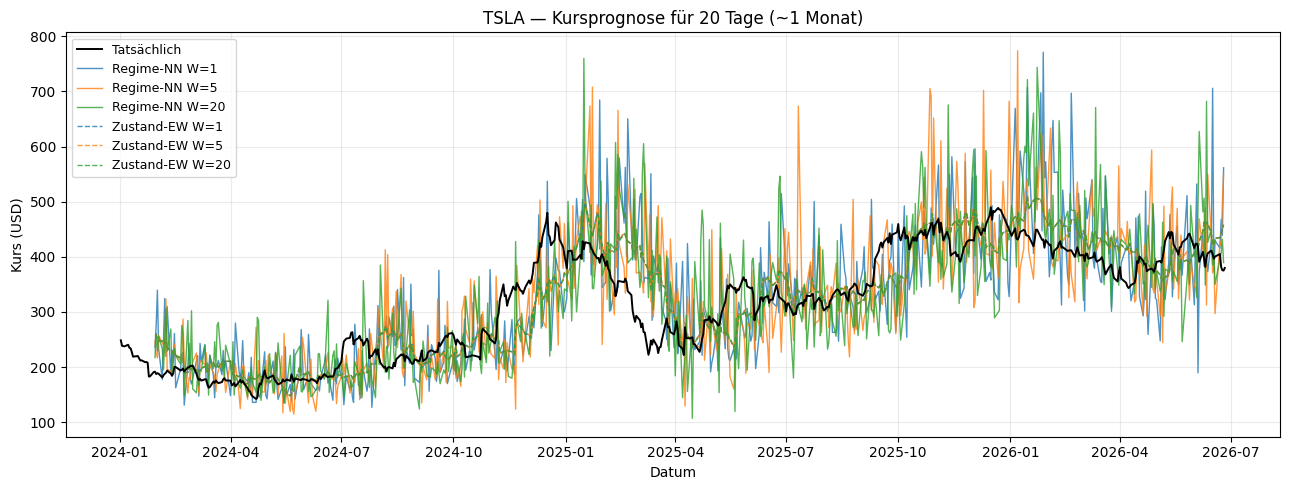

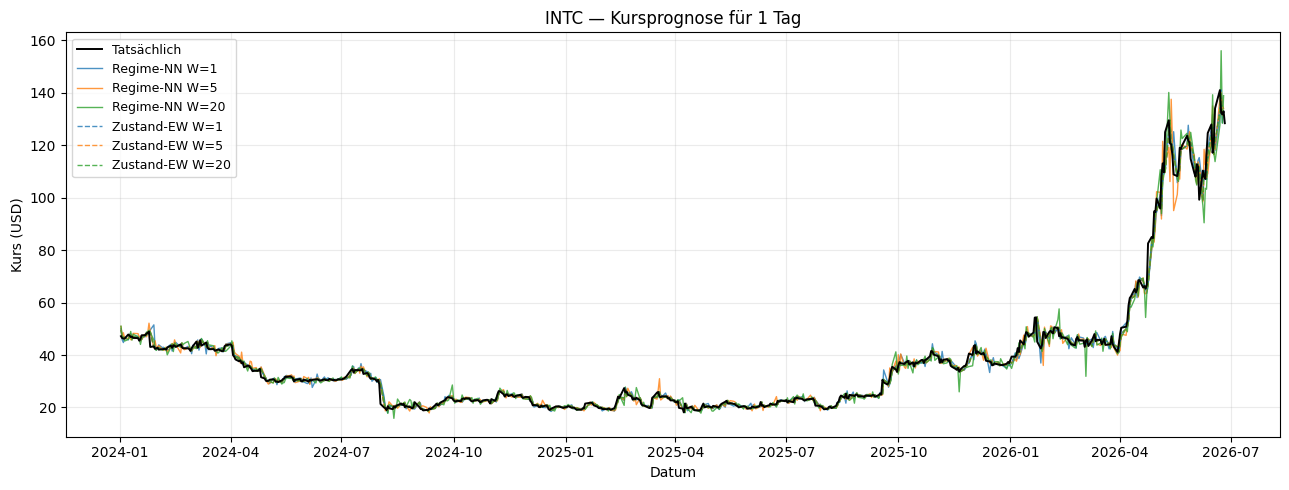

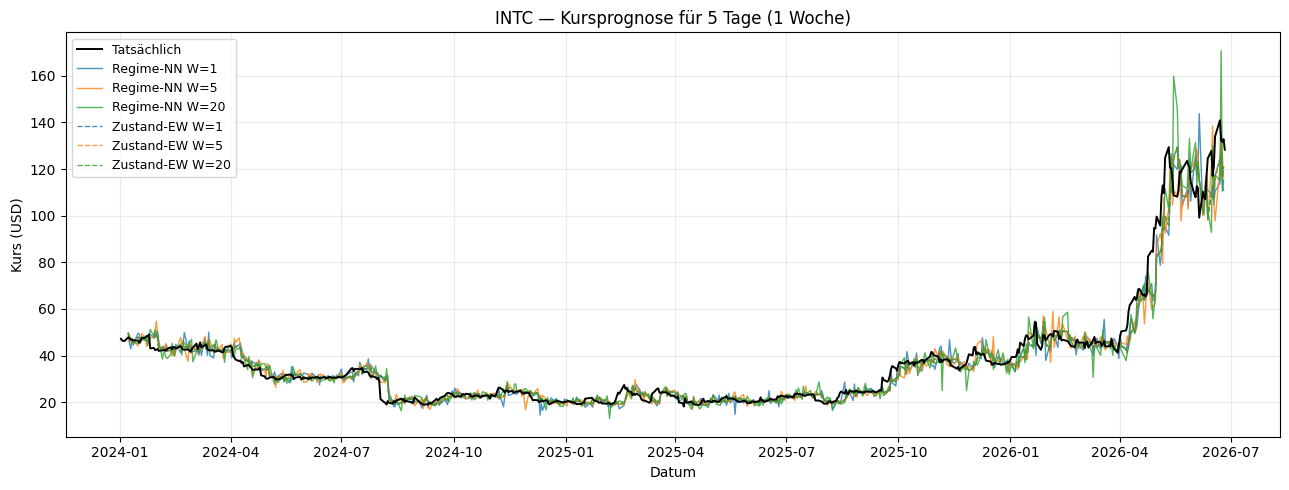

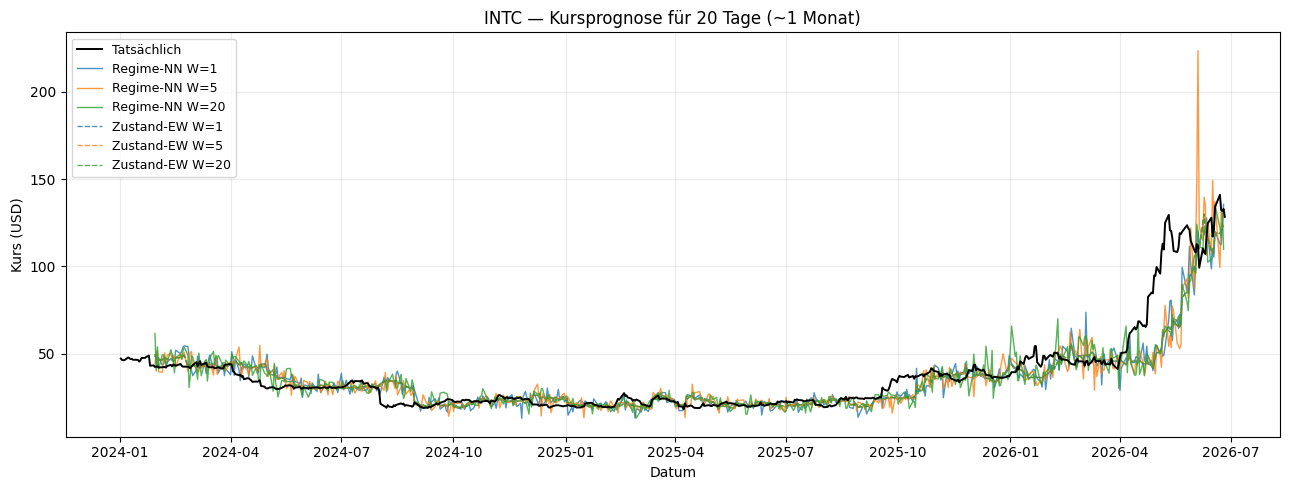

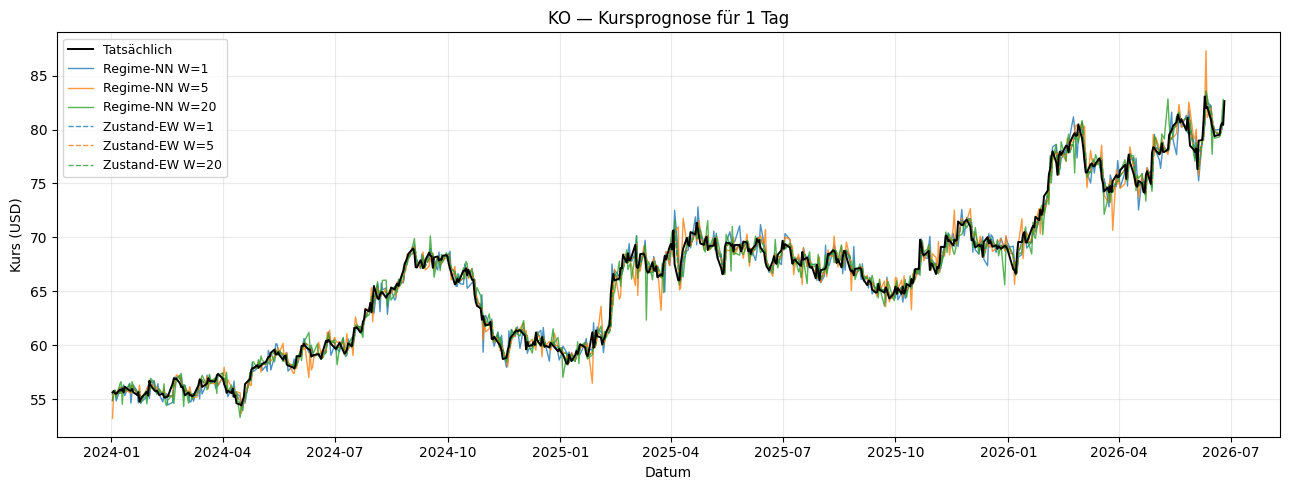

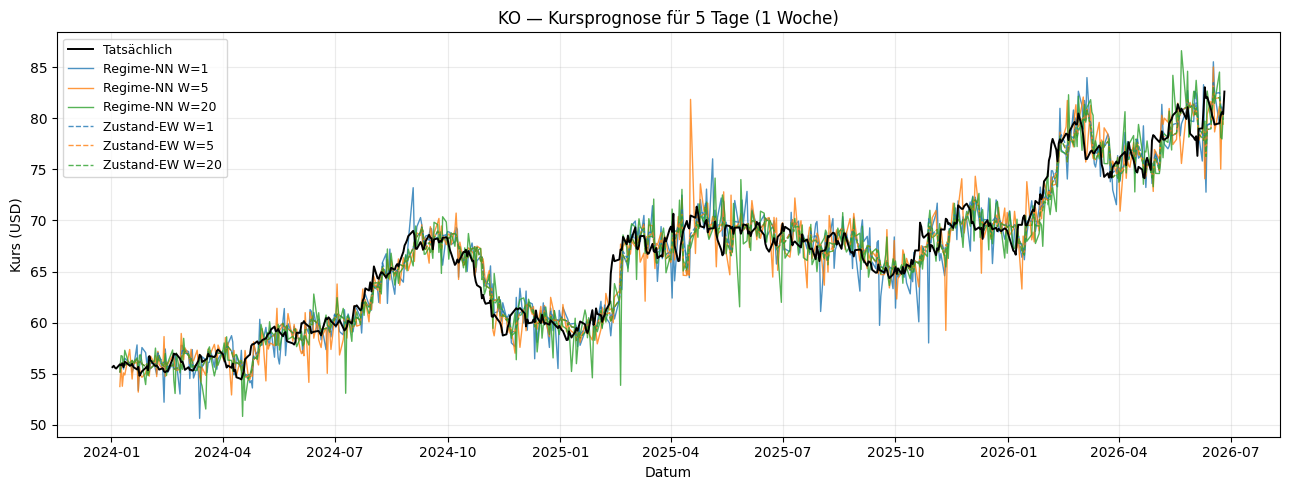

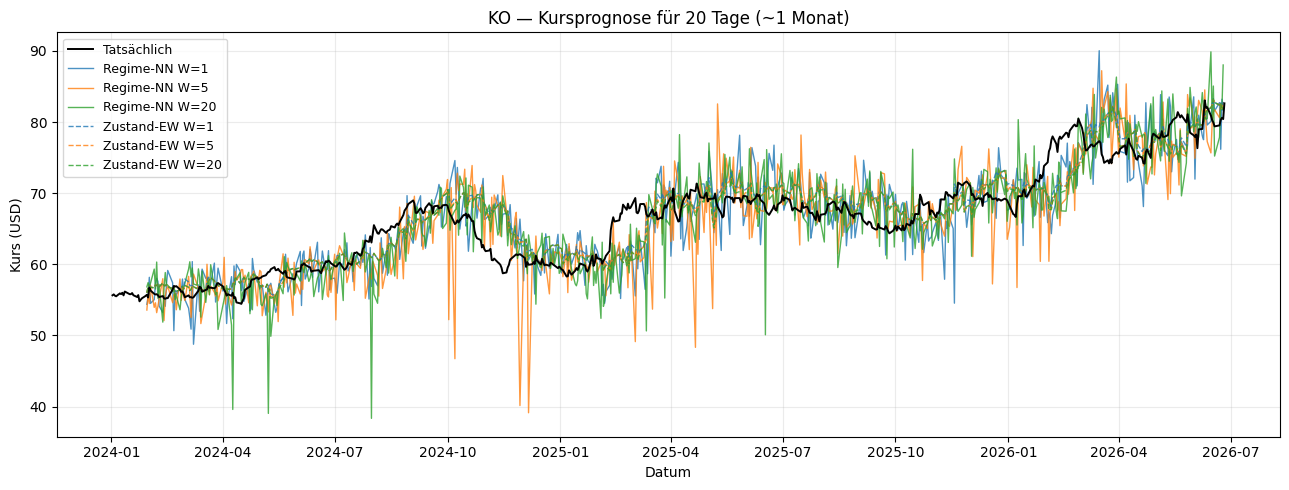

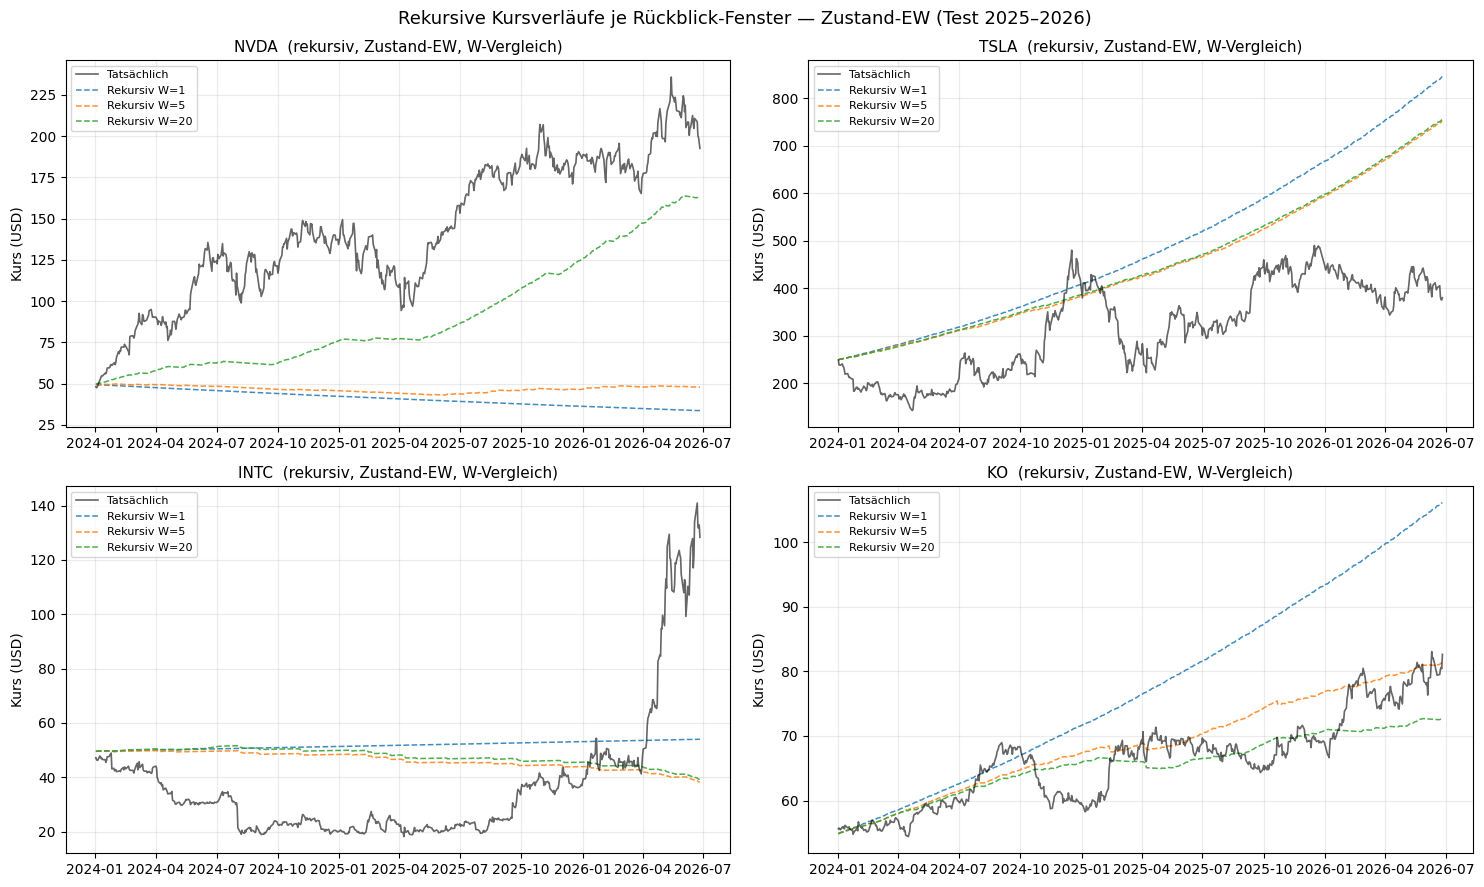

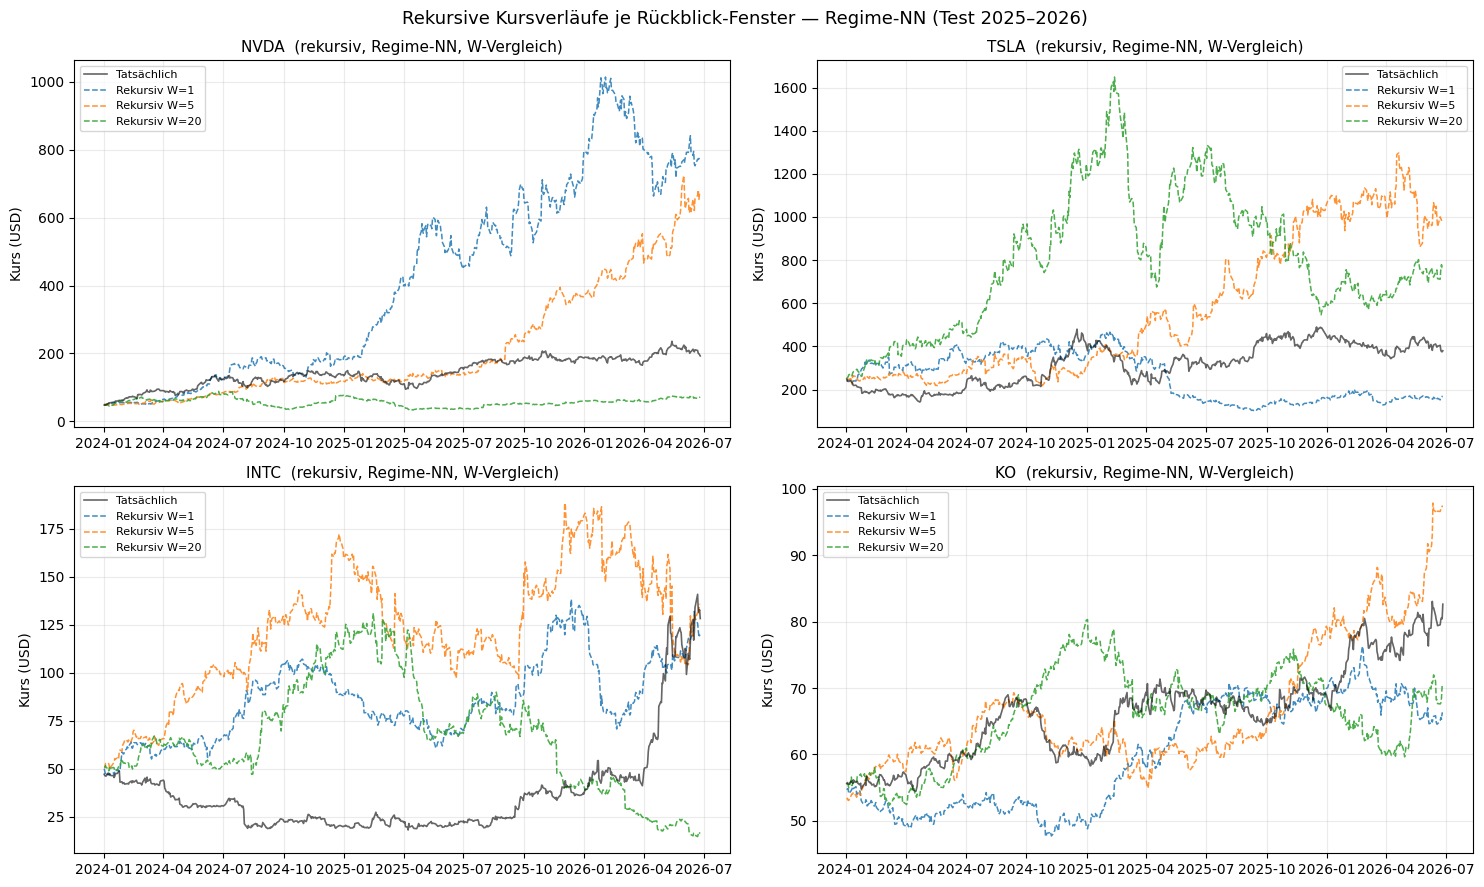

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Konfig (von mehreren Blöcken genutzt)
COLORS_W = {1: "#1f77b4", 5: "#ff7f0e", 20: "#2ca02c"}
COLOR_M  = {"M1": "#1f77b4", "M2": "#d62728"}
METHODS  = [("M1", "Regime-NN"), ("M2", "Zustand-EW")]


def directional_accuracy(preds, actuals):
    valid = ~np.isnan(preds)
    if valid.sum() == 0:
        return np.nan
    return (np.sign(preds[valid]) == np.sign(actuals[valid])).mean() * 100


# ── 1. Kennzahlen-Tabellen mit Summenspalte + Hervorhebung der besten Zeile ──────────
METHOD_KEYS = [f"{'M1' if m == 0 else 'M2'}_W{W}_H{H}"
               for m in range(2) for W in WINDOW_SIZES for H in HORIZONS]
VARIANT_LABELS = {
    key: f"{'Regime-NN ' if key[:2] == 'M1' else 'Zustand-EW'} "
         f"W={W:2d} H={H:2d}"
    for m in range(2) for W in WINDOW_SIZES for H in HORIZONS
    for key in [f"{'M1' if m == 0 else 'M2'}_W{W}_H{H}"]
}


def metric_table(metric_fn):
    rows = {VARIANT_LABELS[key]: [metric_fn(*all_forecasts[t][key]) for t in TICKERS]
            for key in METHOD_KEYS}
    df = pd.DataFrame.from_dict(rows, orient="index", columns=TICKERS)
    df["Durchschnitt"] = df[TICKERS].mean(axis=1)   # Zeilendurchschnitt über alle Ticker
    return df


def show_table(title, df, best, fmt):
    """Zeigt die Tabelle mit grün hervorgehobener bester Zeile (nach 'Durchschnitt')."""
    best_idx = df["Durchschnitt"].idxmax() if best == "max" else df["Durchschnitt"].idxmin()
    styler = (df.style
                .format(fmt)
                .apply(lambda row: ["background-color: #b7e1a1" if row.name == best_idx
                                    else "" for _ in row], axis=1)
                .set_caption(title))
    display(styler)


show_table("Directional Accuracy (%) — beste Zeile grün (höchste Summe)",
           metric_table(directional_accuracy), best="max", fmt="{:.1f}")


# ── 2. Kurs-Charts je Ticker & Horizont: IST vs. beste Prognose (re-anchored) ──────────
# Getrennte, große Charts (12 = 4 Ticker × 3 Horizonte). Prognosekurs = IST-Kurs am
# Horizontstart × exp(kumulierte prognostizierte H-Rendite), aufgetragen am ZIELdatum
# (Origin t -> Ziel t+H-1). Je Methode das nach Directional Accuracy beste Rückblickfenster.
HORIZON_LABEL = {1: "1 Tag", 5: "5 Tage (1 Woche)", 20: "20 Tage (~1 Monat)"}
METHOD_LS  = {"M1": "-", "M2": "--"}   # Methode über Linienstil, Fenster über Farbe (COLORS_W)


for ticker in TICKERS:
    dates    = dates_test[ticker]
    p_actual = prices_test[ticker]
    origin   = np.concatenate([[price_anchor[ticker]], p_actual[:-1]])  # Kurs vor Tag t
    for H in HORIZONS:
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(dates, p_actual, color="black", linewidth=1.4,
                label="Tatsächlich", zorder=5)
        # Einheitlich: jedes Chart zeigt IST + beide Methoden × alle Fenster (W=1/5/20).
        for m, mlabel in METHODS:
            for W in WINDOW_SIZES:
                preds = all_forecasts[ticker][f"{m}_W{W}_H{H}"][0]
                fc    = origin * np.exp(preds / 100.0)        # Zielkurs für Tag t+H-1
                idx   = np.where(~np.isnan(preds))[0]
                ax.plot(dates[idx + (H - 1)], fc[idx], color=COLORS_W[W], linewidth=1.0,
                        linestyle=METHOD_LS[m], alpha=0.8,
                        label=f"{mlabel} W={W}")
        ax.set_title(f"{ticker} — Kursprognose für {HORIZON_LABEL[H]}", fontsize=12)
        ax.set_ylabel("Kurs (USD)")
        ax.set_xlabel("Datum")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=9, loc="best")
        fig.tight_layout()
        plt.show()


# ── 3. Rekursive Kursverläufe je Rückblick-Fenster (W=1/5/20) — je Methode, Feld pro Aktie ──
# Start am price_anchor, dann fortlaufend mit den Prognose-Returns aufmultiplizieren
# (Kurs baut auf dem vorherigen PROGNOSE-Kurs auf, kein Reset auf die Wahrheit -> Fehler
# akkumulieren). Log-Returns sind additiv => cumsum, dann exp. Einmal für M2, einmal für M1.
for rec_m, rec_label in [("M2", "Zustand-EW"), ("M1", "Regime-NN")]:
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    for ax, ticker in zip(axes.flat, TICKERS):
        dates  = dates_test[ticker]
        anchor = price_anchor[ticker]

        ax.plot(dates, prices_test[ticker], color="black", linewidth=1.2, alpha=0.6,
                label="Tatsächlich", zorder=5)
        for W in WINDOW_SIZES:
            pred_ret = np.nan_to_num(all_forecasts[ticker][f"{rec_m}_W{W}_H1"][0], nan=0.0)
            p_rec    = anchor * np.exp(np.cumsum(pred_ret) / 100.0)
            ax.plot(dates, p_rec, color=COLORS_W[W], linewidth=1.1, linestyle="--",
                    alpha=0.85, label=f"Rekursiv W={W}")

        ax.set_title(f"{ticker}  (rekursiv, {rec_label}, W-Vergleich)", fontsize=11)
        ax.set_ylabel("Kurs (USD)")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="best")

    fig.suptitle(f"Rekursive Kursverläufe je Rückblick-Fenster — {rec_label} (Test 2025–2026)",
                 fontsize=13)
    fig.tight_layout()
    plt.show()


# Student-t-HMM via pomegranate (ν=4) — Bibliotheks-Variante

Dasselbe Student-t-Forecast-Modell, aber mit **pomegranate** (`DenseHMM` + `StudentT`) statt der eigenen scipy/NumPy-Klasse. Ein dünner Adapter (`StudentTHMMPom`) stellt dieselbe Schnittstelle bereit (`means_`, `transmat_`, `startprob_`, `score`, `score_samples`), sodass Forecast/Eval/Scatter unverändert laufen. Gleiche Daten, gleiche σ-Schwellen-Init, N=3, ν=4. Objekte: `fitted_models_tp` / `all_forecasts_tp` (Gauß- und Eigenbau-t-Ergebnisse bleiben erhalten → Implementierungsvergleich). Hinweis: Für Fenster W=1 liefert pomegranate `nan`/Fehler (Sequenzlänge 1); dieser Grenzfall wird geschlossen über die Student-t-Dichte berechnet.

In [18]:
import numpy as np
import torch
import warnings
from scipy.stats import t as student_t
from scipy.special import logsumexp
from pomegranate.hmm import DenseHMM
from pomegranate.distributions import StudentT

NU_FIXED_POM = 4   # feste Freiheitsgrade (pomegranate aktualisiert dofs nicht)


class StudentTHMMPom:
    """Student-t-HMM via pomegranate (DenseHMM + StudentT) mit hmmlearn-artiger
    Schnittstelle (means_, transmat_, startprob_, covars_, score, score_samples),
    damit Forecast-/Eval-/Scatter-Zellen unverändert wiederverwendbar sind."""

    def __init__(self, n_states, nu=NU_FIXED_POM, max_iter=300, tol=1e-4): #Initialisierung
        self.n_states = n_states
        self.nu = nu
        self.max_iter = max_iter
        self.tol = tol
        self.model = None

    @staticmethod
    def _seq(X): #Eingabedaten müssen für pomegranate transformiert werden
        return torch.tensor(np.asarray(X, dtype=np.float32).reshape(1, -1, 1))

    def fit(self, X, init): #Training mittels Baum-Welch
        N = self.n_states
        mu  = np.asarray(init["mu"], dtype=np.float32) #MW Returns
        var = np.asarray(init["sigma"], dtype=np.float32) ** 2         # Scale^2 aus σ-Schwellen
        dists = [StudentT(means=[mu[j]], covs=[var[j]], dofs=self.nu, #t-Verteilung pro Zustand
                          covariance_type="diag") for j in range(N)]
        edges  = torch.tensor(np.asarray(init["A"], dtype=np.float32))  # Startübergänge (Wahrsch.)
        starts = torch.tensor(np.asarray(init["pi"], dtype=np.float32)) # Startverteilung (Wahrsch.)
        self.model = DenseHMM(dists, edges=edges, starts=starts, #HMM init.
                              max_iter=self.max_iter, tol=self.tol, verbose=False)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.model.fit(self._seq(X)) #Baum-Welch fitting
        return self

    # ── hmmlearn-kompatible Attribute ────────────────────────────────────────
    @property
    def means_(self):
        return np.array([np.asarray(d.means.detach()).ravel()[0]
                         for d in self.model.distributions]).reshape(-1, 1)

    @property
    def covars_(self):
        return np.array([np.asarray(d.covs.detach()).ravel()[0]
                         for d in self.model.distributions]).reshape(-1, 1)

    @property
    def transmat_(self):
        A = np.exp(np.asarray(self.model.edges.detach()))
        return A / A.sum(axis=1, keepdims=True)

    @property
    def startprob_(self):
        p = np.exp(np.asarray(self.model.starts.detach()))
        return p / p.sum()

    # ── Schnittstelle für M1 (score) und M2 (score_samples) ──────────────────
    # Sonderfall Länge 1 (Fenster W=1): pomegranate liefert dort nan bzw. crasht
    # (forward_backward mit l-1=0). Für T=1 ist die Sequenz-LL geschlossen:
    #   γ ∝ π · Student-t-Dichte(x),  LL = logsumexp(log π + log-Emission).
    def _len1_logstate(self, x):
        mu    = self.means_.ravel()
        scale = np.sqrt(np.maximum(self.covars_.ravel(), 1e-12))
        log_emis = student_t.logpdf(x, df=self.nu, loc=mu, scale=scale)   # (N,)
        return np.log(np.maximum(self.startprob_, 1e-300)) + log_emis     # (N,)

    def score(self, X):
        a = np.asarray(X, dtype=float).ravel()
        if len(a) == 1:
            return float(logsumexp(self._len1_logstate(a[0])))
        return float(np.asarray(self.model.log_probability(self._seq(X)))[0])

    def score_samples(self, X):
        """Wie hmmlearn: (log_likelihood, posteriors γ)."""
        a = np.asarray(X, dtype=float).ravel()
        if len(a) == 1:
            v = self._len1_logstate(a[0])
            lp = logsumexp(v)
            return float(lp), np.exp(v - lp).reshape(1, -1)
        Xt = self._seq(X)
        lp = float(np.asarray(self.model.log_probability(Xt))[0])
        gamma = np.asarray(self.model.predict_proba(Xt))[0]   # (T, N)
        return lp, gamma


# ── Fit je Ticker (ν=4, σ-Schwellen-Init aus Zelle 20) ───────────────────────
fitted_models_tp = {}
state_names = ["Bear", "Normal", "Bull"]

for ticker in TICKERS:
    p       = init_params[ticker] #ziehe pro Ticker die errechneten Startwerte
    X_train = data_train[ticker]

    model = StudentTHMMPom(n_states=N_STATES, nu=NU_FIXED_POM, max_iter=300, tol=1e-4) #Modell aufstellen
    model.fit(X_train, init=p) #Modell mit B-W traninieren
    fitted_models_tp[ticker] = model #Modelle als Datensatz speichern

    mu_fit    = model.means_.flatten() #Transformieren
    sigma_fit = np.sqrt(model.covars_.flatten())
    order     = np.argsort(mu_fit)

#------Prints nach Training-----
    print(f"\n=== {ticker} — Student-t via pomegranate (ν={NU_FIXED_POM}) ===")
    print(f"  LL(Training) = {model.score(X_train):.1f}")
    for rank, idx in enumerate(order):
        print(f"  {state_names[rank]:<6} (Zustand {idx}): "
              f"μ = {mu_fit[idx]:+.4f}%   σ = {sigma_fit[idx]:.4f}%   ν = {NU_FIXED_POM}")
    print("  Übergangsmatrix A (nach Fit):")
    for i in range(N_STATES):
        print("    " + "  ".join(f"{model.transmat_[i, j]:.4f}" for j in range(N_STATES)))



=== NVDA — Student-t via pomegranate (ν=4) ===
  LL(Training) = -4987.7
  Bear   (Zustand 0): μ = -4.3410%   σ = 3.2008%   ν = 4
  Normal (Zustand 1): μ = +0.2893%   σ = 2.0203%   ν = 4
  Bull   (Zustand 2): μ = +4.5783%   σ = 3.6349%   ν = 4
  Übergangsmatrix A (nach Fit):
    0.1582  0.6160  0.2257
    0.0934  0.8293  0.0773
    0.1543  0.7480  0.0978

=== TSLA — Student-t via pomegranate (ν=4) ===
  LL(Training) = -5323.3
  Bear   (Zustand 0): μ = -5.5421%   σ = 4.1909%   ν = 4
  Normal (Zustand 1): μ = +0.1373%   σ = 2.3880%   ν = 4
  Bull   (Zustand 2): μ = +5.7071%   σ = 3.8495%   ν = 4
  Übergangsmatrix A (nach Fit):
    0.1312  0.7109  0.1579
    0.0850  0.8375  0.0775
    0.0992  0.7372  0.1635

=== INTC — Student-t via pomegranate (ν=4) ===
  LL(Training) = -4176.2
  Bear   (Zustand 0): μ = -3.1730%   σ = 3.2201%   ν = 4
  Normal (Zustand 1): μ = +0.0696%   σ = 1.3931%   ν = 4
  Bull   (Zustand 2): μ = +3.1416%   σ = 2.6952%   ν = 4
  Übergangsmatrix A (nach Fit):
    0.1470

### t-Forecast (pomegranate) — M1 (Nguyen) + M2

In [19]:
import numpy as np

WINDOW_SIZES = [1, 5, 20]   # Rückblick-Fenster: 1 Tag, 1 Woche, ~1 Monat
HORIZONS     = [1, 5, 20]   # Prognose voraus: 1 Tag, 1 Woche, ~1 Monat
# Hinweis: Für H=20 wird Methode 2 nahezu konstant — die Zustandsverteilung A^k·γ
# konvergiert über 20 Schritte gegen den stationären Zustand. Bewusst so (Befund).


def regime_posterior(model, window): #s. oben bei Gauss-> Zustandsverteilung
    """P(Zustand | Fenster) am letzten Tag des Fensters (Forward-Backward). Für M2."""
    _, posterior = model.score_samples(window.reshape(-1, 1))
    return posterior[-1]


def window_loglik(model, seq):  #Likelihood der Sequenz von Returns
    """Skalare Log-Likelihood einer Beobachtungssequenz (Nguyen-2017-Musterabgleich, M1)."""
    return model.score(seq.reshape(-1, 1))


def expected_return(model, gamma, H): #prognostiziere die Rendite mit der neuen Methode
    mu_states = model.means_.flatten()
    A         = model.transmat_
    dist, total = gamma.copy(), 0.0
    for _ in range(H):
        dist   = A.T @ dist          # einen Tag weiter
        most_likely_state = np.argmax(dist) #bestimme den wahrscheinlichsten Zustand
        total += mu_states[most_likely_state]    # addiere erwarteter Return dieses Tages
    return float(total)

# ── Haupt-Forecast-Loop ──────────────────────────────────────────────────────
all_forecasts_tp = {}

for ticker in TICKERS: #Pro Ticker Modelle ziehen
    model   = fitted_models_tp[ticker]
    X_train = data_train[ticker].flatten()
    X_test  = data_test[ticker].flatten()
    X_all   = np.concatenate([X_train, X_test])
    T_train, T_test = len(X_train), len(X_test)

    results = {}
    for W in WINDOW_SIZES:
        print(f"  {ticker}  W={W:2d} ...", flush=True)  # Was analysiert die Methode gerade

        # Berechne zum Zeit sparen vorher schon alle Likelihoods für den Gesamtdatensatz (X_all).
        # Verwendet werden später in jedem Zeitschritt t implizit nur die historisch bekannten.
        total_windows = len(X_all) - W + 1
        all_ll = np.array([
            window_loglik(model, X_all[s: s + W])
            for s in range(total_windows)
        ])

        # M2: Gefensterte Zustandsverteilung je Testtag (einmal berechnet, für alle H wiederverwendet)
        gammas = np.array([
            regime_posterior(model, X_all[T_train + t - W: T_train + t])
            for t in range(T_test)
        ])  # Shape (T_test, N)

        for H in HORIZONS:
            m1_preds = np.full(T_test, np.nan)  # Für die Vorhersagen leere Arrays erzeugen
            m2_preds = np.full(T_test, np.nan)
            actuals  = np.full(T_test, np.nan)

            for t in range(T_test - H):
                # Absoluter Zeit-Index im Gesamtdatensatz X_all für den aktuellen Testtag t
                current_idx_all = T_train + t

                # ──────────────────────────────────────────────────────────────────
                # METHODE 1 (Nguyen, neu): Analogsuche erweitert "bis heute"
                # ──────────────────────────────────────────────────────────────────
                L_test_t = all_ll[current_idx_all - W]          # Bestimme die Likelihood von heute
                max_search_start = current_idx_all - W - H      # Wir können zeitlich bis (heute - H) suchen
                cand_ll = all_ll[:max_search_start + 1]         # Dynamischer Suchraum im all_ll-Index

                s = int(np.argmin(np.abs(cand_ll - L_test_t)))  # Engste Likelihood in der Historie finden
                m1_preds[t] = X_all[s + W: s + W + H].sum()     # Kumulierte Rendite aus dem Analogfenster bestimmen

                # ──────────────────────────────────────────────────────────────────
                # METHODE 2 (MAP-Regimeprognose): Überarbeitete Logik
                # ──────────────────────────────────────────────────────────────────
                # Nutzt die neue MAP-Logik (_expected_return_map) anstelle des gewichteten Erwartungswerts
                m2_preds[t] = expected_return(model, gammas[t], H)

                # Tatsächlicher (kumulierter) Return aus der Testphase zum Vergleich
                actuals[t]  = X_test[t: t + H].sum()

            # Forecasts und Realität in ein Tuple für beide Methoden packen
            results[f"M1_W{W}_H{H}"] = (m1_preds, actuals)
            results[f"M2_W{W}_H{H}"] = (m2_preds, actuals)

    # Speichern der Ergebnisse für den aktuellen Ticker
        all_forecasts_tp[ticker] = results


print("\nForecast abgeschlossen.")


  NVDA  W= 1 ...
  NVDA  W= 5 ...
  NVDA  W=20 ...
  TSLA  W= 1 ...
  TSLA  W= 5 ...
  TSLA  W=20 ...
  INTC  W= 1 ...
  INTC  W= 5 ...
  INTC  W=20 ...
  KO  W= 1 ...
  KO  W= 5 ...
  KO  W=20 ...

Forecast abgeschlossen.


### t-Auswertung (pomegranate) — Tabellen + Charts

,NVDA,TSLA,INTC,KO,Summe,Durchschnitt
Regime-NN W= 1 H= 1,48.4,52.7,49.2,46.0,196.3,49.1
Regime-NN W= 1 H= 5,52.4,51.1,48.4,45.5,197.4,49.4
Regime-NN W= 1 H=20,55.2,52.7,45.9,49.4,203.3,50.8
Regime-NN W= 5 H= 1,56.8,45.3,50.3,48.1,200.5,50.1
Regime-NN W= 5 H= 5,50.8,47.9,47.4,50.8,196.9,49.2
Regime-NN W= 5 H=20,53.1,50.6,49.3,53.1,206.0,51.5
Regime-NN W=20 H= 1,51.3,49.8,49.4,52.4,202.9,50.7
Regime-NN W=20 H= 5,52.4,49.5,49.2,48.9,200.0,50.0
Regime-NN W=20 H=20,56.1,52.9,46.3,49.8,205.0,51.2
Zustand-EW W= 1 H= 1,54.0,50.5,49.2,51.1,204.8,51.2


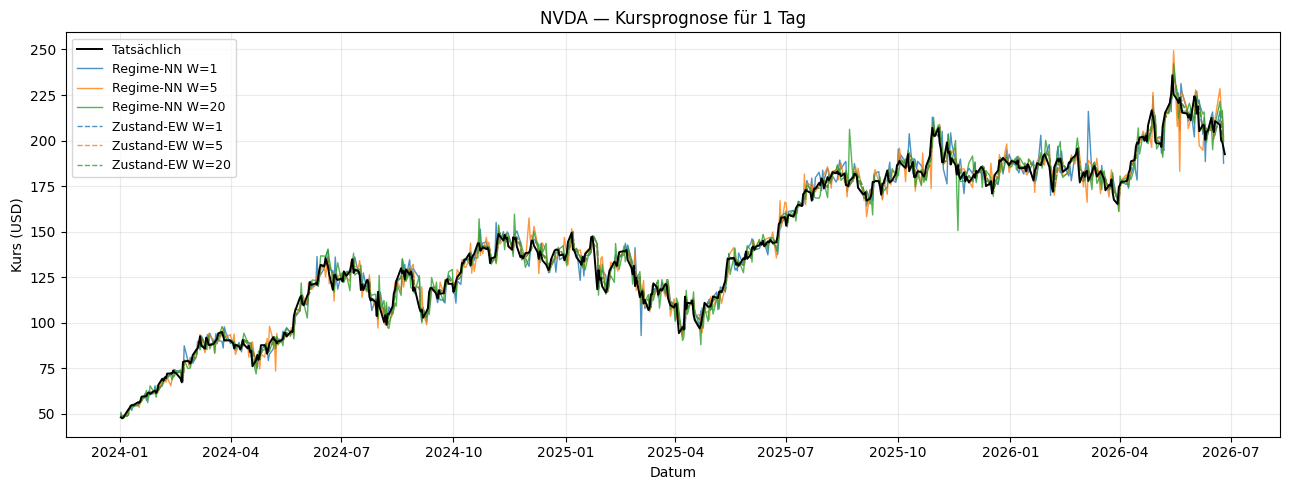

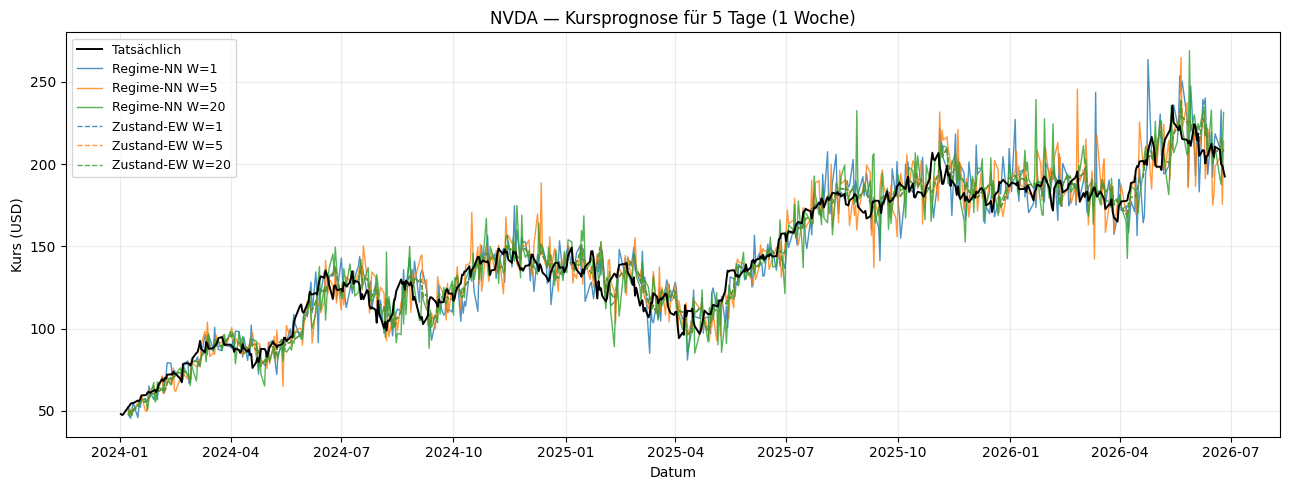

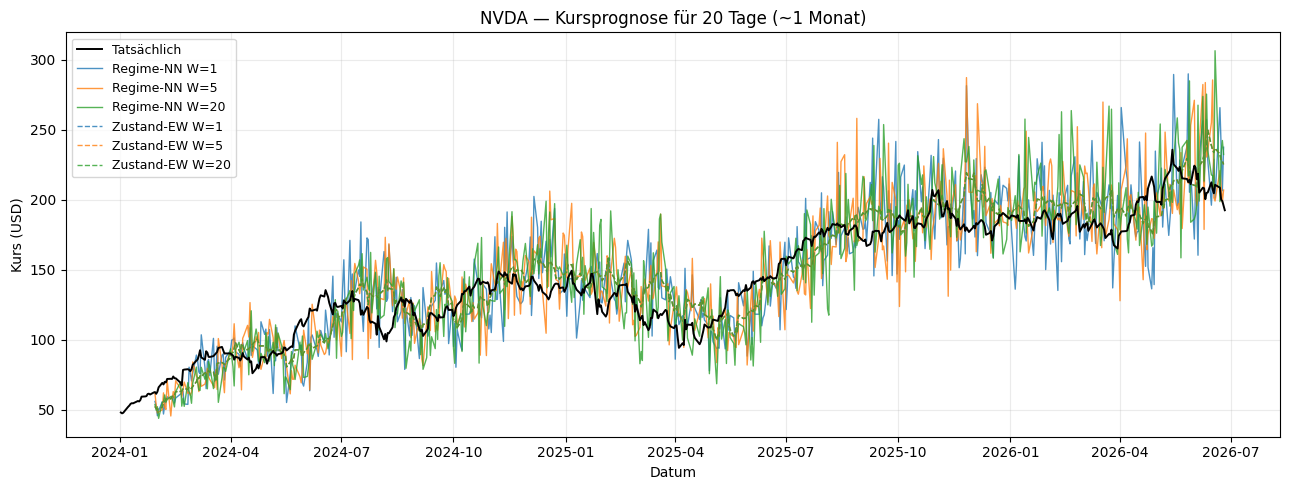

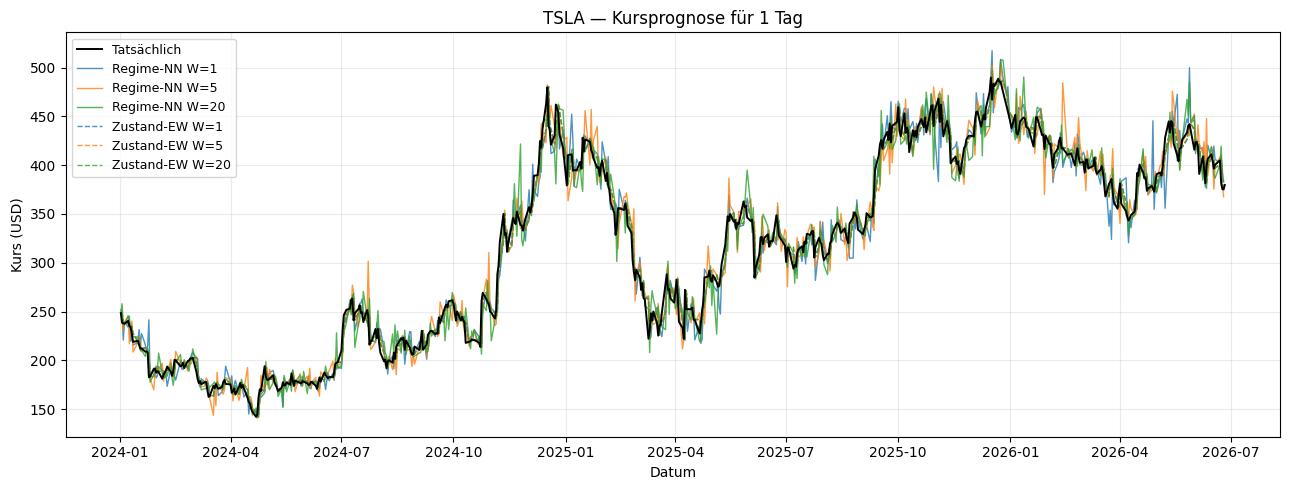

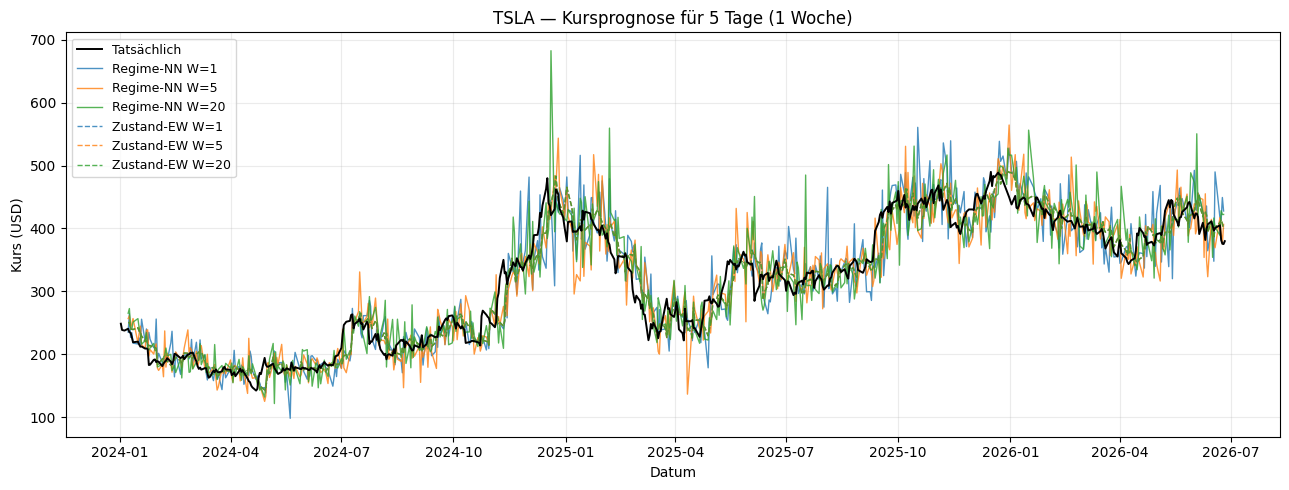

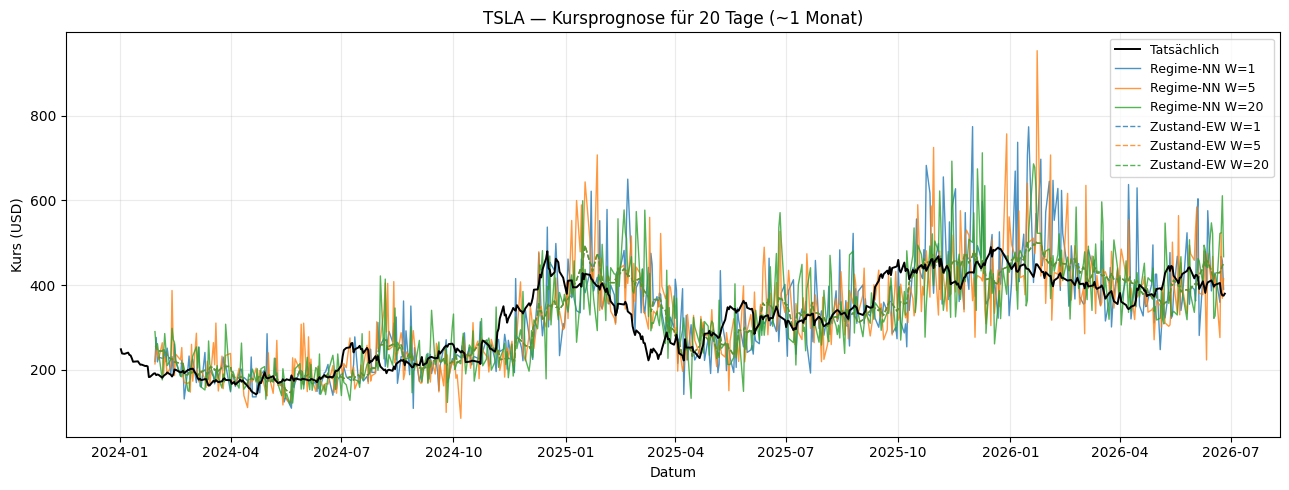

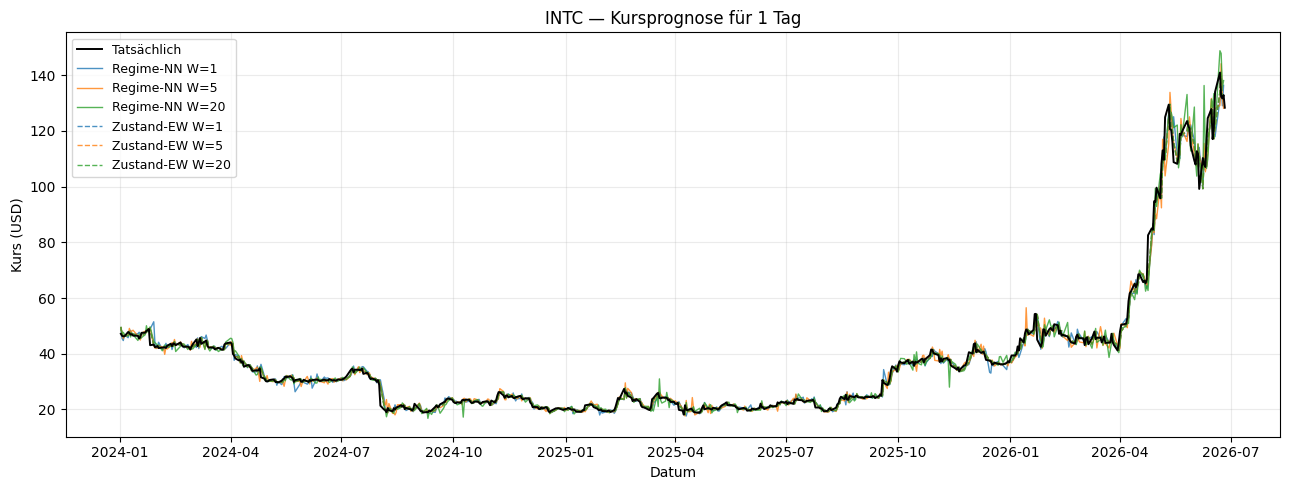

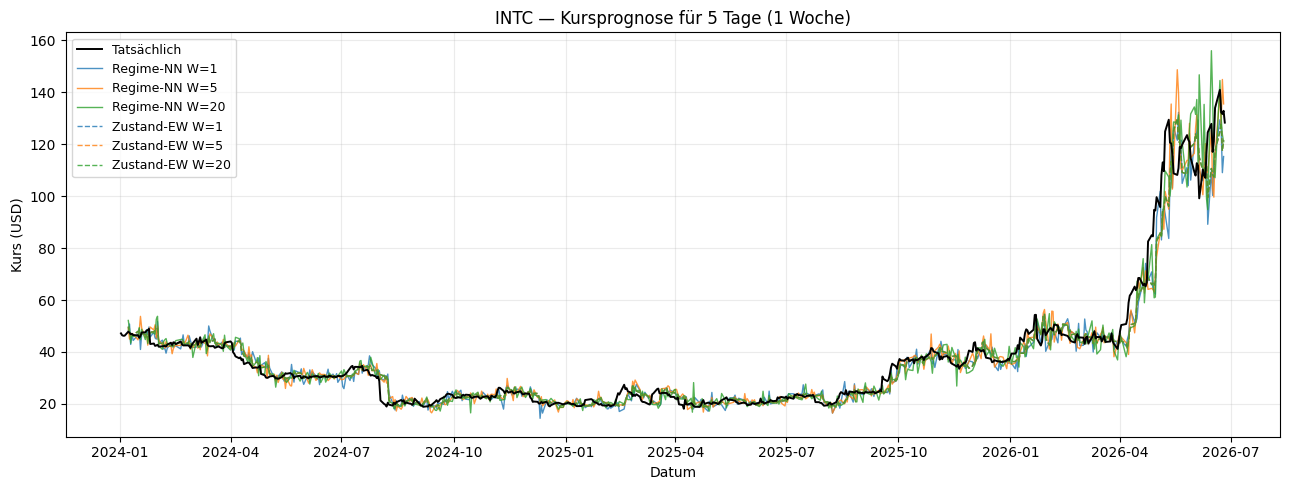

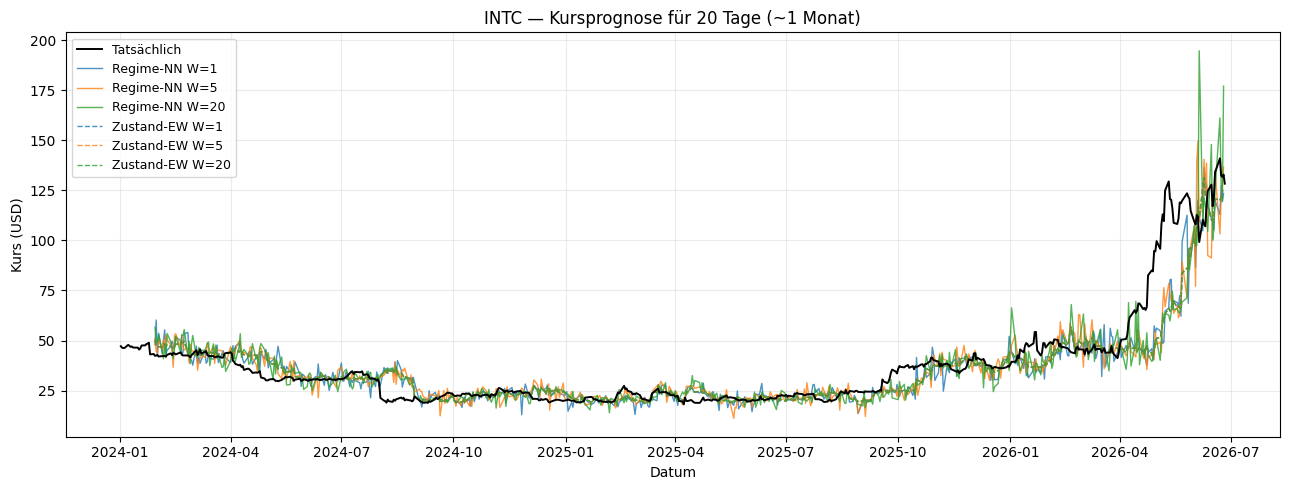

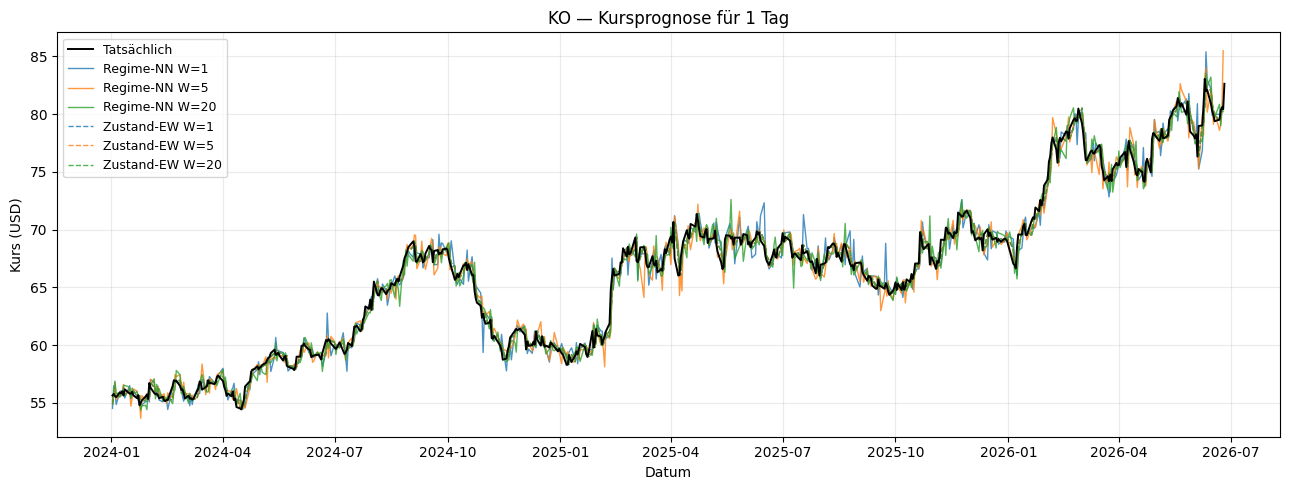

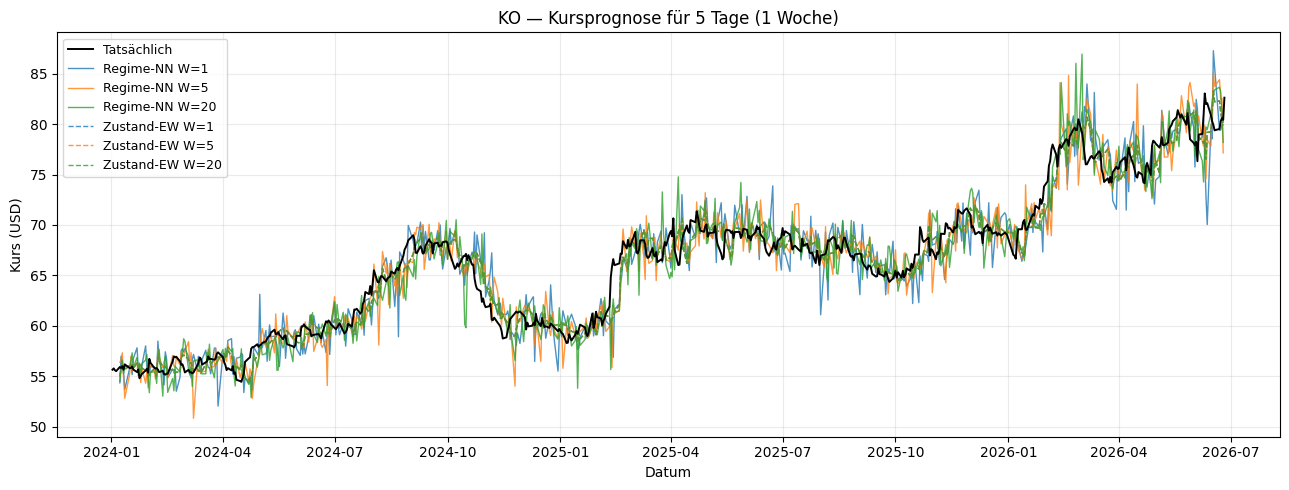

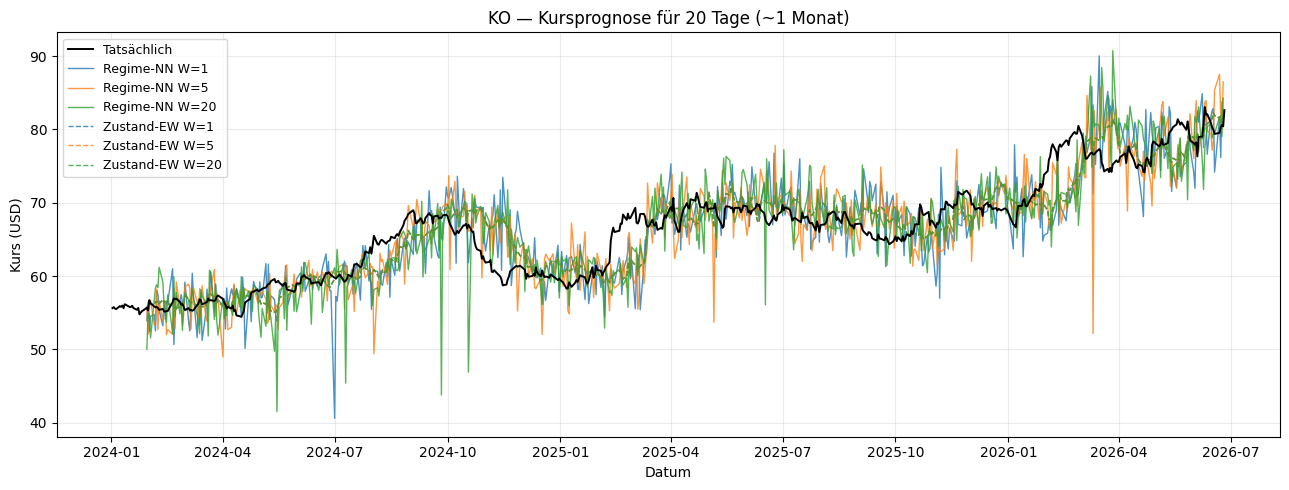

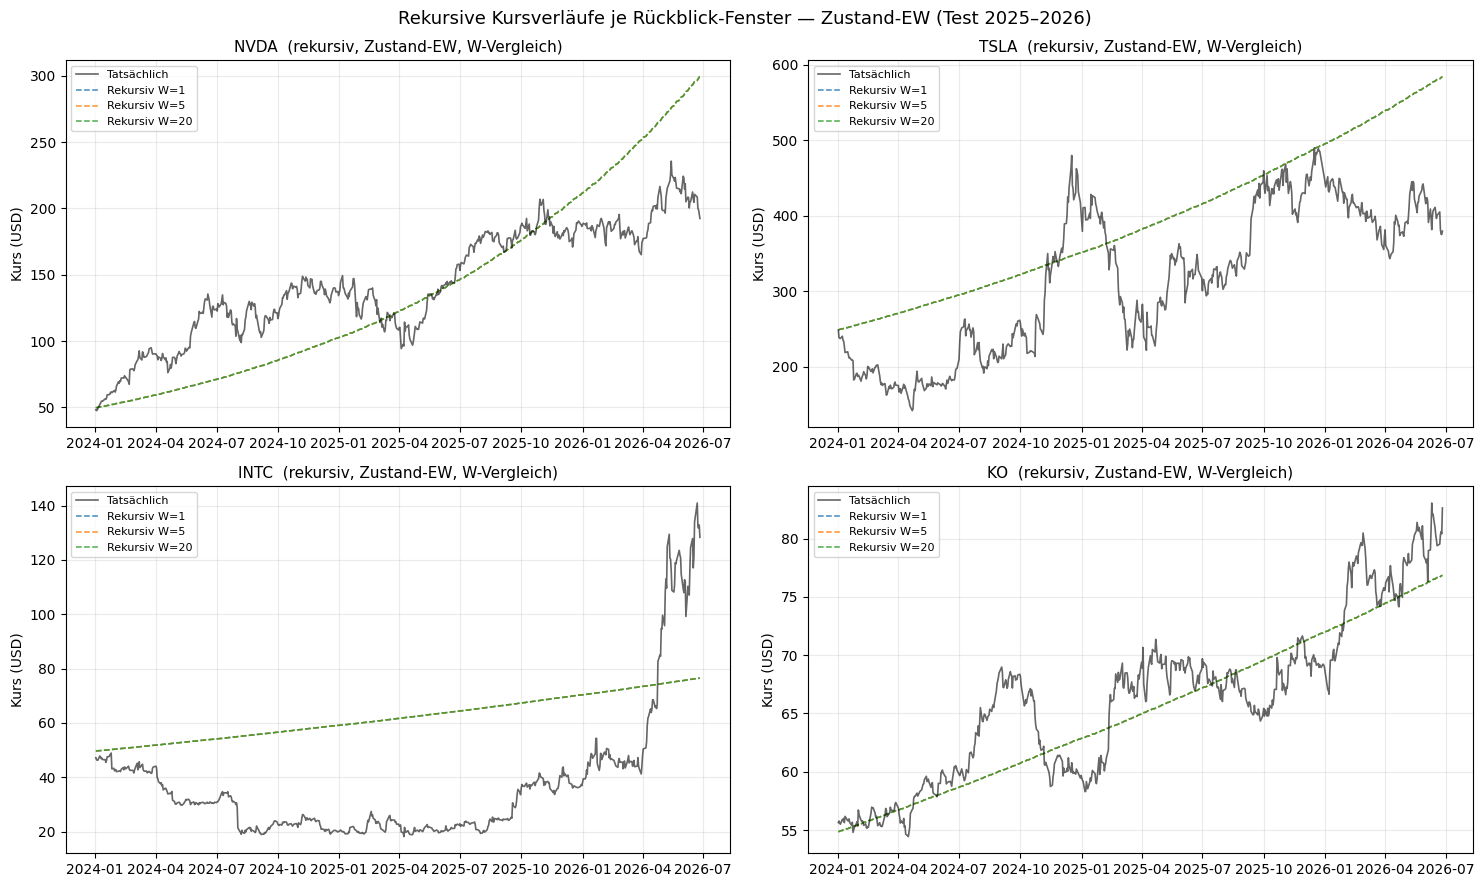

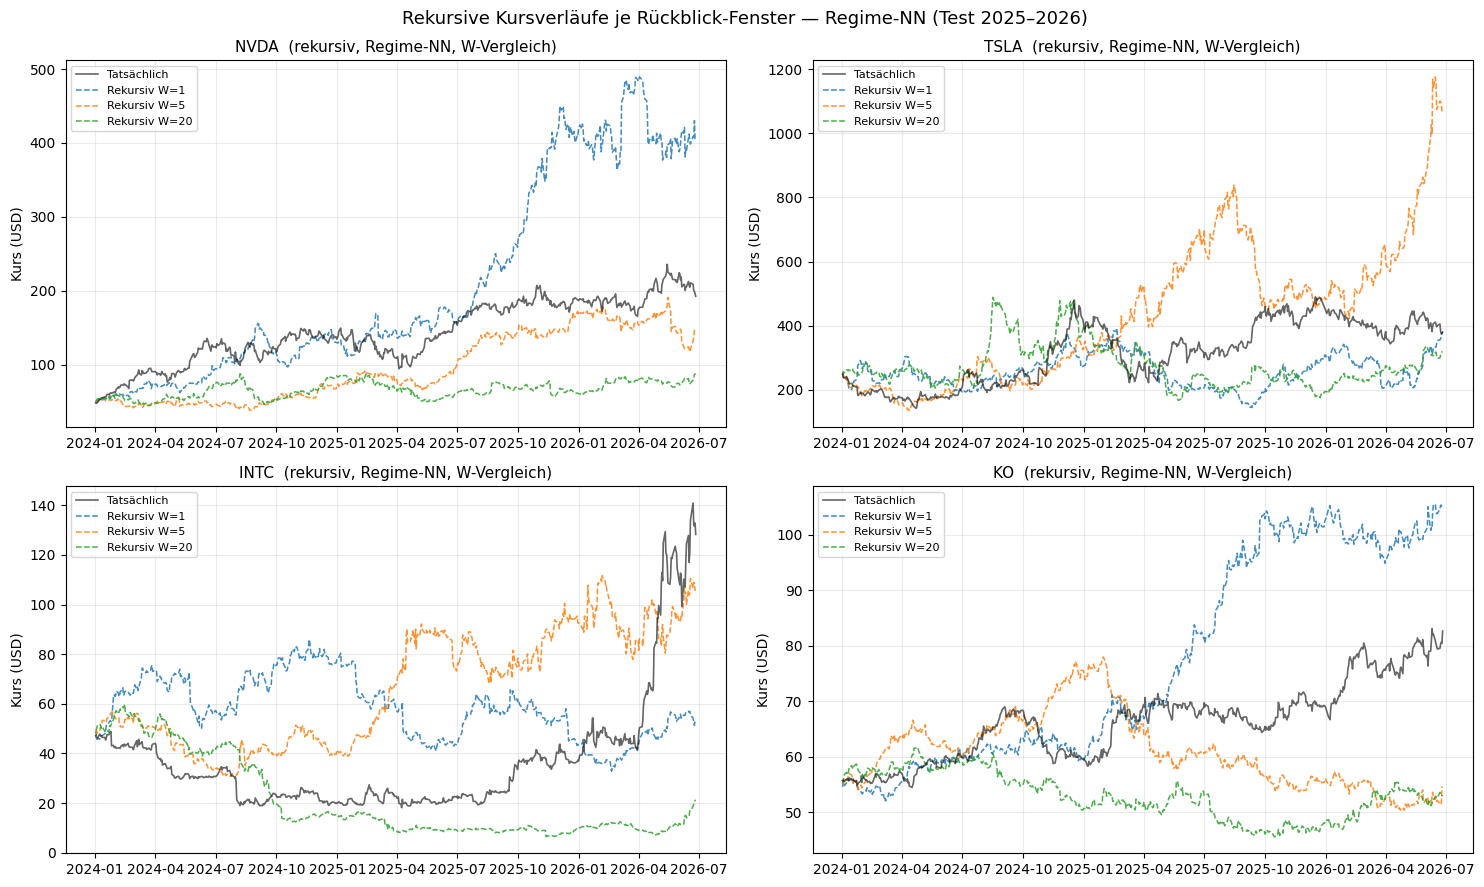

In [20]:
 import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Konfig (von mehreren Blöcken genutzt)
COLORS_W = {1: "#1f77b4", 5: "#ff7f0e", 20: "#2ca02c"}
COLOR_M  = {"M1": "#1f77b4", "M2": "#d62728"}
METHODS  = [("M1", "Regime-NN"), ("M2", "Zustand-EW")]


def directional_accuracy(preds, actuals):
    valid = ~np.isnan(preds)
    if valid.sum() == 0:
        return np.nan
    return (np.sign(preds[valid]) == np.sign(actuals[valid])).mean() * 100


# ── 1. Kennzahlen-Tabellen mit Summenspalte + Hervorhebung der besten Zeile ──────────
METHOD_KEYS = [f"{'M1' if m == 0 else 'M2'}_W{W}_H{H}"
               for m in range(2) for W in WINDOW_SIZES for H in HORIZONS]
VARIANT_LABELS = {
    key: f"{'Regime-NN ' if key[:2] == 'M1' else 'Zustand-EW'} "
         f"W={W:2d} H={H:2d}"
    for m in range(2) for W in WINDOW_SIZES for H in HORIZONS
    for key in [f"{'M1' if m == 0 else 'M2'}_W{W}_H{H}"]
}


def metric_table(metric_fn):
    rows = {VARIANT_LABELS[key]: [metric_fn(*all_forecasts_tp[t][key]) for t in TICKERS]
            for key in METHOD_KEYS}
    df = pd.DataFrame.from_dict(rows, orient="index", columns=TICKERS)
    df["Summe"]        = df[TICKERS].sum(axis=1)    # Zeilensumme über alle Ticker
    df["Durchschnitt"] = df[TICKERS].mean(axis=1)   # Zeilendurchschnitt über alle Ticker
    return df


def show_table(title, df, best, fmt):
    """Zeigt die Tabelle mit grün hervorgehobener bester Zeile (nach 'Durchschnitt')."""
    best_idx = df["Durchschnitt"].idxmax() if best == "max" else df["Durchschnitt"].idxmin()
    styler = (df.style
                .format(fmt)
                .apply(lambda row: ["background-color: #b7e1a1" if row.name == best_idx
                                    else "" for _ in row], axis=1)
                .set_caption(title))
    display(styler)


show_table("Directional Accuracy (%) — beste Zeile grün (höchste Summe)",
           metric_table(directional_accuracy), best="max", fmt="{:.1f}")


# ── 2. Kurs-Charts je Ticker & Horizont: IST vs. beste Prognose (re-anchored) ──────────
# Getrennte, große Charts (12 = 4 Ticker × 3 Horizonte). Prognosekurs = IST-Kurs am
# Horizontstart × exp(kumulierte prognostizierte H-Rendite), aufgetragen am ZIELdatum
# (Origin t -> Ziel t+H-1). Je Methode das nach Directional Accuracy beste Rückblickfenster.
HORIZON_LABEL = {1: "1 Tag", 5: "5 Tage (1 Woche)", 20: "20 Tage (~1 Monat)"}
METHOD_LS  = {"M1": "-", "M2": "--"}   # Methode über Linienstil, Fenster über Farbe (COLORS_W)


for ticker in TICKERS:
    dates    = dates_test[ticker]
    p_actual = prices_test[ticker]
    origin   = np.concatenate([[price_anchor[ticker]], p_actual[:-1]])  # Kurs vor Tag t
    for H in HORIZONS:
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(dates, p_actual, color="black", linewidth=1.4,
                label="Tatsächlich", zorder=5)
        # Einheitlich: jedes Chart zeigt IST + beide Methoden × alle Fenster (W=1/5/20).
        for m, mlabel in METHODS:
            for W in WINDOW_SIZES:
                preds = all_forecasts_tp[ticker][f"{m}_W{W}_H{H}"][0]
                fc    = origin * np.exp(preds / 100.0)        # Zielkurs für Tag t+H-1
                idx   = np.where(~np.isnan(preds))[0]
                ax.plot(dates[idx + (H - 1)], fc[idx], color=COLORS_W[W], linewidth=1.0,
                        linestyle=METHOD_LS[m], alpha=0.8,
                        label=f"{mlabel} W={W}")
        ax.set_title(f"{ticker} — Kursprognose für {HORIZON_LABEL[H]}", fontsize=12)
        ax.set_ylabel("Kurs (USD)")
        ax.set_xlabel("Datum")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=9, loc="best")
        fig.tight_layout()
        plt.show()


# ── 3. Rekursive Kursverläufe je Rückblick-Fenster (W=1/5/20) — je Methode, Feld pro Aktie ──
# Start am price_anchor, dann fortlaufend mit den Prognose-Returns aufmultiplizieren
# (Kurs baut auf dem vorherigen PROGNOSE-Kurs auf, kein Reset auf die Wahrheit -> Fehler
# akkumulieren). Log-Returns sind additiv => cumsum, dann exp. Einmal für M2, einmal für M1.
for rec_m, rec_label in [("M2", "Zustand-EW"), ("M1", "Regime-NN")]:
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    for ax, ticker in zip(axes.flat, TICKERS):
        dates  = dates_test[ticker]
        anchor = price_anchor[ticker]

        ax.plot(dates, prices_test[ticker], color="black", linewidth=1.2, alpha=0.6,
                label="Tatsächlich", zorder=5)
        for W in WINDOW_SIZES:
            pred_ret = np.nan_to_num(all_forecasts_tp[ticker][f"{rec_m}_W{W}_H1"][0], nan=0.0)
            p_rec    = anchor * np.exp(np.cumsum(pred_ret) / 100.0)
            ax.plot(dates, p_rec, color=COLORS_W[W], linewidth=1.1, linestyle="--",
                    alpha=0.85, label=f"Rekursiv W={W}")

        ax.set_title(f"{ticker}  (rekursiv, {rec_label}, W-Vergleich)", fontsize=11)
        ax.set_ylabel("Kurs (USD)")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="best")

    fig.suptitle(f"Rekursive Kursverläufe je Rückblick-Fenster — {rec_label} (Test 2025–2026)",
                 fontsize=13)
    fig.tight_layout()
    plt.show()


### Signifikanztest der Prognosen — Binomialtest der Trefferquote + Konfidenzintervall

Prüft mit **einem** klassischen Test, ob die HMM-Prognosen besser als Zufall sind: einem **zweiseitigen Binomialtest** der Directional Accuracy (Anteil richtiger Vorzeichen) gegen das Zufallsniveau von 50 %, ergänzt um das **95 %-Wilson-Konfidenzintervall**. Enthält das Intervall die 50 %, ist die Trefferquote nicht von einem Münzwurf zu unterscheiden. Der Test läuft auf **allen** Beobachtungen (ohne Ausdünnung).

Ausgewertet werden die beiden berichteten Modelle: die **Gauß-Schätzung** (`all_forecasts`) und die **Student-t-Schätzung via pomegranate** (`all_forecasts_tp`). Die eigene t-Implementierung dient nur als Korrektheits-Check und wird hier nicht getestet.

*Hinweis:* Bei den Horizonten H = 5 und H = 20 überlappen sich die kumulierten Fenster; die aufeinanderfolgenden Beobachtungen sind dann autokorreliert, wodurch der p-Wert dort tendenziell **etwas zu optimistisch** ausfällt (in der Tabellen-Beschriftung vermerkt).

In [21]:
import numpy as np
import pandas as pd
from scipy.stats import binomtest
from IPython.display import display

# ── Signifikanztest der Prognosen — Binomialtest der Trefferquote + Konfidenzintervall ──
# Prüft, ob die Directional Accuracy (Anteil richtiger Vorzeichen) signifikant von 50 %
# (Zufallsniveau) abweicht: zweiseitiger Binomialtest + 95 %-Wilson-Konfidenzintervall,
# gerechnet auf allen Beobachtungen (ohne Ausdünnung). Wird für jedes vorhandene Modell
# (Gauß-HMM sowie – falls berechnet – die Student-t-Varianten) als eigene Tabelle ausgegeben.
# Hinweis: Bei H=5/20 überlappen die kumulierten Fenster; der p-Wert ist dort wegen der
# Autokorrelation tendenziell etwas zu optimistisch (in der Beschriftung vermerkt).

ALPHA = 0.05


def _directional_test(y_true, y_pred):
    """Binomialtest der Trefferquote gegen Zufall (p=0,5) + 95 %-Wilson-CI.
    Unentschieden (Vorzeichen 0 bei Prognose oder Ist) werden ausgeschlossen."""
    s_true, s_pred = np.sign(y_true), np.sign(y_pred) # Vorzeichen der Renditen
    keep = (s_true != 0) & (s_pred != 0) #Interessant sind nur Tage mit Veränderung -> schmeisse 0 Tage raus
    n_dir = int(keep.sum()) #Summe über die übrigen Tage
    if n_dir == 0:
        return dict(n_dir=0, DA=np.nan, binom_p=np.nan, ci_low=np.nan, ci_high=np.nan)
    hits = int((s_true[keep] == s_pred[keep]).sum()) #Wie oft ear Prognose = Realität
    res = binomtest(hits, n_dir, p=0.5, alternative="two-sided") #Binomialtest
    ci = res.proportion_ci(confidence_level=1 - ALPHA, method="wilson") #Konfidenzintervall
    return dict(n_dir=n_dir, DA=hits / n_dir * 100.0, binom_p=res.pvalue,
                ci_low=ci.low * 100.0, ci_high=ci.high * 100.0)


def evaluate_predictions(y_true, y_pred, H):
    """
    Signifikanztest einer Return-Prognose über die Trefferquote (Directional Accuracy):
    zweiseitiger Binomialtest gegen 50 % + 95 %-Wilson-Konfidenzintervall.

    Parameter
    ---------
    y_true, y_pred : array-like
        Tatsächliche und prognostizierte (kumulierte) H-Tage-Log-Returns. NaN-Paare
        (Randtage ohne gültige Prognose) werden automatisch entfernt.
    H : int
        Prognosehorizont (nur zur Kennzeichnung; der Test läuft auf allen Beobachtungen).

    Rückgabe
    --------
    dict mit Trefferquote (DA), Binomial-p-Wert, Wilson-CI und Gesamturteil.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[valid], y_pred[valid]
    n = int(len(y_true))

    t = _directional_test(y_true, y_pred)
    sig = bool(np.isfinite(t["binom_p"]) and t["binom_p"] < ALPHA)
    return {
        "n": n, "H": H, "n_dir": t["n_dir"], "DA": t["DA"], "binom_p": t["binom_p"],
        "da_ci_low": t["ci_low"], "da_ci_high": t["ci_high"],
        "significant_direction": sig,
        "verdict": ("Trefferquote signifikant ≠ 50 % (p<0,05)" if sig
                    else "Trefferquote nicht signifikant von 50 % verschieden (p≥0,05)"),
    }


# ── Treiber: eine Signifikanz-Tabelle je vorhandenem Modell ──────────────────────
METHOD_LABEL = {"M1": "Regime/Nguyen", "M2": "Zustand-EW"}


def _highlight(row):
    """Signifikante Zeilen (p<0,05) rot, sonst neutral grün (= Befund bestätigt)."""
    p = row["Binom-p"]
    color = "#f4b6b6" if (np.isfinite(p) and p < ALPHA) else "#e6f2e6"
    return [f"background-color: {color}"] * len(row)


def run_significance(forecasts, model_label):
    """Signifikanz-Tabelle (Binomialtest + Wilson-CI) für einen Prognose-Satz erstellen."""
    records = []
    for ticker in TICKERS:
        for m in ("M1", "M2"):
            for W in WINDOW_SIZES:
                for H in HORIZONS:
                    preds, actuals = forecasts[ticker][f"{m}_W{W}_H{H}"]
                    r = evaluate_predictions(actuals, preds, H)
                    records.append({
                        "Ticker": ticker, "Methode": METHOD_LABEL[m], "W": W, "H": H,
                        "n": r["n"], "DA %": r["DA"], "Binom-p": r["binom_p"],
                        "CI low %": r["da_ci_low"], "CI high %": r["da_ci_high"],
                        "signifikant": r["significant_direction"],
                    })
    df = pd.DataFrame(records)
    fmt = {"DA %": "{:.1f}", "Binom-p": "{:.3f}", "CI low %": "{:.1f}", "CI high %": "{:.1f}"}
    styler = (df.style
              .format(fmt, na_rep="—")
              .apply(_highlight, axis=1)
              .set_caption(f"Signifikanztest der Trefferquote — {model_label}. Binomialtest vs. 50 % "
                           "+ 95 %-Wilson-CI. Rot = signifikant (p<0,05), grün = nicht von Zufall "
                           "unterscheidbar. Enthält das CI die 50 %, ist die Prognose ein Münzwurf. "
                           "(H=5/20: p wegen Fenster-Überlappung leicht optimistisch.)"))
    display(styler)
    n_sig = int(df["signifikant"].sum())
    print(f"{model_label}: signifikant ≠ 50 % in {n_sig} von {len(df)} Varianten "
          f"(bei Zufall & α=0,05 erwartbar: ~{ALPHA*len(df):.0f} Fehlalarme).\n")
    return df


# Getestet wird auf der Gauß-Schätzung und der Student-t-Schätzung via pomegranate
# (Bibliotheks-Implementierung; die eigene t-Implementierung dient nur als Korrektheits-Check
# und wird hier bewusst nicht ausgewertet).
MODELS = [("Gauß-HMM", "all_forecasts"),
          ("Student-t (pomegranate)", "all_forecasts_tp")]

sig_tables = {}
for label, var in MODELS:
    if var in globals():
        sig_tables[label] = run_significance(globals()[var], label)

print("Kernbefund: Ist keine Variante über die ~α·n Fehlalarme hinaus signifikant, besitzen die "
      "HMM-Prognosen keinen statistisch belastbaren Richtungsgehalt.")


,Ticker,Methode,W,H,n,DA %,Binom-p,CI low %,CI high %,signifikant
0,NVDA,Regime/Nguyen,1,1,622,44.4,0.006,40.6,48.4,True
1,NVDA,Regime/Nguyen,1,5,618,47.6,0.243,43.7,51.5,False
2,NVDA,Regime/Nguyen,1,20,603,53.1,0.143,49.1,57.0,False
3,NVDA,Regime/Nguyen,5,1,622,52.6,0.214,48.6,56.5,False
4,NVDA,Regime/Nguyen,5,5,618,51.0,0.658,47.0,54.9,False
5,NVDA,Regime/Nguyen,5,20,603,56.9,0.001,52.9,60.8,True
6,NVDA,Regime/Nguyen,20,1,622,47.7,0.279,43.8,51.7,False
7,NVDA,Regime/Nguyen,20,5,618,51.5,0.494,47.5,55.4,False
8,NVDA,Regime/Nguyen,20,20,603,56.4,0.002,52.4,60.3,True
9,NVDA,Zustand-EW,1,1,622,46.0,0.049,42.1,49.9,True


Gauß-HMM: signifikant ≠ 50 % in 15 von 72 Varianten (bei Zufall & α=0,05 erwartbar: ~4 Fehlalarme).



,Ticker,Methode,W,H,n,DA %,Binom-p,CI low %,CI high %,signifikant
0,NVDA,Regime/Nguyen,1,1,622,48.4,0.446,44.5,52.3,False
1,NVDA,Regime/Nguyen,1,5,618,52.5,0.227,48.6,56.4,False
2,NVDA,Regime/Nguyen,1,20,603,55.2,0.012,51.2,59.1,True
3,NVDA,Regime/Nguyen,5,1,622,57.1,0.000,53.2,61.0,True
4,NVDA,Regime/Nguyen,5,5,618,50.8,0.717,46.9,54.7,False
5,NVDA,Regime/Nguyen,5,20,603,53.1,0.143,49.1,57.0,False
6,NVDA,Regime/Nguyen,20,1,622,51.5,0.495,47.5,55.4,False
7,NVDA,Regime/Nguyen,20,5,618,52.5,0.227,48.6,56.4,False
8,NVDA,Regime/Nguyen,20,20,603,56.1,0.003,52.1,60.0,True
9,NVDA,Zustand-EW,1,1,622,54.0,0.049,50.1,57.9,True


Student-t (pomegranate): signifikant ≠ 50 % in 20 von 72 Varianten (bei Zufall & α=0,05 erwartbar: ~4 Fehlalarme).

Kernbefund: Ist keine Variante über die ~α·n Fehlalarme hinaus signifikant, besitzen die HMM-Prognosen keinen statistisch belastbaren Richtungsgehalt.


### Übersicht: Wie viele Aktien sind signifikant? (je Verteilung × Verfahren)

Verdichtet den Binomialtest aus der vorigen Zelle: Für jede Kombination aus **Verteilung** (Gauß-HMM, Student-t via pomegranate) und **Verfahren** (M1 = Regime/Nguyen, M2 = Zustand-EW) zeigt eine Matrix, **wie viele der 4 Aktien** je Rückblickfenster **W** (Zeilen) und Prognosehorizont **H** (Spalten) eine signifikante Trefferquote hatten (Binomialtest p < 0,05). Beispiel: steht bei W=1 / H=1 eine **1**, war 1 von 4 Aktien signifikant.

Bei reinem Zufall sind pro Zelle im Schnitt nur rund 0,2 von 4 Aktien signifikant (alpha = 0,05); Werte von 0 oder 1 sind also mit Zufall vereinbar. Es folgt eine Zelle je Verteilung × Verfahren. *(H=5/20: p wegen Fenster-Überlappung leicht optimistisch.)*

Voraussetzung: Die Signifikanz-Zelle (definiert `evaluate_predictions`) sowie die jeweiligen Forecast-Zellen (`all_forecasts`, `all_forecasts_tp`) müssen vorher gelaufen sein.

In [29]:
import numpy as np
import pandas as pd
from IPython.display import display

# ── Übersicht: Anzahl der Aktien (von 4) mit SIGNIFIKANTER Trefferquote je (W, H) ──
# Zählt pro Rückblickfenster W und Horizont H, bei wie vielen der TICKERS der Binomialtest
# signifikant war (p<0,05; significant_direction aus evaluate_predictions der Signifikanz-Zelle).
# Beispiel-Lesart: steht in Zeile W=1 / Spalte H=1 eine 1, war 1 von 4 Aktien signifikant.
# Zeilen = W, Spalten = H. (H=5/20: p wegen Fenster-Überlappung leicht optimistisch.)

_SIG_COLORS = {0: "#e6f2e6", 1: "#fff2cc", 2: "#ffd9b3", 3: "#f4b6b6", 4: "#e57373"}


def count_significant_matrix(forecasts, method):
    """DataFrame (Zeilen W, Spalten H) mit der Anzahl signifikanter Aktien (0..len(TICKERS))."""
    mat = pd.DataFrame(index=[f"W={W}" for W in WINDOW_SIZES],
                       columns=[f"H={H}" for H in HORIZONS], dtype=int)
    for W in WINDOW_SIZES:
        for H in HORIZONS:
            n_sig = 0
            for t in TICKERS:
                preds, actuals = forecasts[t][f"{method}_W{W}_H{H}"]
                if evaluate_predictions(actuals, preds, H)["significant_direction"]:
                    n_sig += 1
            mat.loc[f"W={W}", f"H={H}"] = n_sig
    return mat.astype(int)


def show_sig_count(forecasts_name, method, method_label, dist_label):
    """Zeigt die Zähl-Matrix als eingefärbte Tabelle, falls der Prognose-Satz existiert."""
    if forecasts_name not in globals():
        print(f"{forecasts_name} nicht vorhanden — zugehörige Forecast-Zelle zuerst ausführen "
              f"({dist_label}).")
        return
    n = len(TICKERS)
    mat = count_significant_matrix(globals()[forecasts_name], method)
    styler = (mat.style
              .map(lambda v: f"background-color: {_SIG_COLORS.get(int(v), '#e57373')}")
              .format("{:d}")
              .set_caption(f"{dist_label} · {method_label}: Anzahl der {n} Aktien mit signifikanter "
                           f"Trefferquote (Binomialtest p<0,05) je Rückblickfenster W (Zeilen) und "
                           f"Prognosehorizont H (Spalten). 0 = keine Aktie signifikant."))
    display(styler)
    print(f"{dist_label} · {method_label}: insgesamt {int(mat.values.sum())} signifikante "
          f"Kombinationen von {n * mat.size} (Aktie × W × H).\n")


# Gauß-HMM · Methode 1 (Regime/Nguyen)
show_sig_count("all_forecasts", "M1", "Regime/Nguyen (M1)", "Gauß-HMM")


,H=1,H=5,H=20
W=1,1,0,0
W=5,0,0,1
W=20,1,0,1


Gauß-HMM · Regime/Nguyen (M1): insgesamt 4 signifikante Kombinationen von 36 (Aktie × W × H).



In [23]:
# Gauß-HMM · Methode 2 (Zustand-EW) — nutzt Helfer aus der vorigen Übersichts-Zelle
show_sig_count("all_forecasts", "M2", "Zustand-EW (M2)", "Gauß-HMM")


,H=1,H=5,H=20
W=1,1,1,3
W=5,0,1,2
W=20,0,1,2


Gauß-HMM · Zustand-EW (M2): insgesamt 11 signifikante Kombinationen von 36 (Aktie × W × H).



In [24]:
# Student-t (pomegranate) · Methode 1 (Regime/Nguyen)
show_sig_count("all_forecasts_tp", "M1", "Regime/Nguyen (M1)", "Student-t (pomegranate)")


,H=1,H=5,H=20
W=1,0,1,1
W=5,2,0,0
W=20,0,0,1


Student-t (pomegranate) · Regime/Nguyen (M1): insgesamt 5 signifikante Kombinationen von 36 (Aktie × W × H).



In [25]:
# Student-t (pomegranate) · Methode 2 (Zustand-EW)
show_sig_count("all_forecasts_tp", "M2", "Zustand-EW (M2)", "Student-t (pomegranate)")


,H=1,H=5,H=20
W=1,1,1,3
W=5,1,1,3
W=20,1,1,3


Student-t (pomegranate) · Zustand-EW (M2): insgesamt 15 signifikante Kombinationen von 36 (Aktie × W × H).



### Trading-Backtest — kann man mit dem Modell Geld verdienen?

Vergleich verschiedener Handelsstrategien auf dem **Testzeitraum**, jede startet mit **1000 €**, **keine Handelskosten**, Handel **zum Close**. Jede Strategie ist ein täglicher **Positionsvektor** (−1 Short / 0 Cash / +1 Long); daraus mit **einfachen (arithmetischen) Renditen** `Kapital = 1000·∏(1 + Position·Rendite)` und alle Kennzahlen (long verdient +Rendite, short −Rendite; keine Log-Kompoundierung).

**Referenzen (nutzen den echten Kurs):** Buy & Hold · Perfekt Long-only (nur an Auf-Tagen long) · Perfekt Long/Short (long auf / short ab — theoretische Obergrenze) · Zufall Long/Short (Mittel über 1000 Simulationen, Null-Referenz).

**Prognose-getrieben** (je Gauß & pomegranate-t × M1/M2): **Long-only** (kaufen wenn Prognose>0, sonst Cash = Nguyen) und **Long/Short** (long/short nach Prognose-Vorzeichen) an den Fenstern **W5/H1, W20/H1** (täglich) sowie **W20/H20** long-only in zwei Varianten: **(Block)** = Entscheidung alle 20 Tage (nicht überlappend) und **(täglich)** = jeden Tag die aktuelle 20-Tage-Prognose gehandelt (überlappend, deckungsgleich mit der Forecast-Auswertung).

Kein Look-ahead: Positionen nutzen nur Information bis zum Vortag; die Perfekt-Info-Strategien verwenden bewusst die realisierten Renditen und sind als Ober-/Untergrenzen zu lesen. Ausgabe: je Ticker eine Tabelle (alle Strategien) + ein Chart der Kapitalverläufe von **Buy & Hold und den Prognosestrategien** (lineare Skala; Perfekt-Info und Zufall stehen nur in der Tabelle, da sie die Chart-Skala verzerren würden), am Ende eine Durchschnittstabelle.

*Voraussetzung: die Forecast-Zellen für Gauß (`all_forecasts`) und pomegranate-t (`all_forecasts_tp`) müssen vorher gelaufen sein.*

,Endkapital (€),Rendite (%),Sharpe,Trefferquote (%),#Trades
Strategie,,,,,
Buy & Hold,"3,890",+289.0,1.37,53.9,1
Perfekt Long-only,"2,096,250",+209525.0,10.13,100.0,326
Perfekt Long/Short,"874,060,103",+87405910.3,16.75,100.0,327
Gauß-M1 · W5H1 · Long-only,"2,542",+154.2,1.20,55.6,310
Gauß-M1 · W5H1 · Long/Short,"1,278",+27.8,0.45,52.6,310
Gauß-M1 · W20H1 · Long-only,"2,142",+114.2,1.09,51.7,306
Gauß-M1 · W20H1 · Long/Short,841,-15.9,0.10,47.7,308
Gauß-M1 · W20H20 · Long-only (Block),"2,160",+116.0,1.04,56.4,20
Gauß-M1 · W20H20 · Long-only (täglich),"2,488",+148.8,1.10,53.8,230


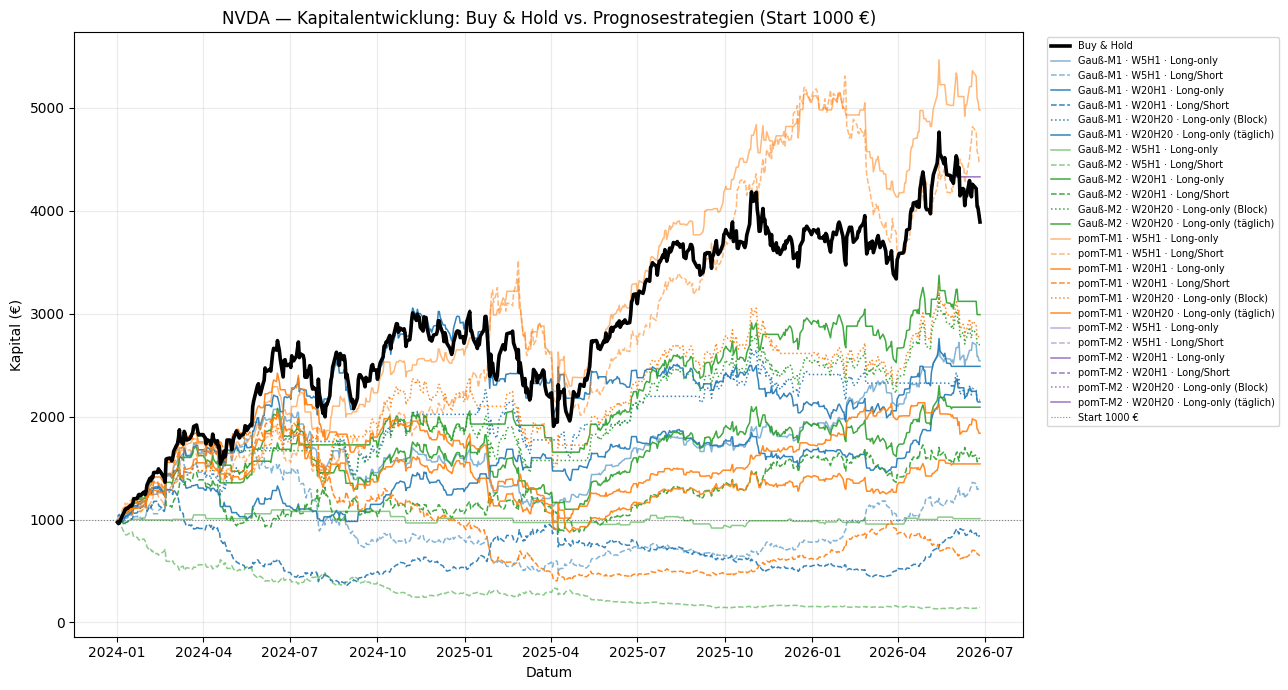

,Endkapital (€),Rendite (%),Sharpe,Trefferquote (%),#Trades
Strategie,,,,,
Buy & Hold,"1,528",+52.8,0.58,50.6,1
Perfekt Long-only,"5,826,281",+582528.1,9.16,100.0,313
Perfekt Long/Short,"15,314,216,022",+1531421502.2,16.66,100.0,314
Gauß-M1 · W5H1 · Long-only,990,-1.0,0.22,48.5,290
Gauß-M1 · W5H1 · Long/Short,456,-54.4,-0.24,47.9,291
Gauß-M1 · W20H1 · Long-only,555,-44.5,-0.34,45.6,296
Gauß-M1 · W20H1 · Long/Short,134,-86.6,-1.06,45.0,297
Gauß-M1 · W20H20 · Long-only (Block),"1,227",+22.7,0.41,47.9,16
Gauß-M1 · W20H20 · Long-only (täglich),"1,375",+37.5,0.51,52.5,290


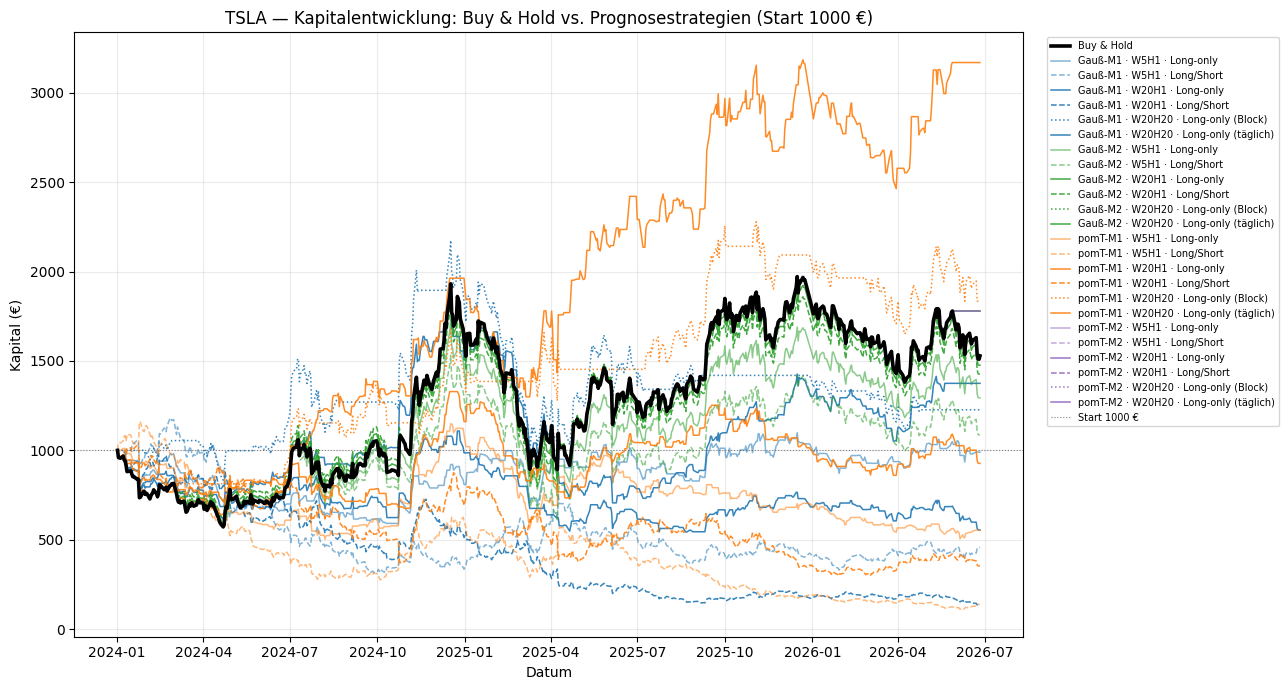

,Endkapital (€),Rendite (%),Sharpe,Trefferquote (%),#Trades
Strategie,,,,,
Buy & Hold,"2,588",+158.8,0.91,49.1,1
Perfekt Long-only,"8,610,955",+860995.5,8.41,100.0,316
Perfekt Long/Short,"18,772,757,351",+1877275635.1,14.36,100.0,321
Gauß-M1 · W5H1 · Long-only,793,-20.7,0.02,47.3,322
Gauß-M1 · W5H1 · Long/Short,132,-86.8,-0.93,47.6,326
Gauß-M1 · W20H1 · Long-only,"1,093",+9.3,0.31,49.0,288
Gauß-M1 · W20H1 · Long/Short,223,-77.7,-0.60,49.5,293
Gauß-M1 · W20H20 · Long-only (Block),"2,603",+160.3,1.04,50.0,12
Gauß-M1 · W20H20 · Long-only (täglich),"1,520",+52.0,0.59,47.9,272


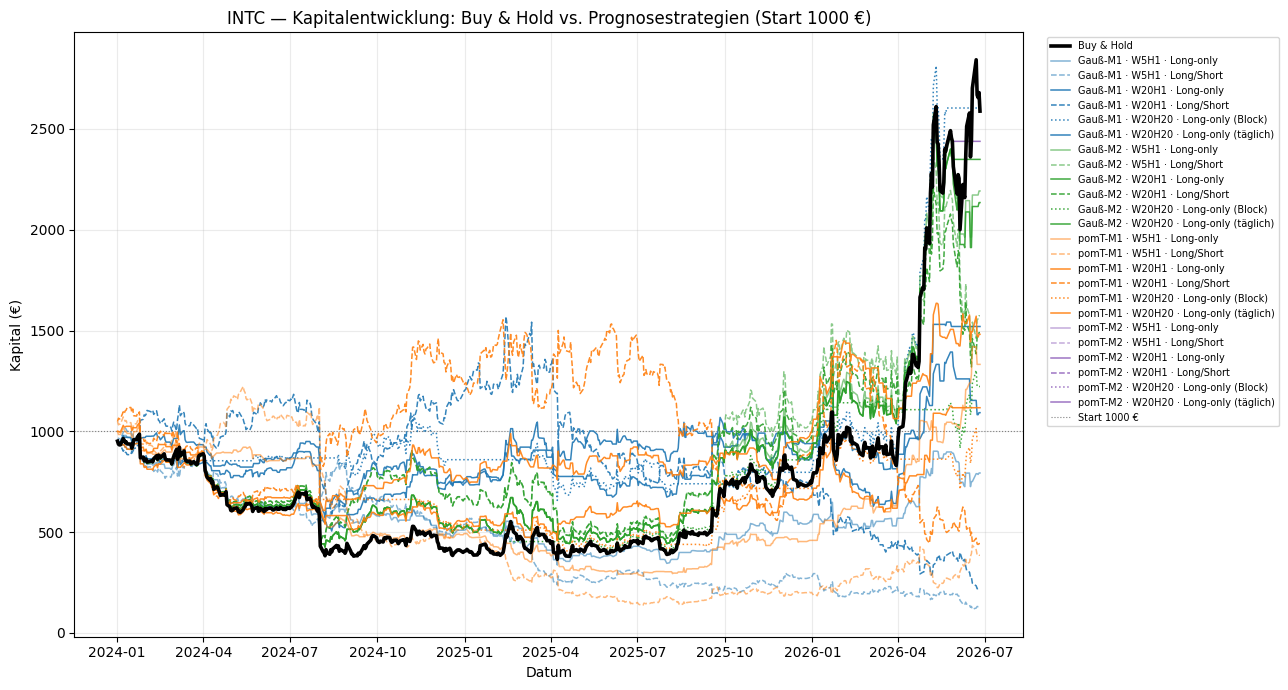

,Endkapital (€),Rendite (%),Sharpe,Trefferquote (%),#Trades
Strategie,,,,,
Buy & Hold,"1,508",+50.8,1.11,51.2,1
Perfekt Long-only,"13,006",+1200.6,9.89,100.0,329
Perfekt Long/Short,"109,364",+10836.4,17.95,100.0,332
Gauß-M1 · W5H1 · Long-only,"1,243",+24.3,0.81,51.3,310
Gauß-M1 · W5H1 · Long/Short,"1,026",+2.6,0.14,49.8,316
Gauß-M1 · W20H1 · Long-only,"1,108",+10.8,0.43,50.6,322
Gauß-M1 · W20H1 · Long/Short,807,-19.3,-0.46,49.2,325
Gauß-M1 · W20H20 · Long-only (Block),"1,173",+17.3,0.59,49.7,16
Gauß-M1 · W20H20 · Long-only (täglich),"1,247",+24.7,0.82,51.6,292


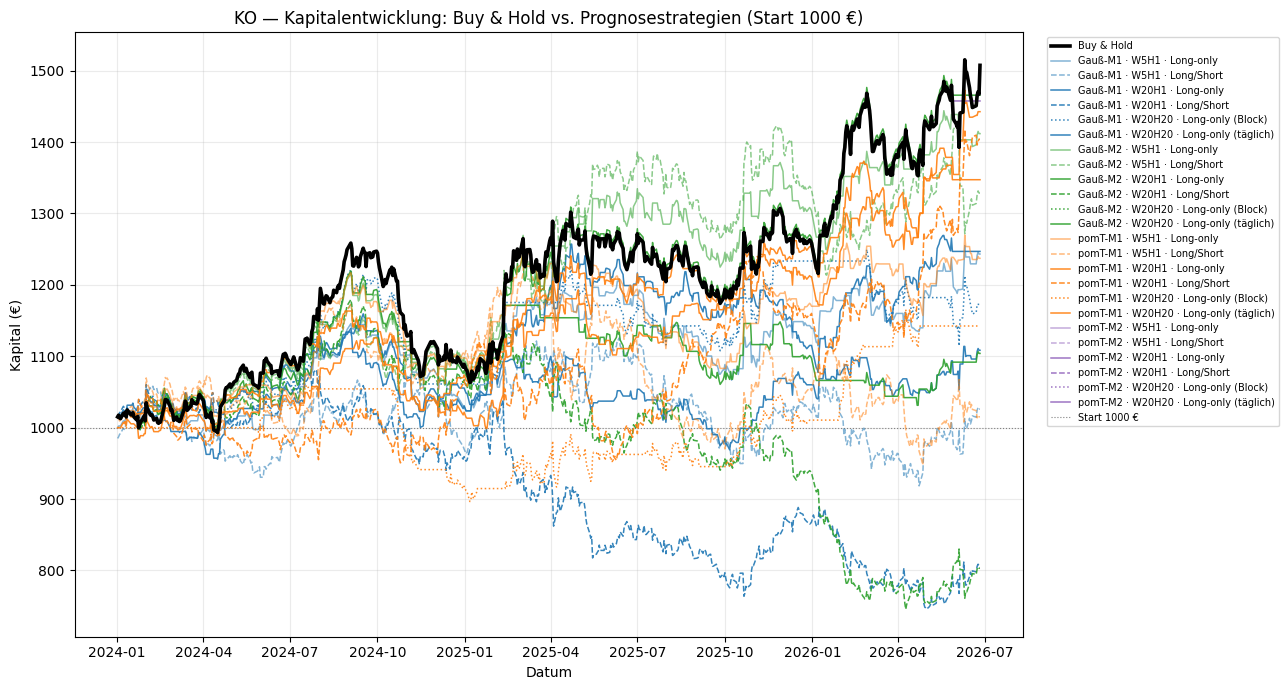

,Endkapital (€),Rendite (%),Sharpe,Trefferquote (%),#Trades
Strategie,,,,,
Buy & Hold,"2,378",+137.8,0.99,51.2,1
Perfekt Long-only,"4,136,623",+413562.3,9.40,100.0,321
Perfekt Long/Short,"8,740,285,710",+874028471.0,16.43,100.0,324
Gauß-M1 · W5H1 · Long-only,"1,392",+39.2,0.56,50.7,308
Gauß-M1 · W5H1 · Long/Short,723,-27.7,-0.14,49.5,311
Gauß-M1 · W20H1 · Long-only,"1,224",+22.4,0.37,49.2,303
Gauß-M1 · W20H1 · Long/Short,501,-49.9,-0.51,47.9,306
Gauß-M1 · W20H20 · Long-only (Block),"1,791",+79.1,0.77,51.0,16
Gauß-M1 · W20H20 · Long-only (täglich),"1,657",+65.7,0.75,51.4,271


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ── Trading-Backtest: kann man mit dem Modell Geld verdienen? ────────────────────────
# Alle Strategien auf dem Testzeitraum, Start 1000 €, keine Kosten, Handel zum Close.
# Kernidee: jede Strategie = täglicher Positionsvektor pos_t ∈ {-1,0,+1} (Short/Cash/Long).
#   einfache (arithmetische) Tagesrendite: sr_t = exp(r_t/100) - 1   (r = data_test, Log-% ) wegen log-Renditen
#   Portfolio-Tagesrendite = pos·sr (long=+sr, short=-sr, cash=0)
#   Equity_t = 1000 · ∏(1 + pos·sr)   — echte einfache Renditen, keine Log-Kompoundierung
# Kein Look-ahead: pos_t nutzt nur Info bis Close t-1; Prognosen preds[t] ebenfalls (bis t-1).
# Perfekt-Info-Strategien nutzen bewusst r_t (Foresight) — als Ober-/Untergrenzen deklariert.

START_CAP     = 1000.0
TRADING_DAYS  = 252
# Prognose-Basen (Label, Methode, Variablenname) — custom-t bewusst ausgelassen
FC_BASES      = [("Gauß", "M1", "all_forecasts"),  ("Gauß", "M2", "all_forecasts"),
                 ("pomT", "M1", "all_forecasts_tp"), ("pomT", "M2", "all_forecasts_tp")]
FC_W_DAILY    = [5, 20]        # Fenster für die täglichen (H=1) Strategien
BASE_COLOR    = {"Gauß-M1": "#1f77b4", "Gauß-M2": "#2ca02c",
                 "pomT-M1": "#ff7f0e", "pomT-M2": "#9467bd"}


# ── Kennzahlen aus einem Positionsvektor ─────────────────────────────────────────────
def _metrics(pos, r):
    pos = np.asarray(pos, float); r = np.asarray(r, float)
    sr   = np.exp(r / 100.0) - 1.0                 # einfache (arithmetische) Tagesrendite
    port = pos * sr                                # Portfolio-Tagesrendite
    eq  = START_CAP * np.cumprod(1.0 + port)    #Kapital nach jedem Tag
    end = float(eq[-1]) #Endkapital
    sd    = port.std(ddof=1)
    sharpe = port.mean() / sd * np.sqrt(TRADING_DAYS) if sd > 0 else np.nan #Sharpe Ratio
    curve   = np.concatenate([[START_CAP], eq]) #eq + Startwert 1000
    mdd     = float((curve / np.maximum.accumulate(curve) - 1).min() * 100)
    active  = pos != 0 #Wann haben wir Kapital im Markt -> Rendite wird nicht mit 0 multipliziert
    hit     = float((port[active] > 0).mean() * 100) if active.sum() > 0 else np.nan #an wie vielen Tagen, an denen wir investiert waren, ist das Vermögen gewachsen
    trades  = int(np.sum(pos[1:] != pos[:-1]) + (1 if pos[0] != 0 else 0))
    m = {"Endkapital (€)": end, "Rendite (%)": (end / START_CAP - 1) * 100, "Sharpe": sharpe, "Max DD (%)": mdd,
         "Trefferquote (%)": hit, "#Trades": trades}
    return m, eq


# ── Positions-Regeln ─────────────────────────────────────────────────────────────────
def _pos_buyhold(r):     return np.ones(len(r)) #immer 1 -> immer investiert
def _pos_perfect_lo(r):  return (np.asarray(r) > 0).astype(float)      # nur Auf-Tage long -> 1 oder 0
def _pos_perfect_ls(r):  return np.sign(r)                             # long auf, short ab -> 1 oder -1

def _pos_daily(preds, rule):                                            #rule= lo long only, ls long short
    p = np.nan_to_num(np.asarray(preds, float), nan=0.0)               # Randtage -> Cash
    return np.sign(p) if rule == "LS" else (p > 0).astype(float) #Regel entscheidet wird das pos Array mit -1, 1 gefüllt oder 1, 0

def _pos_block(preds, r, H, rule): #Verhindert das Überschneiden bei H>1 : es wird alle (20) Tage eine Prognnose gemacht
    preds = np.asarray(preds, float); T = len(r); pos = np.zeros(T) #Array, # Tage , Vektor init.
    for t0 in range(0, T, H):                                          # nicht-überlappende Blöcke durch Schleife in H-Schritten
        sig = preds[t0] if t0 < len(preds) else np.nan #gibt es Prognose
        if np.isnan(sig):
            continue
        pos[t0:min(t0 + H, T)] = np.sign(sig) if rule == "LS" else (1.0 if sig > 0 else 0.0) #befülle das Array mit -1,0,1
    return pos



# ── Strategie-Set je Ticker ──────────────────────────────────────────────────────────
def build_strategies(ticker):
    r = data_test[ticker].flatten()
    rows, curves, style = [], {}, {}

    def add(label, pos, kind, base=None, rule=None, w=None, cad=None):
        m, eq = _metrics(pos, r)
        m["Strategie"] = label; rows.append(m); curves[label] = eq
        style[label] = dict(kind=kind, base=base, rule=rule, w=w, cad=cad)

    # Referenzen
    add("Buy & Hold",            _pos_buyhold(r),    "bh")
    add("Perfekt Long-only",     _pos_perfect_lo(r), "perf")
    add("Perfekt Long/Short",    _pos_perfect_ls(r), "perf")


    # Prognose-getrieben
    for base_lbl, method, fc_var in FC_BASES:
        FC = globals().get(fc_var)
        if FC is None:                                    # Modell nicht gerechnet -> überspringen
            continue
        key = f"{base_lbl}-{method}"
        for W in FC_W_DAILY:                              # täglich (H=1)
            preds = FC[ticker][f"{method}_W{W}_H1"][0]
            add(f"{key} · W{W}H1 · Long-only",  _pos_daily(preds, "LO"), "fc", key, "LO", W)
            add(f"{key} · W{W}H1 · Long/Short", _pos_daily(preds, "LS"), "fc", key, "LS", W)
        preds20 = FC[ticker][f"{method}_W20_H20"][0]      # 20-Tage-Prognose, long-only (Strategie 3)
        # (a) Block: Entscheidung alle 20 Tage, nicht überlappend
        add(f"{key} · W20H20 · Long-only (Block)",   _pos_block(preds20, r, 20, "LO"),
            "fc", key, "LO", 20, cad="block")
        # (b) täglich-rollierend: jeden Tag die aktuelle 20-Tage-Prognose handeln (überlappend,
        #     deckungsgleich mit der Forecast-Auswertung DA/Signifikanz)
        add(f"{key} · W20H20 · Long-only (täglich)", _pos_daily(preds20, "LO"),
            "fc", key, "LO", 20, cad="daily")

    df = pd.DataFrame(rows).set_index("Strategie")
    return df, curves, style


# ── Ausgabe: Tabelle + Equity-Chart je Ticker ────────────────────────────────────────
COLS = ["Endkapital (€)", "Rendite (%)",  "Sharpe",
        "Trefferquote (%)", "#Trades"]
FMT  = {"Endkapital (€)": "{:,.0f}", "Rendite (%)": "{:+.1f}",
        "Sharpe": "{:.2f}",  "Trefferquote (%)": "{:.1f}", "#Trades": "{:.0f}"}


def show_table(df, title):
    def _row_bg(row):
        if row.name.startswith("Perfekt"):  c = "#eaf3ff"
        elif row.name == "Buy & Hold":       c = "#fff6e6"
        elif row.name.startswith("Zufall"):  c = "#f0f0f0"
        else:                                c = ""
        return [f"background-color: {c}"] * len(row)
    sty = (df[COLS].style.format(FMT)
           .apply(_row_bg, axis=1)
           .set_caption(title))
    display(sty)


def plot_equity(ticker, curves, style):
    # Charts zeigen nur Buy & Hold + Prognosestrategien. Perfekt-Info und Zufall sind bewusst
    # ausgeblendet (ihre extreme Spannweite würde die Skala verzerren) -> lineare y-Achse, kein log.
    dates = dates_test[ticker]
    fig, ax = plt.subplots(figsize=(13, 7))
    for label, eq in curves.items():
        s = style[label]; k = s["kind"]
        if k in ("perf", "rand"):
            continue
        if k == "bh":
            ax.plot(dates, eq, color="black", lw=2.6, label=label, zorder=6)
        else:  # Prognosestrategien: Farbe nach Basis; LS dashed, Block dotted, sonst solid
            ls = "--" if s["rule"] == "LS" else (":" if s.get("cad") == "block" else "-")
            alpha = {5: 0.55, 20: 0.9}.get(s["w"], 0.75)
            ax.plot(dates, eq, color=BASE_COLOR.get(s["base"], "#17becf"),
                    lw=1.1, ls=ls, alpha=alpha, label=label, zorder=3)
    ax.axhline(START_CAP, color="gray", lw=0.8, ls=":", label="Start 1000 €")
    ax.set_title(f"{ticker} — Kapitalentwicklung: Buy & Hold vs. Prognosestrategien (Start 1000 €)")
    ax.set_ylabel("Kapital (€)"); ax.set_xlabel("Datum")
    ax.grid(True, alpha=0.25)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=1)
    fig.tight_layout()
    plt.show()


# ── Haupt-Lauf ───────────────────────────────────────────────────────────────────────
all_tables = {}
for ticker in TICKERS:
    df, curves, style = build_strategies(ticker)
    all_tables[ticker] = df
    show_table(df, f"Trading-Backtest {ticker} — Test {dates_test[ticker][0].date()}"
                   f" bis {dates_test[ticker][-1].date()} (Start 1000 €, keine Kosten)")
    plot_equity(ticker, curves, style)

# Durchschnitt über alle Ticker (gleiche Strategie-Labels)
avg = sum(all_tables.values()) / len(all_tables)
show_table(avg, "Trading-Backtest — Durchschnitt über alle Ticker")


### Beliebigen Ticker durchrechnen — `run_ticker(...)`

Trägt man oben in der Zelle `RUN_TICKER` einen beliebigen Ticker ein, lädt der Code die Kursdaten (gleicher Train/Test-Split wie die Studie), trainiert **Gauß-HMM** und **Student-t-HMM (pomegranate)**, erstellt die Prognosen (M1 neu + M2 alt) und führt den kompletten **Trading-Backtest** (Tabelle + Equity-Chart) für diesen einen Ticker durch.

Die Zelle **wiederverwendet** die weiter oben definierten Bausteine (σ-Schwellen-Init, Gauß-Fit, `StudentTHMMPom`, Backtest-Helfer) — deshalb muss das **Notebook einmal komplett von oben** gelaufen sein (fehlt etwas, gibt die Zelle eine klare Meldung). Mit `INCLUDE_T=False` läuft nur das schnelle Gauß-Modell; mit dem Student-t-Modell dauert es wegen pomegranate-M1 einige Minuten. Ungültige Ticker / zu kurze Historie werden abgefangen.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import yfinance as yf
from hmmlearn import hmm
from IPython.display import display

# ── Generischer Ein-Ticker-Runner: Ticker -> Daten -> Training -> Backtest ──────────────
# Trägt man einen beliebigen Ticker ein, lädt der Code die Kursdaten (gleicher Split wie die
# Studie), trainiert Gauß-HMM und Student-t-HMM (pomegranate), erstellt die Prognosen (M1 neu +
# M2 alt) und führt den Trading-Backtest (Tabelle + Equity-Chart) durch. Wiederverwendet die in
# früheren Zellen definierten Helfer -> Notebook muss einmal komplett gelaufen sein.

RUN_TICKER = ("NVDA")     #Ticker eingeben


def _download(ticker):
    """Kursdaten laden und wie in Zelle 18 aufbereiten. None bei Fehler/zu wenig Historie."""
    try:
        df = yf.download(ticker, start=TRAIN_START, end=TEST_END,
                         auto_adjust=True, progress=False)
    except Exception as e:
        print(f"⚠ Download für '{ticker}' fehlgeschlagen: {e}"); return None
    if df is None or len(df) == 0 or "Close" not in df:
        print(f"⚠ Keine Daten für '{ticker}' gefunden."); return None
    close = df["Close"] #Schlusskurse ziehen
    if isinstance(close, pd.DataFrame): #Daten in 1-dim. Array transformieren
        close = close.iloc[:, 0]
    log_ret = (np.log(close).diff() * 100).dropna() #aus allen Renditen für bessere Berechnebarkeit log-Renditen machen
    m_tr = log_ret.index < TEST_START #splitte die DAten nach Indizes (TRUE/FALSE)
    m_te = log_ret.index >= TEST_START
    tr_dates, te_dates = log_ret.index[m_tr], log_ret.index[m_te] #splitte die Daten nach True und False in Training(Tr) und Test(Te)
    if len(tr_dates) < 60: #Prüfen ob genug Daten
        print(f"⚠ '{ticker}': nur {len(tr_dates)} Trainingstage — zu wenig zum Fitten (Abbruch).")
        return None
    if len(tr_dates) < 250:
        print(f"  Hinweis: nur {len(tr_dates)} Trainingstage (kurze Historie) — Modell evtl. instabil.")
    if len(te_dates) < 25:
        print(f"  Hinweis: nur {len(te_dates)} Testtage — Backtest wenig aussagekräftig.")
    return dict(
        X_train      = log_ret[m_tr].values.reshape(-1, 1), #Traningsdaten
        X_test       = log_ret[m_te].values.reshape(-1, 1), #Testdaten
        prices_test  = close.loc[te_dates].values.flatten(), #Aktienkursezum Close
        price_anchor = float(close.loc[tr_dates[-1]]), #Letzter Trainigsclose als Start für Backtest
        dates_test   = te_dates, #Datumsvektor
    )


def _expected_return(model, gamma, H):
    """Methode 2 (alt): Aᵏ-Erwartungswert über H Tage.""" 'der Zustand mit der höchsten WK gewinnt'
    mu = model.means_.flatten(); A = model.transmat_ #Matrix und Vektor vorbereiten
    dist, total = gamma.copy(), 0.0
    for _ in range(H):
        dist = A.T @ dist #Übergangwahrscheinlichkeit Mult. zu most likely Zustand
        most_likely_state = np.argmax(dist) #extrahiere most likely Zustand
        total = total + mu[most_likely_state] #addiere return
    return float(total)


def _forecast_one(model, X_train, X_test):
    """Prognosen wie Zelle 24: M1 neu (ein Analogfenster je Testtag) + M2 alt (Aᵏ)."""
    X_train = np.asarray(X_train, float).flatten() #Trainigs- und Testdaten braucbar formatieren
    X_test  = np.asarray(X_test, float).flatten()
    X_all = np.concatenate([X_train, X_test]) #Für M1 alle verbinden
    T_tr, T_te = len(X_train), len(X_test)
    Hmax = max(HORIZONS) #Maximale Prognoselänge
    res = {}
    for W in WINDOW_SIZES: #über alle Rückblicke iterieren
        gammas = np.array([model.score_samples(X_all[T_tr + t - W: T_tr + t].reshape(-1, 1))[1][-1] #Bestimmt die Zustandverteilung zum Tag
                           for t in range(T_te)])
        L_test = np.array([model.score(X_all[T_tr + t - W: T_tr + t].reshape(-1, 1)) #sammelt alle Likelihoods auf den Testdaten
                           for t in range(T_te)])
        L_all = np.array([model.score(X_all[s: s + W].reshape(-1, 1)) #sammelt alle Likelihoods auf allen Daten bis heute
                            for s in range(len(X_all) - W + 1)])
        cand = L_train[: T_tr - W - Hmax + 1] #Error verhindern durch noch nicht bestehende Kurse zu Beginn des Forecasts
        s_of_t = np.zeros(T_te, dtype = int)
        for t in range(T_te):
            max_search_index = T_tr + t - W - Hmax + 1 #Index bis Sicherheitsgrenze darf Algo nach passender Likelihood suchen
            cand_dynamic = L_all[:max_search_index]    #Suchraum zuschneiden
            s_of_t[t] = int(np.argmin(np.abs(cand_dynamic - L_test[t]))) #Suchen auf Suchraum
        for H in HORIZONS:
            m1 = np.full(T_te, np.nan); m2 = np.full(T_te, np.nan); act = np.full(T_te, np.nan) #Erzeugen leere Arrays für den Testzeitraum (M1, M2, Realität)
            for t in range(T_te - H): #Schleife über Testtage mit Sicherheitsabstand
                s = int(s_of_t[t]); m1[t] = X_all[s + W: s + W + H].sum() #forecast M1 -> summiere alle Renditen des Likelhood-Fensters
                m2[t] = _expected_return(model, gammas[t], H) #forecast M2 -> mit Methode expected-returns (Matrixmult. auf Startvektor)
                act[t] = X_test[t: t + H].sum() #tatsächliche Renditen zum Vergleich
            res[f"M1_W{W}_H{H}"] = (m1, act); res[f"M2_W{W}_H{H}"] = (m2, act) #Returnvektoren: Tupel aus Prognnose und Realität für M1 und M2
    return res


def _assemble(r, fc_bases): #(Testdaten, Prognose vs. Realität)
    """Strategie-Set (wie build_strategies in der Backtest-Zelle) für EINEN Ticker."""
    rows, curves, style = [], {}, {}

    def add(label, pos, kind, base=None, rule=None, w=None, cad=None): #Hilfsfunktion für die Strategien (Name der Strat., Strategie INdikatoren (0,-1,1), Modell Strategietyp,Handelsregel, Fenstergröße, Frequenz(Daily/Block -gibt es Überschneidungen))
        m, eq = _metrics(pos, r); m["Strategie"] = label; rows.append(m); curves[label] = eq #Metrics berechnet Kennzaheln (DD, SR, Gesamtrendite) eq ist Vermögensentwicklung, rows hängt an Tabelle an, curves auch für Diagramm (jeweils noch df)
        style[label] = dict(kind=kind, base=base, rule=rule, w=w, cad=cad) #Daten für plot speichern

    add("Buy & Hold",         _pos_buyhold(r),    "bh") #Benchmarks umsetzen
    add("Perfekt Long-only",  _pos_perfect_lo(r), "perf")
    add("Perfekt Long/Short", _pos_perfect_ls(r), "perf")

   # ------Die Markovstrategien:-----
    for base_lbl, method, FC in fc_bases: #in FC liegen die forecasts
        key = f"{base_lbl}-{method}" #Indentifikator der Strategie z.B. Gauß-M1
        for W in FC_W_DAILY: #FC_W_DAILY = [5,20]
            preds = FC[f"{method}_W{W}_H1"][0] #zeihe die returns für die Prognose
            add(f"{key} · W{W}H1 · Long-only",  _pos_daily(preds, "LO"), "fc", key, "LO", W)
            add(f"{key} · W{W}H1 · Long/Short", _pos_daily(preds, "LS"), "fc", key, "LS", W)
        preds20 = FC[f"{method}_W20_H20"][0]
        add(f"{key} · W20H20 · Long-only (Block)",   _pos_block(preds20, r, 20, "LO"),
            "fc", key, "LO", 20, cad="block")
        add(f"{key} · W20H20 · Long-only (täglich)", _pos_daily(preds20, "LO"),
            "fc", key, "LO", 20, cad="daily")

    return pd.DataFrame(rows).set_index("Strategie"), curves, style


def _show(df, curves, style, ticker, dates): #PLOTMETHODE
    def _bg(row):
        if row.name.startswith("Perfekt"):  c = "#eaf3ff"
        elif row.name == "Buy & Hold":      c = "#fff6e6"
        elif row.name.startswith("Zufall"): c = "#f0f0f0"
        else:                               c = ""
        return [f"background-color: {c}"] * len(row)
    display(df[COLS].style.format(FMT).apply(_bg, axis=1)
            .set_caption(f"Trading-Backtest {ticker} — {dates[0].date()} bis {dates[-1].date()} "
                         f"(Start 1000 €, keine Kosten)"))
    fig, ax = plt.subplots(figsize=(13, 7))
    for label, eq in curves.items():
        s = style[label]; k = s["kind"]
        if k in ("perf", "rand"):
            continue
        if k == "bh":
            ax.plot(dates, eq, color="black", lw=2.6, label=label, zorder=6)
        else:
            ls = "--" if s["rule"] == "LS" else (":" if s.get("cad") == "block" else "-")
            alpha = {5: 0.55, 20: 0.9}.get(s["w"], 0.75)
            ax.plot(dates, eq, color=BASE_COLOR.get(s["base"], "#17becf"),
                    lw=1.1, ls=ls, alpha=alpha, label=label, zorder=3)
    ax.axhline(START_CAP, color="gray", lw=0.8, ls=":", label="Start 1000 €")
    ax.set_title(f"{ticker} — Kapitalentwicklung: Buy & Hold vs. Prognosestrategien (Start 1000 €)")
    ax.set_ylabel("Kapital (€)"); ax.set_xlabel("Datum"); ax.grid(True, alpha=0.25)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
    fig.tight_layout(); plt.show()


def _model_summary(name, model, X_train): #Methode zur AUsgabe nach dem Training
    mu = model.means_.flatten(); sd = np.sqrt(model.covars_.flatten()); order = np.argsort(mu)
    conv = getattr(getattr(model, "monitor_", None), "converged", None)
    tail = f", konvergiert={conv}" if conv is not None else ""
    print(f"  [{name}] LL(Train)={model.score(X_train):.0f}{tail}")
    for idx in order:
        print(f"     Zustand {idx}: μ={mu[idx]:+.4f}%   σ={sd[idx]:.4f}%")


def run_ticker(ticker): #Ausführung des Tickers
    print(f"═══════════  {ticker}  ═══════════")
    d = _download(ticker)
    if d is None:
        return None
    X_train, X_test = d["X_train"], d["X_test"]
    pi, A, mu_j, sigma_j, _ = estimate_init_params(X_train.flatten(), N_STATES, SIGMA_MULT) #Initiale Matrix berechnen
    init = dict(pi=pi, A=A, mu=mu_j, sigma=sigma_j) #Tupel der Initialisierung

    # Gauß-HMM
    g = hmm.GaussianHMM(n_components=N_STATES, covariance_type="diag", n_iter=500, tol=1e-4,
                        init_params="", params="stmc") #Initialisiere Modell
    g.startprob_ = pi; g.transmat_ = A #Modell Parameter festlegen
    g.means_ = mu_j.reshape(-1, 1); g.covars_ = (sigma_j ** 2).reshape(-1, 1)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore"); g.fit(X_train) #Modell tranieren
    _model_summary("Gauß-HMM", g, X_train) #Ausgabe des Modells
    print("  Forecast Gauß …", flush=True)
    fc_g = _forecast_one(g, X_train, X_test)
    bases = [("Gauß", "M1", fc_g), ("Gauß", "M2", fc_g)] #Übergabe für die Berechnung der STrategien in _assemble

    # Student-t (pomegranate)

    tm = StudentTHMMPom(N_STATES, nu=NU_FIXED_POM) #Gleiches für Student-t
    with warnings.catch_warnings():
        warnings.simplefilter("ignore"); tm.fit(X_train, init=init)
    _model_summary(f"Student-t (pomegranate, ν={NU_FIXED_POM})", tm, X_train)
    print("  Forecast Student-t (pomegranate) … (dauert etwas)", flush=True)
    fc_t = _forecast_one(tm, X_train, X_test)
    bases += [("pomT", "M1", fc_t), ("pomT", "M2", fc_t)] #Hänge neue Daten an bases von Gaussian dran

    df, curves, style = _assemble(X_test.flatten(), bases) #Strategien berechnen
    _show(df, curves, style, ticker, d["dates_test"]) #Plot
    return df


# ═══════════════════════════ Ausführung ═══════════════════════════
_REQUIRED = ["estimate_init_params", "N_STATES", "SIGMA_MULT", "StudentTHMMPom", "NU_FIXED_POM",
             "_metrics", "_pos_buyhold", "_pos_perfect_lo", "_pos_perfect_ls", "_pos_daily",
             "_pos_block", "_random_ls", "START_CAP", "BASE_COLOR", "COLS", "FMT", "FC_W_DAILY",
             "WINDOW_SIZES", "HORIZONS", "TRAIN_START", "TEST_START", "TEST_END"]
_missing = [n for n in _REQUIRED if n not in globals()]
if _missing:
    print("⚠ Bitte zuerst das Notebook einmal komplett von oben ausführen — es fehlen:",
          ", ".join(_missing))
else:
    result_df = run_ticker(RUN_TICKER)


⚠ Bitte zuerst das Notebook einmal komplett von oben ausführen — es fehlen: _random_ls
